# Практическая часть ВКР
## «Разработка гибридных моделей на основе градиентного бустинга и нейронных сетей для задач регрессии на смешанных данных»

**Студент:** Сергушов П.А., группа ПМ22-4
**Руководитель:** Тюжина И.В.

## 1. Импорт библиотек и настройки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройки визуализации
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('deep')

# Фиксируем random seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Загрузка данных

In [2]:
df = pd.read_csv('treasury_data.csv')

# Приведение кодов-справочников к строковому формату (с ведущими нулями)
df['kbk'] = df['kbk'].astype(str).str.zfill(20)
df['inn_contractor'] = df['inn_contractor'].astype(str).str.zfill(10)
df['region_code'] = df['region_code'].astype(str).str.zfill(2)
df['grbs_code'] = df['grbs_code'].astype(str).str.zfill(3)
df['razdel_code'] = df['razdel_code'].astype(str).str.zfill(2)
df['fund_source'] = df['fund_source'].astype(str).str.zfill(2)
df['contract_subject'] = df['contract_subject'].astype(str)
df['grbs_type'] = df['grbs_type'].astype(str)
df['contractor_type'] = df['contractor_type'].astype(str)

print(f'Размер датасета: {df.shape[0]:,} строк × {df.shape[1]} столбцов')
print(f'Объём в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'\nФормат КБК: {df["kbk"].iloc[0]} (длина {len(df["kbk"].iloc[0])})')
print(f'Формат ИНН: {df["inn_contractor"].iloc[0]} (длина {len(df["inn_contractor"].iloc[0])})')
df.head()

Размер датасета: 500,000 строк × 27 столбцов
Объём в памяти: 421.8 MB

Формат КБК: 07106092000511000390 (длина 20)
Формат ИНН: 8981000180 (длина 10)


,contract_id,year,quarter,month,kbk,inn_contractor,region_code,grbs_code,razdel_code,fund_source,...,days_elapsed,planned_amount,limit_amount,num_amendments,prev_execution_rate,limit_plan_ratio,daily_intensity,progress_ratio,execution_rate,execution_amount
0,FK00000001,2021,3,9,07106092000511000390,8981000180,55,071,06,Федеральный бюджет,...,270.0,2826921.81,1729055.83,3.0,75.95,0.6116,10279.72,0.9818,95.4323,1647939.23
1,FK00000002,2023,4,10,16708010800208000300,7709002222,43,167,08,Местный бюджет,...,149.0,14312521.99,13558491.37,2.0,100.00,0.9473,78210.50,0.8142,98.8650,13433447.74
2,FK00000003,2023,4,12,08204080400101000210,4294000238,77,082,04,Межбюджетные трансферты,...,35.0,65550.47,58211.75,0.0,82.36,0.8880,1598.79,0.8537,99.6465,57775.78
3,FK00000004,2024,4,11,16708101200107000780,5973000513,23,167,08,Средства ФОМС,...,425.0,10566318.50,22465593.54,2.0,94.29,2.1262,16033.87,0.6449,99.0989,22323261.44
4,FK00000005,2023,1,1,08911072000203000340,7702002981,16,089,11,Бюджет субъекта РФ,...,121.0,1872833.76,1593377.36,3.0,NaN,0.8508,6736.81,0.4353,83.5988,1337558.32


### Описание датасета

Датасет построен на основе открытых данных Федерального казначейства РФ и содержит информацию об исполнении государственных контрактов за 2020–2024 гг.

| # | Признак | Тип | Описание |
|---|---------|-----|----------|
| 1 | `contract_id` | id | Уникальный идентификатор контракта |
| 2 | `year` | числ. | Год исполнения (2020–2024) |
| 3 | `quarter` | числ. | Квартал (1–4) |
| 4 | `month` | числ. | Месяц (1–12) |
| 5 | `kbk` | кат. | Код бюджетной классификации (20 знаков) |
| 6 | `inn_contractor` | кат. | ИНН подрядчика (10 знаков) |
| 7 | `region_code` | кат. | Код региона (01–99) |
| 8 | `grbs_code` | кат. | Код главного распорядителя бюджетных средств |
| 9 | `razdel_code` | кат. | Код раздела бюджетной классификации (01–14) |
| 10 | `fund_source` | кат. | Источник финансирования |
| 11 | `procurement_method` | кат. | Способ закупки |
| 12 | `contract_subject` | порядк. | Предмет контракта |
| 13 | `grbs_type` | кат. | Тип ГРБС (Министерство, Силовое, Служба, Фонд, Иное) |
| 14 | `contractor_type` | кат. | Тип подрядчика (ООО, АО, ГУП, ИП, ФГУП, НКО) |
| 15 | `contractor_experience` | числ. | Опыт подрядчика (количество предыдущих контрактов, 1–500) |
| 16 | `is_national_priority` | бин. | Флаг национального проекта (0/1) |
| 17 | `contract_duration` | числ. | Срок контракта (дней) |
| 18 | `days_elapsed` | числ. | Дней с момента заключения |
| 19 | `planned_amount` | числ. | Плановая сумма контракта (руб.) |
| 20 | `limit_amount` | числ. | Лимит бюджетных обязательств (руб.) |
| 21 | `num_amendments` | числ. | Количество дополнительных соглашений |
| 22 | `prev_execution_rate` | числ. | Процент исполнения за предыдущий период |
| 23 | `limit_plan_ratio` | числ. | Отношение лимита к плановой сумме (`limit_amount / planned_amount`) |
| 24 | `daily_intensity` | числ. | Интенсивность освоения (`planned_amount / contract_duration`) |
| 25 | `progress_ratio` | числ. | Прогресс исполнения (`days_elapsed / contract_duration`) |
| 26 | **`execution_rate`** | **целевая** | **Процент исполнения бюджета (%)** |
| 27 | `execution_amount` | числ. | Сумма исполнения (руб.) — не используется как признак |

**Объём:** 500 000 записей, 27 столбцов

## 3. Разведочный анализ данных (EDA)

### 3.1 Общая информация

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   contract_id            500000 non-null  str    
 1   year                   500000 non-null  int64  
 2   quarter                500000 non-null  int64  
 3   month                  500000 non-null  int64  
 4   kbk                    500000 non-null  str    
 5   inn_contractor         500000 non-null  str    
 6   region_code            500000 non-null  str    
 7   grbs_code              500000 non-null  str    
 8   razdel_code            500000 non-null  str    
 9   fund_source            500000 non-null  str    
 10  procurement_method     500000 non-null  str    
 11  contract_subject       500000 non-null  str    
 12  grbs_type              500000 non-null  str    
 13  contractor_type        500000 non-null  str    
 14  contractor_experience  500000 non-null  int64  

In [4]:
df.describe().round(2)

,year,quarter,month,contractor_experience,is_national_priority,contract_duration,days_elapsed,planned_amount,limit_amount,num_amendments,prev_execution_rate,limit_plan_ratio,daily_intensity,progress_ratio,execution_rate,execution_amount
count,500000.00,500000.00,500000.00,500000.00,500000.00,492138.00,488666.00,5.000000e+05,4.919350e+05,464886.00,428767.00,491935.00,492138.00,480970.00,500000.00,5.000000e+05
mean,2022.36,2.86,7.59,24.35,0.35,328.26,210.45,4.586564e+07,5.196170e+07,2.23,74.55,1.17,143914.76,0.64,88.61,4.370472e+07
std,1.37,1.09,3.36,42.78,0.48,199.61,161.69,2.978458e+08,3.563671e+08,1.80,13.29,0.93,1079489.27,0.26,16.64,3.029193e+08
min,2020.00,1.00,1.00,1.00,0.00,30.00,1.00,5.000000e+04,3.000000e+04,0.00,12.01,0.04,68.59,0.03,2.00,8.544500e+02
25%,2021.00,2.00,5.00,5.00,0.00,186.00,97.00,7.098995e+05,6.004632e+05,1.00,65.48,0.58,3170.60,0.46,86.34,5.249172e+05
50%,2023.00,3.00,8.00,13.00,0.00,284.00,171.00,3.380058e+06,3.072218e+06,2.00,74.81,0.91,11385.30,0.67,95.69,2.650887e+06
75%,2024.00,4.00,11.00,29.00,1.00,418.00,279.00,1.611520e+07,1.575765e+07,3.00,83.97,1.47,47369.48,0.85,98.64,1.338996e+07
max,2024.00,4.00,12.00,500.00,1.00,1000.00,1000.00,1.000000e+10,1.200000e+10,15.00,100.00,21.18,86956521.74,1.00,100.00,1.200000e+10


### 3.2 Анализ пропусков

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент (%)': missing_pct})
missing_present = missing_df[missing_df['Пропуски'] > 0]
print(f'Столбцы с пропусками: {len(missing_present)} из {len(df.columns)}')
missing_present

Столбцы с пропусками: 8 из 27


,Пропуски,Процент (%)
contract_duration,7862,1.57
days_elapsed,11334,2.27
limit_amount,8065,1.61
num_amendments,35114,7.02
prev_execution_rate,71233,14.25
limit_plan_ratio,8065,1.61
daily_intensity,7862,1.57
progress_ratio,19030,3.81


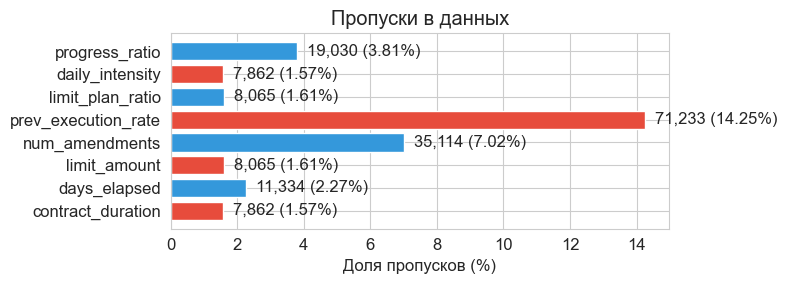

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(missing_present.index, missing_present['Процент (%)'], color=['#e74c3c', '#3498db'])
ax.set_xlabel('Доля пропусков (%)')
ax.set_title('Пропуски в данных')
for i, (val, pct) in enumerate(zip(missing_present['Пропуски'], missing_present['Процент (%)'])):
    ax.text(pct + 0.3, i, f'{val:,} ({pct}%)', va='center')
plt.tight_layout()
plt.show()

### 3.3 Распределения числовых признаков

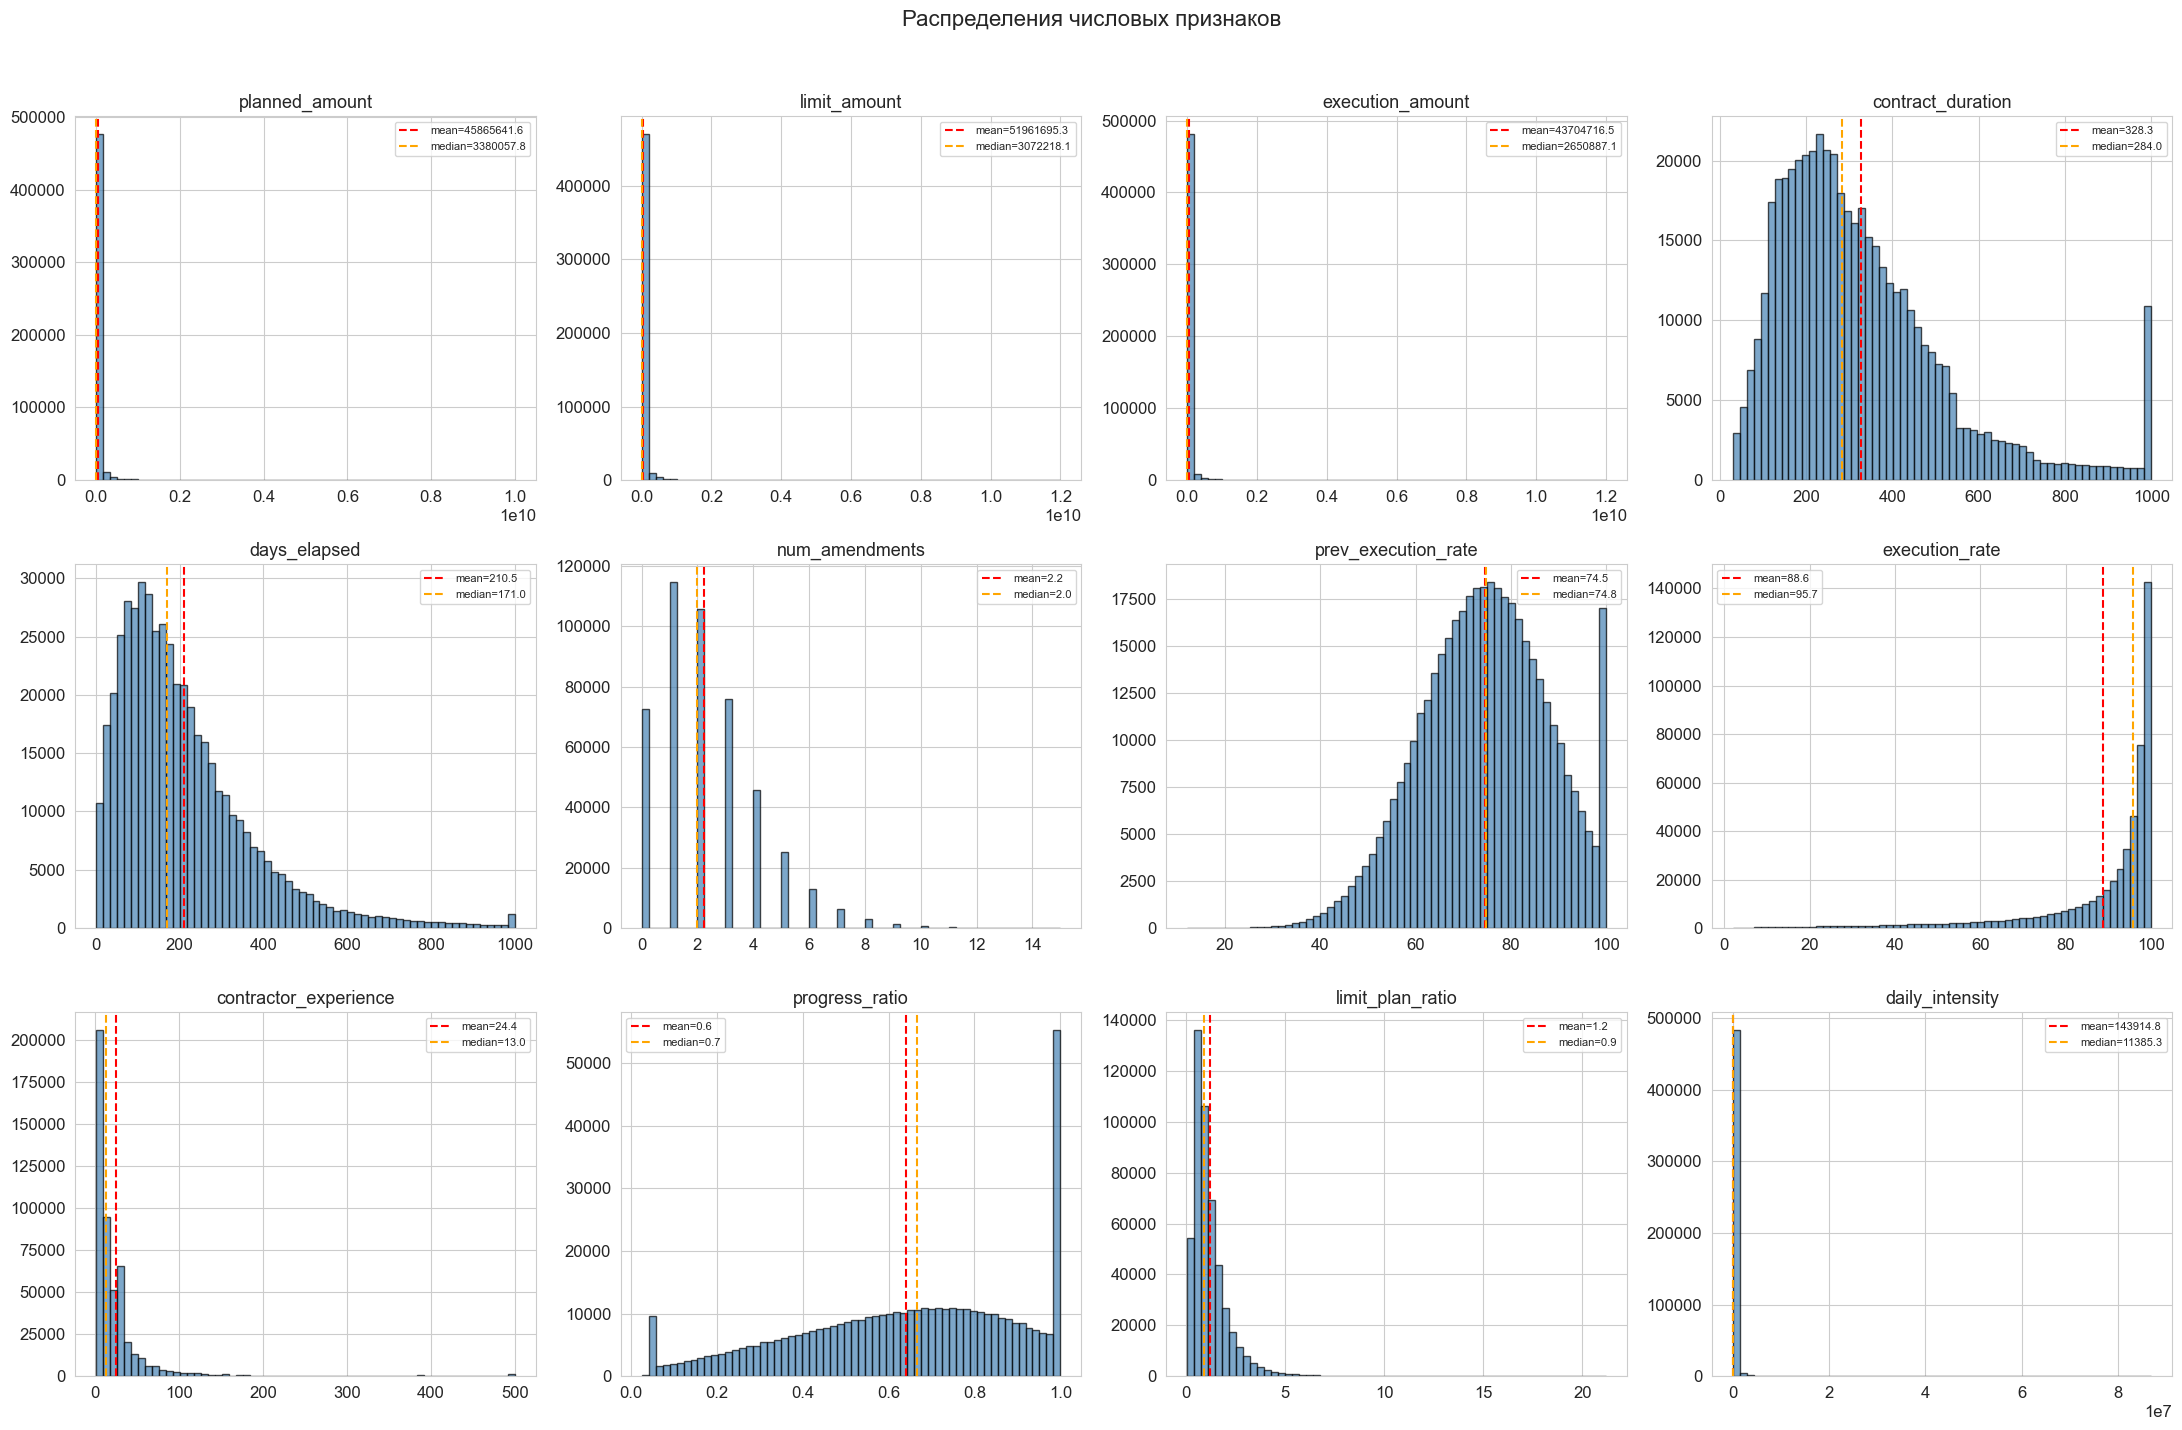

In [7]:
num_cols = ['planned_amount', 'limit_amount', 'execution_amount',
            'contract_duration', 'days_elapsed', 'num_amendments',
            'prev_execution_rate', 'execution_rate',
            'contractor_experience', 'progress_ratio',
            'limit_plan_ratio', 'daily_intensity']

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data = df[col].dropna()
    ax.hist(data, bins=60, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'median={data.median():.1f}')
    ax.set_title(col, fontsize=13)
    ax.legend(fontsize=8)

fig.suptitle('Распределения числовых признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

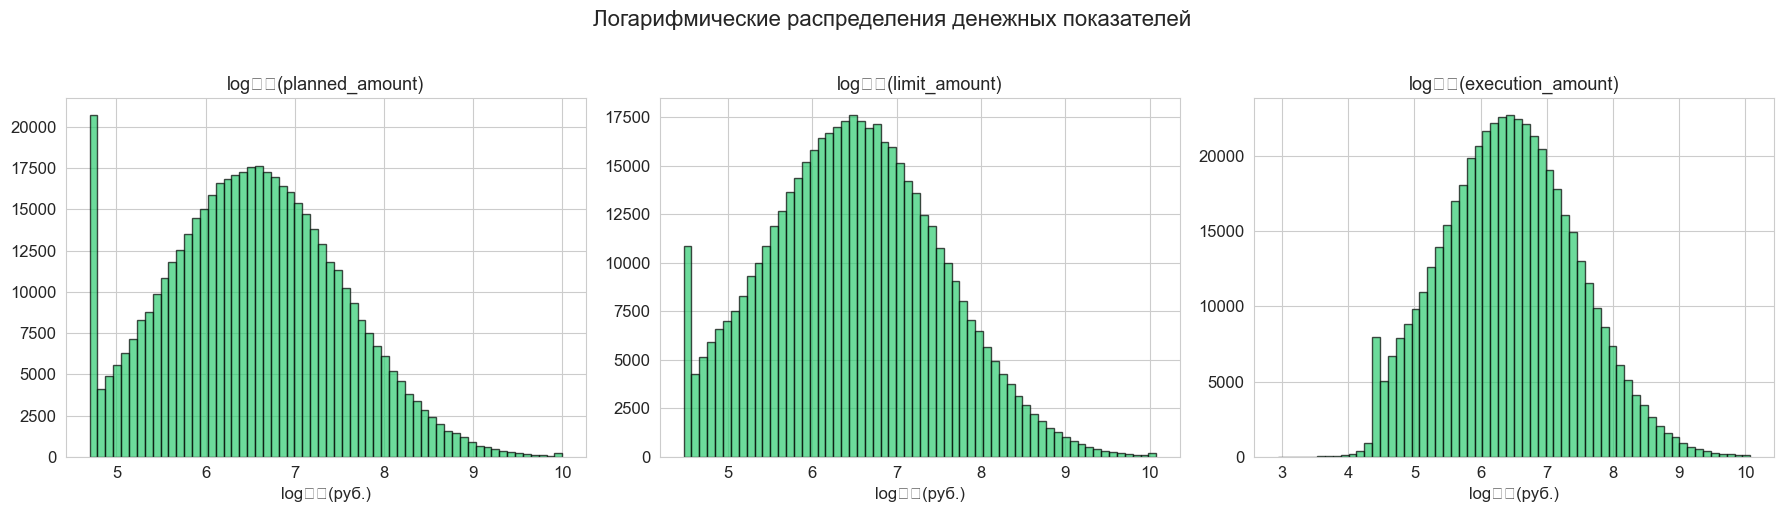

In [8]:
# Логарифмические распределения для денежных показателей
money_cols = ['planned_amount', 'limit_amount', 'execution_amount']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, money_cols):
    data = np.log10(df[col].dropna())
    ax.hist(data, bins=60, edgecolor='black', alpha=0.7, color='#2ecc71')
    ax.set_title(f'log₁₀({col})', fontsize=13)
    ax.set_xlabel('log₁₀(руб.)')
fig.suptitle('Логарифмические распределения денежных показателей', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Кардинальность категориальных признаков

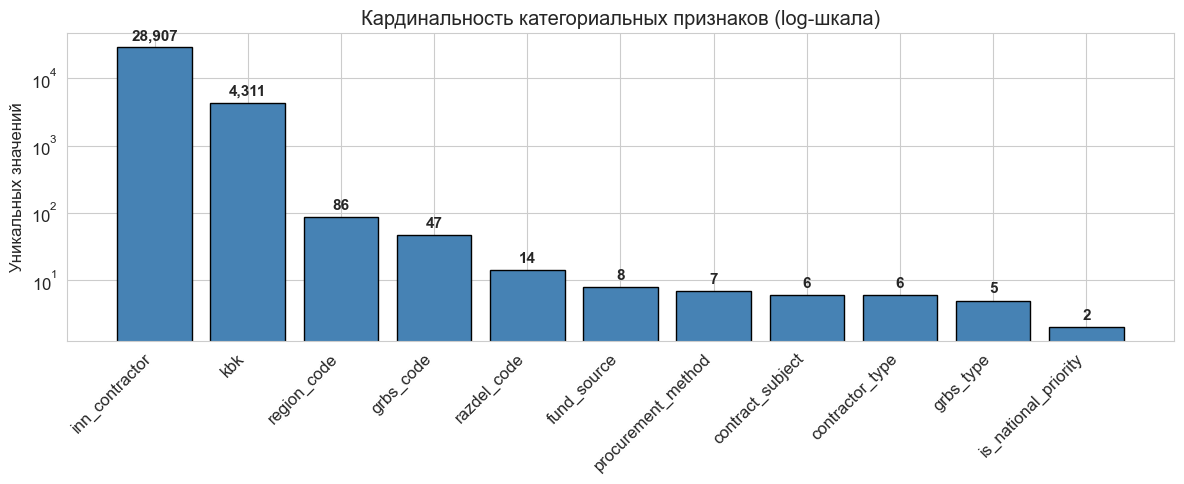

Кардинальность:
  inn_contractor            → 28,907 уникальных значений
  kbk                       →  4,311 уникальных значений
  region_code               →     86 уникальных значений
  grbs_code                 →     47 уникальных значений
  razdel_code               →     14 уникальных значений
  fund_source               →      8 уникальных значений
  procurement_method        →      7 уникальных значений
  contract_subject          →      6 уникальных значений
  contractor_type           →      6 уникальных значений
  grbs_type                 →      5 уникальных значений
  is_national_priority      →      2 уникальных значений


In [9]:
cat_cols = ['kbk', 'inn_contractor', 'region_code', 'grbs_code',
            'razdel_code', 'fund_source', 'procurement_method', 'contract_subject',
            'grbs_type', 'contractor_type', 'is_national_priority']

cardinality = df[cat_cols].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(cardinality)), cardinality.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(cardinality)))
ax.set_xticklabels(cardinality.index, rotation=45, ha='right')
ax.set_ylabel('Уникальных значений')
ax.set_title('Кардинальность категориальных признаков (log-шкала)')
ax.set_yscale('log')

for bar, val in zip(bars, cardinality.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.15,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('Кардинальность:')
for col, val in cardinality.items():
    print(f'  {col:25s} → {val:>6,} уникальных значений')

### 3.5 Анализ целевой переменной (`execution_rate`)

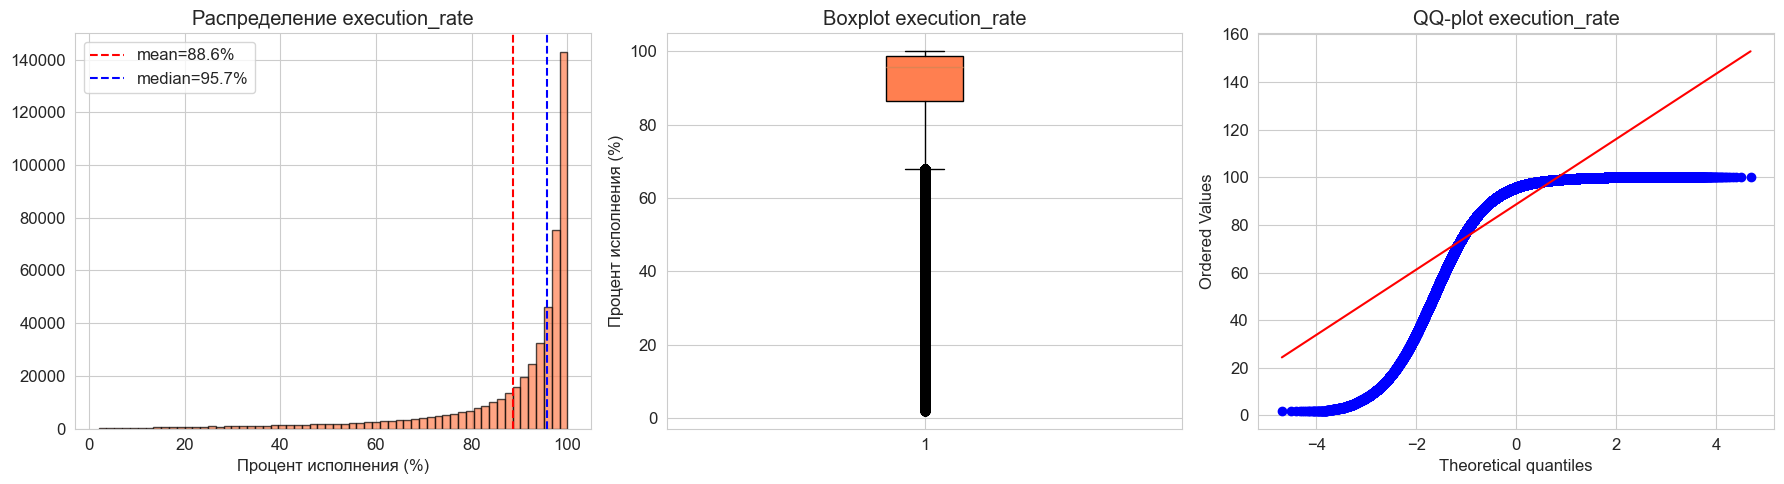

count    500000.00
mean         88.61
std          16.64
min           2.00
25%          86.34
50%          95.69
75%          98.64
max         100.00
Name: execution_rate, dtype: float64

Асимметрия (skew): -2.353
Эксцесс (kurtosis): 5.706


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(df['execution_rate'], bins=60, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(df['execution_rate'].mean(), color='red', linestyle='--',
                label=f"mean={df['execution_rate'].mean():.1f}%")
axes[0].axvline(df['execution_rate'].median(), color='blue', linestyle='--',
                label=f"median={df['execution_rate'].median():.1f}%")
axes[0].set_title('Распределение execution_rate')
axes[0].set_xlabel('Процент исполнения (%)')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(df['execution_rate'].dropna(), vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
axes[1].set_title('Boxplot execution_rate')
axes[1].set_ylabel('Процент исполнения (%)')

# QQ-plot
stats.probplot(df['execution_rate'], dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot execution_rate')

plt.tight_layout()
plt.show()

print(df['execution_rate'].describe().round(2))
print(f"\nАсимметрия (skew): {df['execution_rate'].skew():.3f}")
print(f"Эксцесс (kurtosis): {df['execution_rate'].kurtosis():.3f}")

### 3.6 Корреляционная матрица

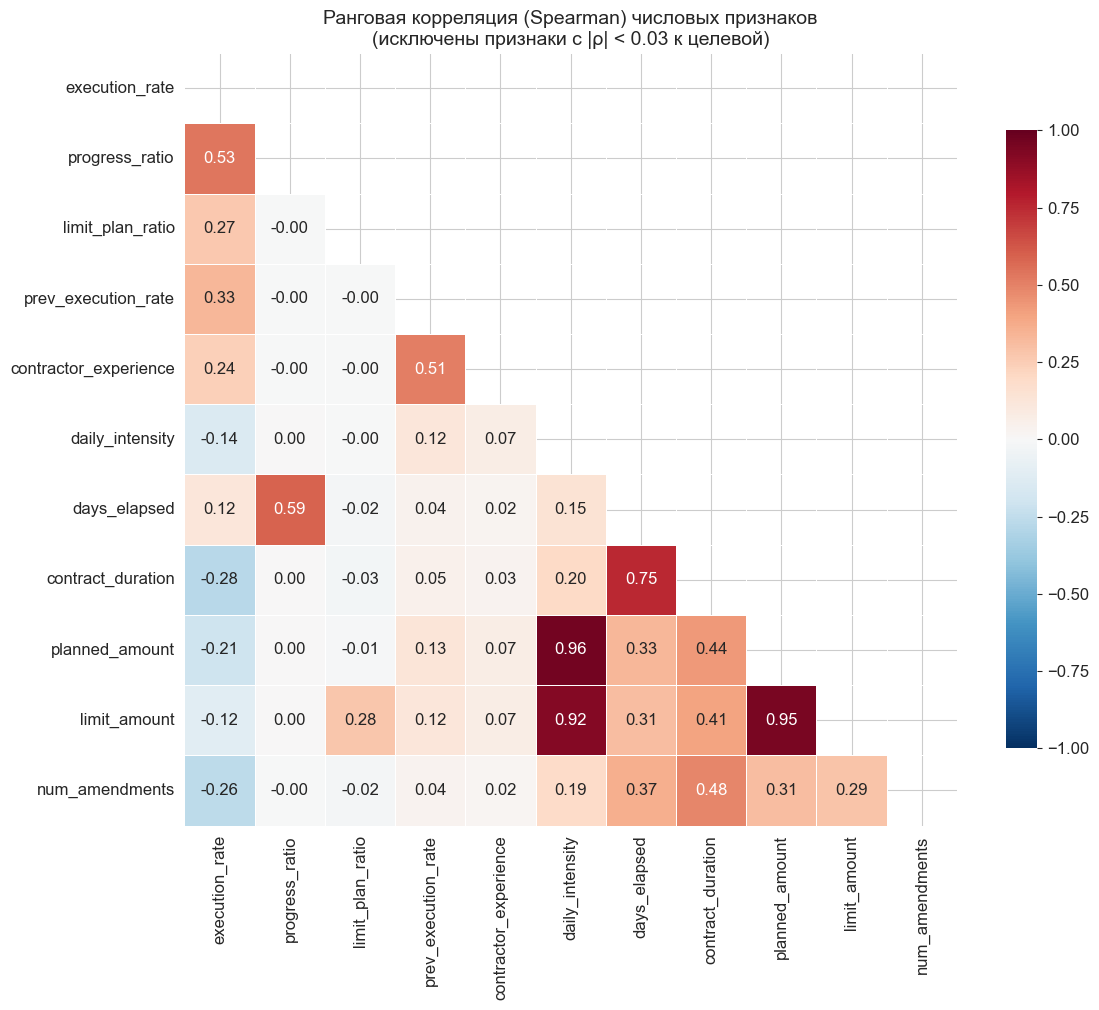

Корреляция с execution_rate (Spearman):
  progress_ratio           : +0.533
  prev_execution_rate      : +0.331
  contract_duration        : -0.279
  limit_plan_ratio         : +0.273
  num_amendments           : -0.260
  contractor_experience    : +0.242
  planned_amount           : -0.208
  daily_intensity          : -0.144
  days_elapsed             : +0.118
  limit_amount             : -0.117


In [11]:
corr_cols = ['execution_rate', 'progress_ratio', 'limit_plan_ratio',
             'prev_execution_rate', 'contractor_experience',
             'daily_intensity', 'days_elapsed', 'contract_duration',
             'planned_amount', 'limit_amount', 'num_amendments']

# Spearman — ранговая корреляция (ловит нелинейные монотонные зависимости)
corr = df[corr_cols].corr(method='spearman')

# Убираем признаки с околонулевой корреляцией к целевой (|ρ| < 0.03)
target_corr = corr['execution_rate'].abs()
significant = target_corr[target_corr >= 0.03].index.tolist()
corr = corr.loc[significant, significant]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Ранговая корреляция (Spearman) числовых признаков\n(исключены признаки с |ρ| < 0.03 к целевой)',
             fontsize=14)
plt.tight_layout()
plt.show()

print('Корреляция с execution_rate (Spearman):')
target_corr_full = df[corr_cols].corr(method='spearman')['execution_rate'].drop('execution_rate').sort_values(key=abs, ascending=False)
for feat, val in target_corr_full.items():
    print(f'  {feat:25s}: {val:+.3f}')

### 3.7 Сезонность и региональные паттерны

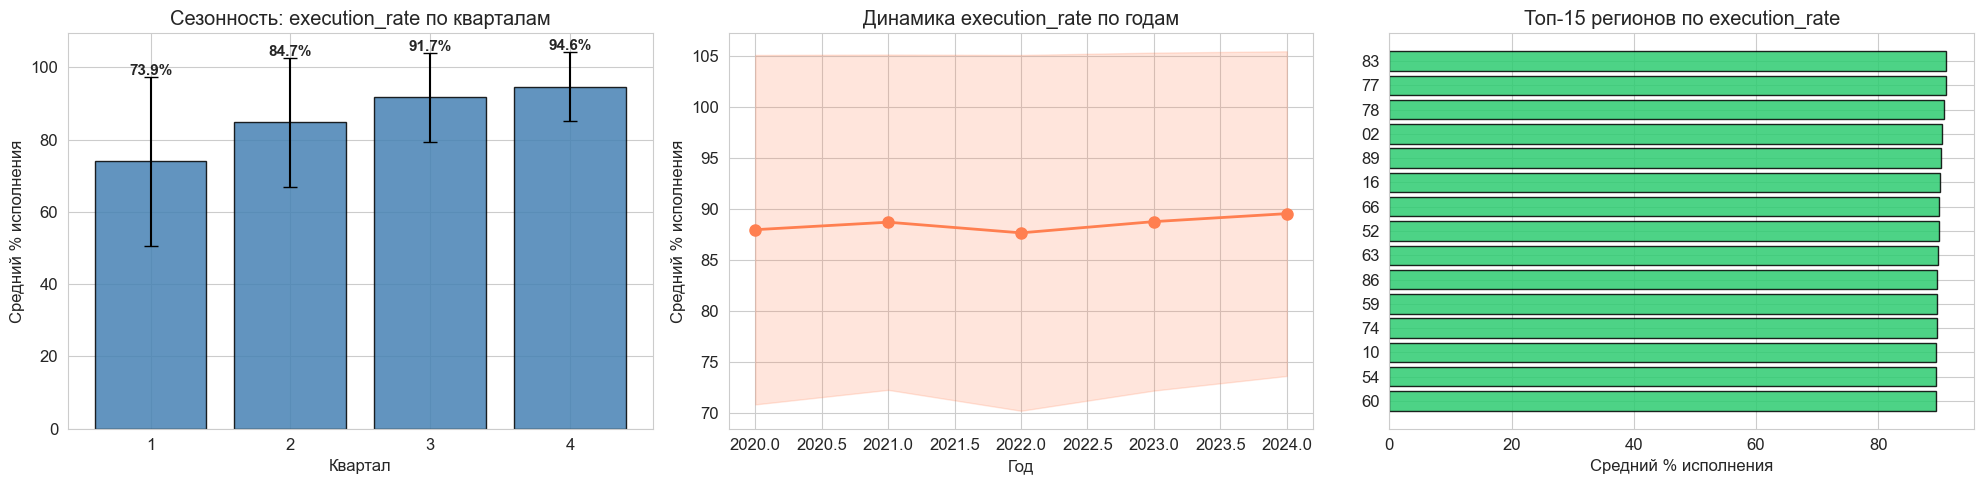

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Квартальная сезонность
quarterly = df.groupby('quarter')['execution_rate'].agg(['mean', 'std'])
axes[0].bar(quarterly.index, quarterly['mean'], yerr=quarterly['std'],
            capsize=5, color='steelblue', alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Квартал')
axes[0].set_ylabel('Средний % исполнения')
axes[0].set_title('Сезонность: execution_rate по кварталам')
axes[0].set_xticks([1, 2, 3, 4])
for i, row in quarterly.iterrows():
    axes[0].text(i, row['mean'] + row['std'] + 0.5, f"{row['mean']:.1f}%",
                 ha='center', fontsize=11, fontweight='bold')

# Динамика по годам
yearly = df.groupby('year')['execution_rate'].agg(['mean', 'std'])
axes[1].plot(yearly.index, yearly['mean'], 'o-', color='coral', linewidth=2, markersize=8)
axes[1].fill_between(yearly.index, yearly['mean'] - yearly['std'],
                     yearly['mean'] + yearly['std'], alpha=0.2, color='coral')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Средний % исполнения')
axes[1].set_title('Динамика execution_rate по годам')

# Топ-15 регионов
regional = df.groupby('region_code')['execution_rate'].mean().sort_values(ascending=True)
top = regional.tail(15)
axes[2].barh(top.index.astype(str), top.values, color='#2ecc71', edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Средний % исполнения')
axes[2].set_title('Топ-15 регионов по execution_rate')

plt.tight_layout()
plt.show()

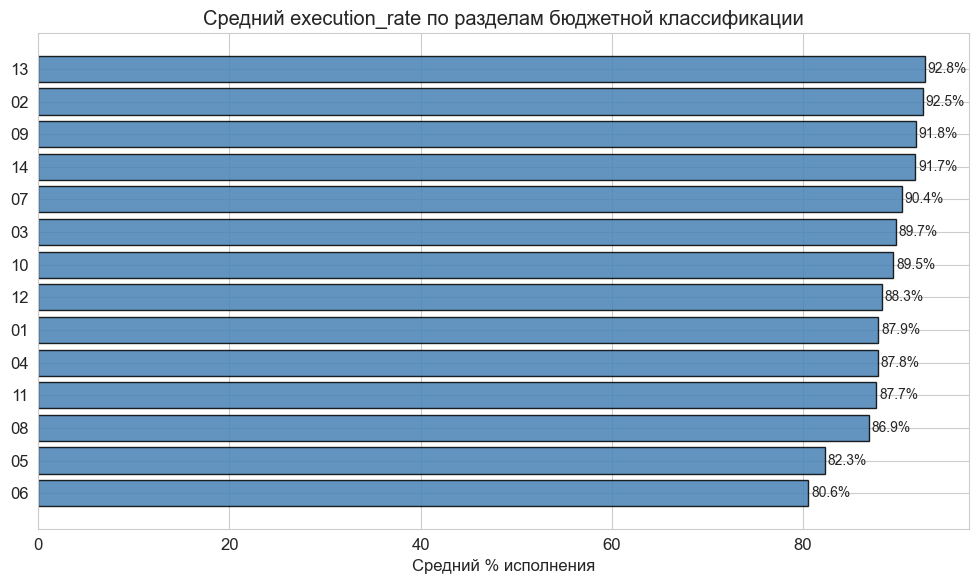

In [13]:
# Разделы бюджета (КБК) и их эффективность
razdel_stats = df.groupby('razdel_code')['execution_rate'].agg(['mean', 'count']).sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(razdel_stats.index.astype(str), razdel_stats['mean'],
               color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xlabel('Средний % исполнения')
ax.set_title('Средний execution_rate по разделам бюджетной классификации')
for bar, val in zip(bars, razdel_stats['mean']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10)
plt.tight_layout()
plt.show()

### Выводы по EDA

1. **Объём данных:** 500 000 контрактов, 2020–2024 гг. Пропуски — MNAR/MAR паттерн (~18.9% в `prev_execution_rate`, ~7% в `num_amendments`).

2. **Целевая переменная** `execution_rate`: медиана 95.7%, среднее 88.6%, std 16.6%. Сильная отрицательная асимметрия (skew = −2.35): большинство контрактов исполнены почти полностью, хвост неисполненных вправо обрезан.

3. **Топ-предикторы** (корреляция Спирмена с `execution_rate`):
   - `progress_ratio` — **r=+0.533** (самый сильный)
   - `prev_execution_rate` — r=+0.331
   - `contract_duration` — r=−0.279
   - `limit_plan_ratio` — r=+0.273
   - `num_amendments` — r=−0.260

4. **Кардинальность:** INN ~28 907, KBK ~4 311 уникальных значений. Target Encoding теряет информацию на редких группах — именно для таких признаков Entity Embeddings дают наибольший прирост.

5. **Сезонность:** Q4 — резкий рост исполнения («бюджетный декабрь»). Нелинейный эффект, который дерево-модели улавливают лучше линейных.

## 4. Предобработка данных

### 4.1 Обработка пропусков

In [14]:
# Создаём флаги-индикаторы пропусков (информативные признаки)
df['num_amendments_missing'] = df['num_amendments'].isnull().astype(int)
df['prev_execution_rate_missing'] = df['prev_execution_rate'].isnull().astype(int)

# Заполняем пропуски медианой
nan_cols = ['contract_duration', 'days_elapsed', 'limit_amount',
            'num_amendments', 'prev_execution_rate',
            'limit_plan_ratio', 'daily_intensity', 'progress_ratio']

for col in nan_cols:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    if n_missing > 0:
        print(f'  {col:25s}: {n_missing:>6,} пропусков → заполнено медианой ({median_val:.2f})')

print(f'\nПропуски после обработки: {df.isnull().sum().sum()}')

  contract_duration        :  7,862 пропусков → заполнено медианой (284.00)
  days_elapsed             : 11,334 пропусков → заполнено медианой (171.00)
  limit_amount             :  8,065 пропусков → заполнено медианой (3072218.11)
  num_amendments           : 35,114 пропусков → заполнено медианой (2.00)
  prev_execution_rate      : 71,233 пропусков → заполнено медианой (74.81)
  limit_plan_ratio         :  8,065 пропусков → заполнено медианой (0.91)
  daily_intensity          :  7,862 пропусков → заполнено медианой (11385.30)
  progress_ratio           : 19,030 пропусков → заполнено медианой (0.67)

Пропуски после обработки: 0


### 4.2 Определение групп признаков

In [15]:
TARGET = 'execution_rate'

CAT_FEATURES = ['kbk', 'inn_contractor', 'region_code', 'grbs_code',
                'razdel_code', 'fund_source', 'procurement_method',
                'grbs_type', 'contractor_type']

ORD_FEATURES = ['contract_subject']

NUM_FEATURES = ['year', 'quarter', 'month', 'contract_duration', 'days_elapsed',
                'planned_amount', 'limit_amount', 'num_amendments',
                'prev_execution_rate', 'contractor_experience',
                'progress_ratio', 'limit_plan_ratio', 'daily_intensity',
                'is_national_priority',
                'num_amendments_missing', 'prev_execution_rate_missing']

DROP_COLS = ['contract_id', 'execution_amount']

ALL_FEATURES = CAT_FEATURES + ORD_FEATURES + NUM_FEATURES
print(f'Категориальных: {len(CAT_FEATURES)}')
print(f'Порядковых:     {len(ORD_FEATURES)}')
print(f'Числовых:       {len(NUM_FEATURES)}')
print(f'Итого:          {len(ALL_FEATURES)} признаков')

Категориальных: 9
Порядковых:     1
Числовых:       16
Итого:          26 признаков


### 4.3 Разбиение на Train / Val / Test

In [16]:
from sklearn.model_selection import train_test_split

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# Стратифицированное разбиение по кварталам (сохраняем временную структуру)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=df['quarter'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=RANDOM_STATE,
    stratify=X_train_val['quarter'])

print(f'Train: {len(X_train):>7,} ({len(X_train)/len(df)*100:.1f}%)')
print(f'Val:   {len(X_val):>7,} ({len(X_val)/len(df)*100:.1f}%)')
print(f'Test:  {len(X_test):>7,} ({len(X_test)/len(df)*100:.1f}%)')
print(f'Всего: {len(X_train)+len(X_val)+len(X_test):>7,}')

Train: 350,200 (70.0%)
Val:    74,800 (15.0%)
Test:   75,000 (15.0%)
Всего: 500,000


### 4.4 Нормализация числовых признаков

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[NUM_FEATURES] = scaler.fit_transform(X_train[NUM_FEATURES])
X_val_scaled[NUM_FEATURES] = scaler.transform(X_val[NUM_FEATURES])
X_test_scaled[NUM_FEATURES] = scaler.transform(X_test[NUM_FEATURES])

print('Нормализация завершена.')
print('\nСредние значения train (должны быть ≈0):')
print(X_train_scaled[NUM_FEATURES].mean().round(4).to_string())

Нормализация завершена.

Средние значения train (должны быть ≈0):
year                           0.0
quarter                       -0.0
month                         -0.0
contract_duration             -0.0
days_elapsed                  -0.0
planned_amount                 0.0
limit_amount                  -0.0
num_amendments                 0.0
prev_execution_rate            0.0
contractor_experience         -0.0
progress_ratio                 0.0
limit_plan_ratio              -0.0
daily_intensity               -0.0
is_national_priority          -0.0
num_amendments_missing         0.0
prev_execution_rate_missing    0.0


### 4.5 Кодирование категориальных признаков (Target Encoding)

In [18]:
from sklearn.model_selection import KFold

def target_encode(train, val, test, col, target, n_splits=5):
    """Target Encoding с K-Fold регуляризацией для избежания утечки."""
    global_mean = target.mean()
    train_encoded = pd.Series(index=train.index, dtype=float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for fit_idx, transform_idx in kf.split(train):
        fit_target = target.iloc[fit_idx]
        means = train[col].iloc[fit_idx].to_frame().assign(t=fit_target.values).groupby(col)['t'].mean()
        train_encoded.iloc[transform_idx] = train[col].iloc[transform_idx].map(means)

    train_encoded = train_encoded.fillna(global_mean)

    full_means = train[[col]].assign(t=target.values).groupby(col)['t'].mean()
    val_encoded = val[col].map(full_means).fillna(global_mean)
    test_encoded = test[col].map(full_means).fillna(global_mean)

    return train_encoded, val_encoded, test_encoded

# Применяем Target Encoding к категориальным и порядковым признакам
encode_cols = CAT_FEATURES + ORD_FEATURES

X_train_te = X_train_scaled.copy()
X_val_te = X_val_scaled.copy()
X_test_te = X_test_scaled.copy()

for col in encode_cols:
    tr, va, te = target_encode(X_train, X_val, X_test, col, y_train)
    X_train_te[col] = tr.values
    X_val_te[col] = va.values
    X_test_te[col] = te.values

print(f'Target Encoding применён к {len(encode_cols)} столбцам.')
print(f'Итоговая размерность: {X_train_te.shape}')
X_train_te.head()

Target Encoding применён к 10 столбцам.
Итоговая размерность: (350200, 26)


,kbk,inn_contractor,region_code,grbs_code,razdel_code,fund_source,procurement_method,grbs_type,contractor_type,contract_subject,...,limit_amount,num_amendments,prev_execution_rate,contractor_experience,progress_ratio,limit_plan_ratio,daily_intensity,is_national_priority,num_amendments_missing,prev_execution_rate_missing
185848,88.841915,89.298088,89.717200,91.646257,89.646544,87.900641,86.505389,89.336770,88.648037,75.988335,...,-0.145539,-1.276422,-0.242476,-0.498171,-0.188699,-1.171535,-0.133283,-0.739713,-0.275121,-0.406549
282766,91.733105,88.075880,90.156177,89.031482,88.026146,89.531049,90.488219,89.363319,88.662059,88.251429,...,-0.102225,-0.699332,-0.264407,-0.498171,0.391330,0.905989,-0.095522,-0.739713,-0.275121,-0.406549
422388,86.883485,90.397237,90.837272,88.290420,82.372050,85.968273,90.481506,87.715010,88.983075,75.988335,...,-0.144838,0.454848,-0.081647,3.145262,-1.415882,2.426323,-0.134179,-0.739713,-0.275121,-0.406549
293365,85.749543,88.965536,88.571467,87.684907,89.413747,85.969553,90.505944,89.364751,85.649614,76.101731,...,0.027580,2.763208,1.240720,0.179134,-0.271222,0.141735,-0.075480,-0.739713,-0.275121,-0.406549
313262,80.242820,95.669408,88.262201,88.872298,82.213154,86.099798,87.127215,89.306203,88.619524,88.171009,...,0.052795,0.454848,2.064356,0.599530,0.681543,0.078056,-0.059650,-0.739713,-0.275121,-0.406549


## 5. Baseline-модели

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    """Вычисление метрик качества регрессии."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    # MAPE с защитой от деления на малые значения
    mask = np.abs(y_true) > 1.0  # игнорируем y_true < 1%
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Модель': model_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4),
            'R²': round(r2, 4), 'MAPE (%)': round(mape, 2)}

results = []
print('Функция evaluate_model готова (MAPE с защитой от малых y_true).')

Функция evaluate_model готова (MAPE с защитой от малых y_true).


### 5.1 Ridge Regression

In [20]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_te, y_train)

y_pred_ridge = ridge.predict(X_test_te)
res = evaluate_model(y_test, y_pred_ridge, 'Ridge Regression')
results.append(res)
print(res)

{'Модель': 'Ridge Regression', 'MAE': 7.4182, 'RMSE': np.float64(10.4088), 'R²': 0.6129, 'MAPE (%)': np.float64(13.45)}


### 5.2 Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_te, y_train)

y_pred_rf = rf.predict(X_test_te)
res = evaluate_model(y_test, y_pred_rf, 'Random Forest')
results.append(res)
print(res)

{'Модель': 'Random Forest', 'MAE': 4.8765, 'RMSE': np.float64(8.3114), 'R²': 0.7532, 'MAPE (%)': np.float64(9.4)}


### 5.3 XGBoost

In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb.fit(X_train_te, y_train,
        eval_set=[(X_val_te, y_val)],
        verbose=False)

y_pred_xgb = xgb.predict(X_test_te)
res = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
results.append(res)
print(res)

{'Модель': 'XGBoost', 'MAE': 3.9, 'RMSE': np.float64(6.6616), 'R²': 0.8415, 'MAPE (%)': np.float64(6.82)}


### 5.4 CatBoost (нативная обработка категорий)

In [23]:
from catboost import CatBoostRegressor, Pool

# CatBoost работает с категориальными признаками нативно (без Target Encoding)
cat_indices = [X_train.columns.get_loc(c) for c in CAT_FEATURES + ORD_FEATURES]

# Приводим категориальные столбцы к строкам
X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in CAT_FEATURES + ORD_FEATURES:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

# Нормализуем числовые
X_train_cb[NUM_FEATURES] = scaler.transform(X_train[NUM_FEATURES])
X_val_cb[NUM_FEATURES] = scaler.transform(X_val[NUM_FEATURES])
X_test_cb[NUM_FEATURES] = scaler.transform(X_test[NUM_FEATURES])

train_pool = Pool(X_train_cb, y_train, cat_features=cat_indices)
val_pool = Pool(X_val_cb, y_val, cat_features=cat_indices)
test_pool = Pool(X_test_cb, cat_features=cat_indices)

catboost = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3,
    random_seed=RANDOM_STATE,
    verbose=100
)
catboost.fit(train_pool, eval_set=val_pool)

y_pred_cb = catboost.predict(test_pool)
res = evaluate_model(y_test, y_pred_cb, 'CatBoost (native)')
results.append(res)
print(res)

0:	learn: 16.1873340	test: 16.1806732	best: 16.1806732 (0)	total: 201ms	remaining: 3m 21s
100:	learn: 7.7726121	test: 7.6119080	best: 7.6119080 (100)	total: 10.6s	remaining: 1m 34s
200:	learn: 7.1732138	test: 6.9737963	best: 6.9737963 (200)	total: 21.5s	remaining: 1m 25s
300:	learn: 6.9329776	test: 6.7459632	best: 6.7459632 (300)	total: 32.5s	remaining: 1m 15s
400:	learn: 6.7883180	test: 6.6262639	best: 6.6262639 (400)	total: 43.7s	remaining: 1m 5s
500:	learn: 6.6868215	test: 6.5523800	best: 6.5523800 (500)	total: 55.2s	remaining: 55s
600:	learn: 6.6069897	test: 6.5018852	best: 6.5018852 (600)	total: 1m 6s	remaining: 44.4s
700:	learn: 6.5398062	test: 6.4625154	best: 6.4625154 (700)	total: 1m 18s	remaining: 33.5s
800:	learn: 6.4825574	test: 6.4313659	best: 6.4313659 (800)	total: 1m 30s	remaining: 22.5s
900:	learn: 6.4323978	test: 6.4044546	best: 6.4044546 (900)	total: 1m 42s	remaining: 11.3s
999:	learn: 6.3879792	test: 6.3855636	best: 6.3855636 (999)	total: 1m 52s	remaining: 0us

bestTe

### 5.5 LightGBM

In [24]:
from lightgbm import LGBMRegressor, log_evaluation, early_stopping

lgbm = LGBMRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm.fit(X_train_te, y_train,
         eval_set=[(X_val_te, y_val)],
         callbacks=[log_evaluation(period=0), early_stopping(50, verbose=False)])

y_pred_lgbm = lgbm.predict(X_test_te)
res = evaluate_model(y_test, y_pred_lgbm, 'LightGBM')
results.append(res)
print(res)

{'Модель': 'LightGBM', 'MAE': 4.133, 'RMSE': np.float64(6.8207), 'R²': 0.8338, 'MAPE (%)': np.float64(7.2)}


### 5.6 MLP (многослойный перцептрон)

In [25]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import time

torch.set_num_threads(1)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

print(f'Типы данных X_train_te: {dict(X_train_te.dtypes.value_counts())}')

X_tr_np = X_train_te.to_numpy(dtype=np.float32, na_value=0.0)
X_va_np = X_val_te.to_numpy(dtype=np.float32, na_value=0.0)
X_te_np = X_test_te.to_numpy(dtype=np.float32, na_value=0.0)

x_train_t = torch.tensor(X_tr_np).to(device)
x_val_t = torch.tensor(X_va_np).to(device)
x_test_t = torch.tensor(X_te_np).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).to(device)

Device: mps
Типы данных X_train_te: {dtype('float64'): np.int64(26)}


#### 5.6.1 Архитектура и обучение MLP

**Что обучаем:** `MLPRegressor` (512→256→128→1) на `X_train_te` (Target-Encoded признаки).

`device = MPS` (Metal Performance Shaders, GPU Apple Silicon) ускоряет обучение.

In [26]:
# ─── Архитектура MLP ───
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

input_dim = X_tr_np.shape[1]
mlp = MLPRegressor(input_dim).to(device)
print(f'MLP архитектура: input={input_dim} → 512 → 256 → 128 → 1')
print(f'Параметров: {sum(p.numel() for p in mlp.parameters()):,}')

# ─── Обучение MLP (что обучаем: MLP на Target-Encoded признаках) ───
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_ds = TensorDataset(x_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 20

mlp_train_losses = []
mlp_val_losses = []

t0 = time.time()
for epoch in range(200):
    mlp.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = mlp(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlp.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    epoch_loss /= len(train_ds)
    mlp_train_losses.append(epoch_loss)

    mlp.eval()
    with torch.no_grad():
        val_loss = criterion(mlp(x_val_t), y_val_t).item()
    mlp_val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_mlp_state = mlp.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {epoch_loss:.3f} | Val: {val_loss:.3f}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping на эпохе {epoch + 1}')
        break

mlp.load_state_dict(best_mlp_state)
print(f'Время обучения: {time.time()-t0:.0f}с | Лучший Val MSE: {best_val_loss:.4f}')

MLP архитектура: input=26 → 512 → 256 → 128 → 1
Параметров: 179,969
Epoch  20 | Train: 83.713 | Val: 73.390
Epoch  40 | Train: 80.315 | Val: 864.089
Epoch  60 | Train: 77.200 | Val: 113.840
Epoch  80 | Train: 75.317 | Val: 63.936
Epoch 100 | Train: 73.951 | Val: 43.041
Epoch 120 | Train: 72.683 | Val: 44.163
Early stopping на эпохе 139
Время обучения: 249с | Лучший Val MSE: 42.7700


#### 5.6.2 Оценка MLP на тестовой выборке

MLP: R²=0.8407  MAE=3.9768  RMSE=6.6781


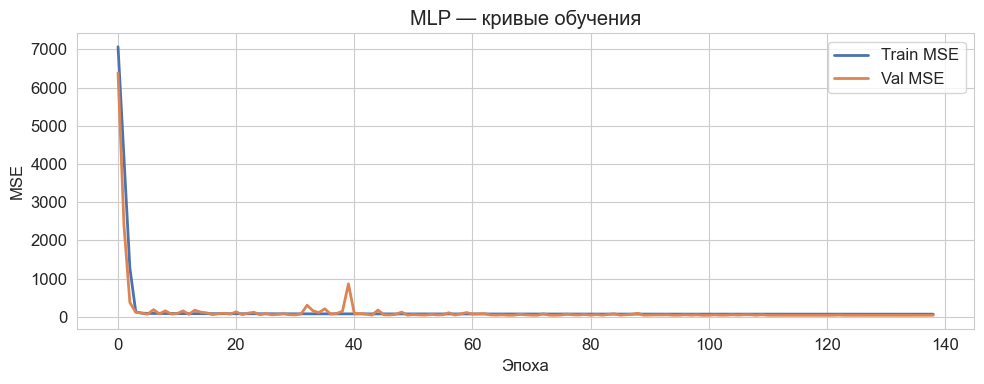

In [27]:
# ─── Оценка MLP и кривые обучения ───
mlp.eval()
with torch.no_grad():
    y_pred_mlp = mlp(x_test_t).cpu().numpy()

res_mlp = evaluate_model(y_test, y_pred_mlp, 'MLP')
results.append(res_mlp)
print(f"MLP: R²={res_mlp['R²']:.4f}  MAE={res_mlp['MAE']:.4f}  RMSE={res_mlp['RMSE']:.4f}")

# Кривые обучения
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_train_losses, label='Train MSE', linewidth=2)
ax.plot(mlp_val_losses, label='Val MSE', linewidth=2)
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE')
ax.set_title('MLP — кривые обучения')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

### 5.7 Сводная таблица baseline-моделей

In [28]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
print('=' * 70)
print('СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ')
print('=' * 70)
results_df

СВОДНАЯ ТАБЛИЦА BASELINE-МОДЕЛЕЙ


,Модель,MAE,RMSE,R²,MAPE (%)
0,CatBoost (native),3.8061,6.4592,0.8509,6.65
1,XGBoost,3.9000,6.6616,0.8415,6.82
2,MLP,3.9768,6.6781,0.8407,6.58
3,LightGBM,4.1330,6.8207,0.8338,7.20
4,Random Forest,4.8765,8.3114,0.7532,9.40
5,Ridge Regression,7.4182,10.4088,0.6129,13.45


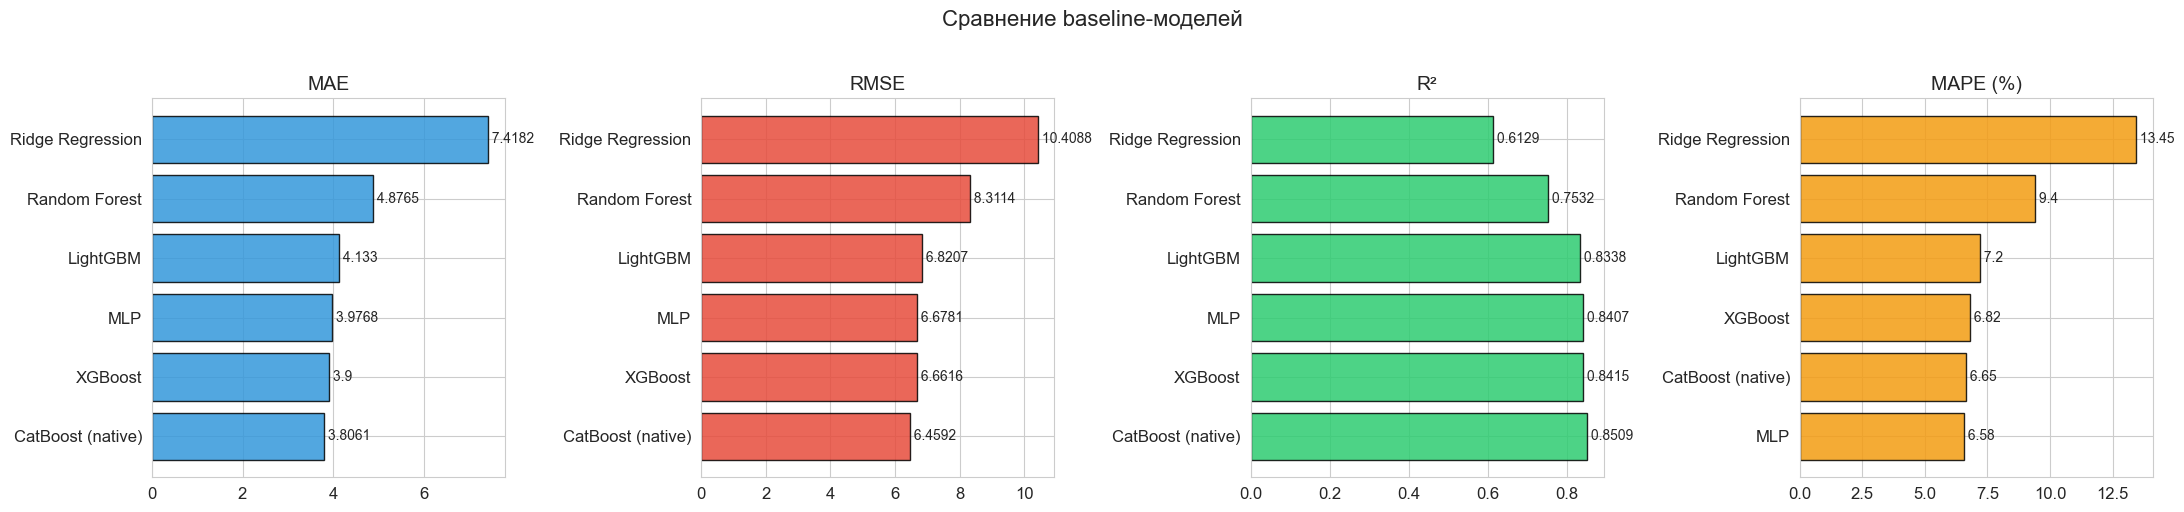

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R²'))
    ax.barh(sorted_df['Модель'], sorted_df[metric], color=color, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=14)
    for i, val in enumerate(sorted_df[metric]):
        ax.text(val, i, f' {val}', va='center', fontsize=10)

fig.suptitle('Сравнение baseline-моделей', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Гибридная модель: Entity Embeddings → CatBoost

### 6.1 Архитектура нейросети с Entity Embeddings

Идея: обучить нейросеть с Embedding-слоями для категориальных признаков.
После обучения — извлечь плотные вектора (эмбеддинги) и использовать их как входные
признаки для CatBoost вместо исходных категорий.

In [30]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder для каждого категориального признака
label_encoders = {}
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_test_le = X_test.copy()

cat_all = CAT_FEATURES + ORD_FEATURES

for col in cat_all:
    le = LabelEncoder()
    # Объединяем все уникальные значения для fit
    all_values = pd.concat([X_train[col], X_val[col], X_test[col]]).astype(str)
    le.fit(all_values)
    X_train_le[col] = le.transform(X_train[col].astype(str))
    X_val_le[col] = le.transform(X_val[col].astype(str))
    X_test_le[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Размерности: берём из LabelEncoder (все уникальные значения, не только train)
cat_dims = [len(label_encoders[col].classes_) for col in cat_all]
emb_dims = [min(50, (d + 1) // 2) for d in cat_dims]

print('Категориальные признаки → размерности эмбеддингов:')
for col, cd, ed in zip(cat_all, cat_dims, emb_dims):
    print(f'  {col:25s} | уникальных: {cd:>6,} | emb_dim: {ed}')
print(f'\nИтого параметров эмбеддингов: {sum(cd * ed for cd, ed in zip(cat_dims, emb_dims)):,}')

Категориальные признаки → размерности эмбеддингов:
  kbk                       | уникальных:  4,311 | emb_dim: 50
  inn_contractor            | уникальных: 28,907 | emb_dim: 50
  region_code               | уникальных:     86 | emb_dim: 43
  grbs_code                 | уникальных:     47 | emb_dim: 24
  razdel_code               | уникальных:     14 | emb_dim: 7
  fund_source               | уникальных:      8 | emb_dim: 4
  procurement_method        | уникальных:      7 | emb_dim: 4
  grbs_type                 | уникальных:      5 | emb_dim: 3
  contractor_type           | уникальных:      6 | emb_dim: 3
  contract_subject          | уникальных:      6 | emb_dim: 3

Итого параметров эмбеддингов: 1,665,935


### 6.2 Обучение нейросети с эмбеддингами

In [31]:
class EmbeddingNet(nn.Module):
    HIDDEN_DIM = 96  # размер последнего скрытого слоя (для извлечения активаций)

    def __init__(self, cat_dims, emb_dims, num_cont):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])
        total_emb_dim = sum(emb_dims)
        input_dim = total_emb_dim + num_cont

        self.emb_dropout = nn.Dropout(0.15)

        self.body = nn.Sequential(
            nn.Linear(input_dim, 384),
            nn.BatchNorm1d(384),
            nn.SiLU(),
            nn.Dropout(0.35),
            nn.Linear(384, 192),
            nn.BatchNorm1d(192),
            nn.SiLU(),
            nn.Dropout(0.25),
            nn.Linear(192, self.HIDDEN_DIM),
            nn.BatchNorm1d(self.HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(0.15),
        )
        self.head = nn.Linear(self.HIDDEN_DIM, 1)

        for m in list(self.body) + [self.head]:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def _embed(self, x_cat, x_cont):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x_emb = torch.cat(embs, dim=1)
        x_emb = self.emb_dropout(x_emb)
        return torch.cat([x_emb, x_cont], dim=1)

    def forward(self, x_cat, x_cont):
        x = self._embed(x_cat, x_cont)
        x = self.body(x)
        return self.head(x).squeeze()

    def get_embeddings(self, x_cat):
        """Извлечение конкатенированных эмбеддингов категорий."""
        with torch.no_grad():
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            return torch.cat(embs, dim=1)

    def get_hidden_features(self, x_cat, x_cont):
        """Активации последнего скрытого слоя (HIDDEN_DIM) перед head — для stacking."""
        with torch.no_grad():
            # Прогоняем без dropout (eval-режим должен быть включён извне)
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            x = torch.cat(embs + [x_cont], dim=1)
            return self.body(x)

print(f'Входная размерность: {sum(emb_dims)} (эмбеддинги) + {len(NUM_FEATURES)} (числовые) = {sum(emb_dims) + len(NUM_FEATURES)}')
print(f'Скрытый слой для stacking: {EmbeddingNet.HIDDEN_DIM}-dim')
print(f'Архитектура: SiLU, Dropout на эмбеддингах (0.15), FC: 384→192→96→1')

Входная размерность: 191 (эмбеддинги) + 16 (числовые) = 207
Скрытый слой для stacking: 96-dim
Архитектура: SiLU, Dropout на эмбеддингах (0.15), FC: 384→192→96→1


In [32]:
# ─── Устройство и подготовка тензоров для EmbeddingNet ───
device = torch.device('cpu')

def prepare_tensors(X_le, X_orig, y_series):
    x_cat = torch.LongTensor(X_le[cat_all].values).to(device)
    x_num = torch.FloatTensor(
        scaler.transform(X_orig[NUM_FEATURES]) if hasattr(scaler, 'mean_')
        else X_orig[NUM_FEATURES].values
    ).to(device)
    y_t = torch.FloatTensor(y_series.values).to(device)
    return x_cat, x_num, y_t

x_cat_train, x_num_train, y_t_train = prepare_tensors(X_train_le, X_train, y_train)
x_cat_val, x_num_val, y_t_val = prepare_tensors(X_val_le, X_val, y_val)
x_cat_test, x_num_test, y_t_test = prepare_tensors(X_test_le, X_test, y_test)

print(f'Тензоры готовы: x_cat_train={tuple(x_cat_train.shape)}, x_num_train={tuple(x_num_train.shape)}')

Тензоры готовы: x_cat_train=(350200, 10), x_num_train=(350200, 16)


#### 6.2.1 Обучение нейросети с Entity Embeddings

**Что обучаем:** `EmbeddingNet` — нейросеть с Embedding-слоями для 10 категориальных признаков.

Суммарная размерность эмбеддингов: **191** (KBK 50 + INN 50 + region 43 + ... ). Итоговый вход FC-блока: **191 + 16 = 207 признаков**.

Архитектура FC: Linear(207→384) → SiLU → Linear(384→192) → SiLU → Linear(192→96) → SiLU → Linear(96→1).

> MPS - проблемы .

In [33]:
# ─── Обучение EmbeddingNet (что обучаем: нейросеть с Embedding-слоями) ───
# Архитектура: Embedding(KBK 4311→50, INN 33297→50, ...) → concat → FC(512→256→96→1)
# Оптимизация: Adam + ReduceLROnPlateau + early stopping (patience=20)

emb_net = EmbeddingNet(cat_dims, emb_dims, len(NUM_FEATURES)).to(device)
optimizer = torch.optim.Adam(emb_net.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_ds = TensorDataset(x_cat_train, x_num_train, y_t_train)
train_loader = DataLoader(train_ds, batch_size=2048, shuffle=True)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 20

train_losses = []
val_losses = []

t0 = time.time()
for epoch in range(200):
    emb_net.train()
    epoch_loss = 0
    for xc, xn, yb in train_loader:
        optimizer.zero_grad()
        pred = emb_net(xc, xn)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(emb_net.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)

    emb_net.eval()
    with torch.no_grad():
        val_loss = criterion(emb_net(x_cat_val, x_num_val), y_t_val).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in emb_net.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train MSE: {epoch_loss:.4f} | Val MSE: {val_loss:.4f}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping на эпохе {epoch + 1}')
        break

emb_net.load_state_dict(best_state)
print(f'\nВремя обучения: {time.time()-t0:.0f}с | Лучший Val MSE: {best_val_loss:.4f}')

# Оцениваем на тестовой выборке
emb_net.eval()
with torch.no_grad():
    y_pred_emb_net = emb_net(x_cat_test, x_num_test).cpu().numpy()

res_emb = evaluate_model(y_test, y_pred_emb_net, 'EmbeddingNet (NN)')
results.append(res_emb)
print(f"EmbeddingNet: R²={res_emb['R²']:.4f}  MAE={res_emb['MAE']:.4f}")

Epoch  10 | Train MSE: 84.6965 | Val MSE: 47.4609
Epoch  20 | Train MSE: 61.9854 | Val MSE: 41.4272
Epoch  30 | Train MSE: 47.5786 | Val MSE: 38.6977
Epoch  40 | Train MSE: 39.6604 | Val MSE: 37.9270
Epoch  50 | Train MSE: 36.6741 | Val MSE: 36.4948
Epoch  60 | Train MSE: 34.5395 | Val MSE: 35.9848
Epoch  70 | Train MSE: 33.0427 | Val MSE: 35.3792
Epoch  80 | Train MSE: 30.7263 | Val MSE: 35.3180
Epoch  90 | Train MSE: 30.2170 | Val MSE: 35.3581
Epoch 100 | Train MSE: 29.8422 | Val MSE: 35.3446
Epoch 110 | Train MSE: 28.9181 | Val MSE: 35.4368
Early stopping на эпохе 111

Время обучения: 344с | Лучший Val MSE: 34.9127
EmbeddingNet: R²=0.8732  MAE=3.3065


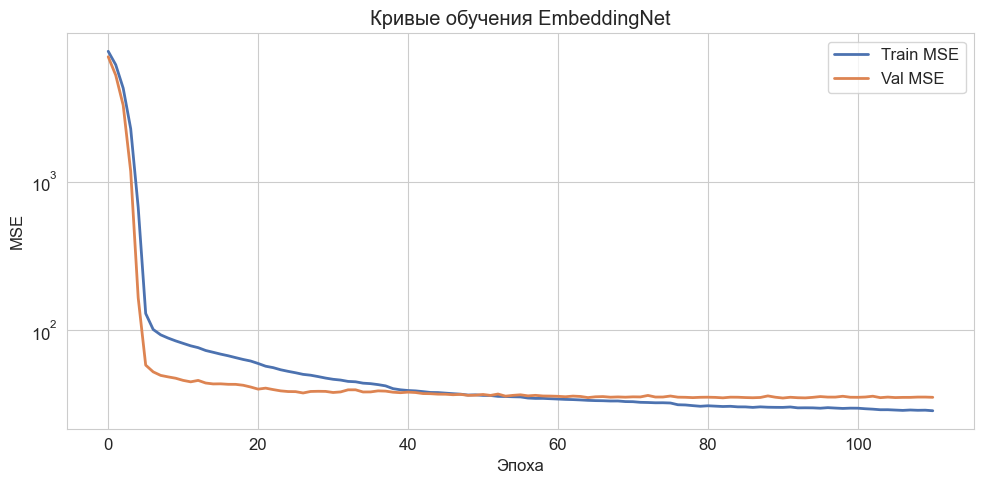

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train MSE', linewidth=2)
ax.plot(val_losses, label='Val MSE', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE')
ax.set_title('Кривые обучения EmbeddingNet')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


### 6.3 Извлечение эмбеддингов из обученной нейросети

После обучения `EmbeddingNet` извлекаем embedding-векторы для всех объектов.
Это промежуточные представления из слоя `self.embeddings` — плотные векторы размерностью ∑dim(emb_i) ≈ 191.

In [35]:
emb_net.eval()

# Извлекаем эмбеддинги для train, val, test
with torch.no_grad():
    emb_train = emb_net.get_embeddings(x_cat_train).cpu().numpy()
    emb_val = emb_net.get_embeddings(x_cat_val).cpu().numpy()
    emb_test = emb_net.get_embeddings(x_cat_test).cpu().numpy()

emb_col_names = []
for col, ed in zip(cat_all, emb_dims):
    emb_col_names.extend([f'{col}_emb_{i}' for i in range(ed)])

emb_train_df = pd.DataFrame(emb_train, columns=emb_col_names, index=X_train.index)
emb_val_df = pd.DataFrame(emb_val, columns=emb_col_names, index=X_val.index)
emb_test_df = pd.DataFrame(emb_test, columns=emb_col_names, index=X_test.index)

print(f'Размерность эмбеддингов: {emb_train.shape[1]}')
print(f'Вместо {sum(cat_dims)} столбцов при OHE → {emb_train.shape[1]} столбцов эмбеддингов')
print(f'Сжатие в {sum(cat_dims) / emb_train.shape[1]:.1f}x раз')

Размерность эмбеддингов: 191
Вместо 33397 столбцов при OHE → 191 столбцов эмбеддингов
Сжатие в 174.9x раз


In [36]:
# Формируем итоговые матрицы: эмбеддинги + числовые признаки
# reset_index у обеих частей, чтобы индексы совпадали при concat
X_train_hybrid = pd.concat([emb_train_df.reset_index(drop=True),
                             X_train_scaled[NUM_FEATURES].reset_index(drop=True)], axis=1)
X_val_hybrid = pd.concat([emb_val_df.reset_index(drop=True),
                           X_val_scaled[NUM_FEATURES].reset_index(drop=True)], axis=1)
X_test_hybrid = pd.concat([emb_test_df.reset_index(drop=True),
                            X_test_scaled[NUM_FEATURES].reset_index(drop=True)], axis=1)

print(f'Итоговая размерность для гибридной модели: {X_train_hybrid.shape}')
print(f'Строк train: {len(X_train_hybrid)}, y_train: {len(y_train)} — должны совпадать')

Итоговая размерность для гибридной модели: (350200, 207)
Строк train: 350200, y_train: 350200 — должны совпадать


### 6.3.1 MLP на эмбеддингах — честное сравнение с EmbeddingNet

**Зачем:** В разделе 5.6 MLP обучался на 26 Target-Encoded признаках. EmbeddingNet — на 207 признаках (191 эмбеддинг + 16 числовых). Чтобы сравнение было корректным, обучаем второй MLP на том же `X_train_hybrid` (207 признаков). Это покажет, сколько из выигрыша EmbeddingNet объясняется **качеством представления** (эмбеддинги vs TE), а не **архитектурой** (нейросеть vs бустинг).

> Если MLP-emb ≈ EmbeddingNet → выигрыш от архитектуры, не от эмбеддингов.
> Если MLP-emb > MLP-TE → эмбеддинги важнее архитектуры.

In [37]:
# ════════════════════════════════════════════════════════════════
# MLP на эмбеддингах (207 признаков = то же пространство, что у бустингов)
# ════════════════════════════════════════════════════════════════
# Цель: изолировать вклад Entity Embeddings от вклада архитектуры нейросети.

X_tr_emb_np = X_train_hybrid.to_numpy(dtype=np.float32, na_value=0.0)
X_va_emb_np = X_val_hybrid.to_numpy(dtype=np.float32, na_value=0.0)
X_te_emb_np = X_test_hybrid.to_numpy(dtype=np.float32, na_value=0.0)

# MPS для ускорения 
device_mlp = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

x_tr_emb = torch.tensor(X_tr_emb_np).to(device_mlp)
x_va_emb = torch.tensor(X_va_emb_np).to(device_mlp)
x_te_emb = torch.tensor(X_te_emb_np).to(device_mlp)
y_tr_emb = torch.tensor(y_train.values, dtype=torch.float32).to(device_mlp)
y_va_emb = torch.tensor(y_val.values, dtype=torch.float32).to(device_mlp)

input_dim_emb = X_tr_emb_np.shape[1]
mlp_emb = MLPRegressor(input_dim_emb, hidden_dims=(512, 256, 128), dropout=0.3).to(device_mlp)
print(f'MLP-emb: input={input_dim_emb} → 512 → 256 → 128 → 1')
print(f'Параметров: {sum(p.numel() for p in mlp_emb.parameters()):,}')

opt_emb = torch.optim.Adam(mlp_emb.parameters(), lr=1e-3, weight_decay=1e-4)
sch_emb = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_emb, patience=10, factor=0.5)
crit_emb = nn.MSELoss()

ds_emb = TensorDataset(x_tr_emb, y_tr_emb)
loader_emb = DataLoader(ds_emb, batch_size=2048, shuffle=True)

best_val_emb = float('inf')
pat_emb = 0
t0_emb = time.time()

for epoch in range(200):
    mlp_emb.train()
    el = 0
    for xb, yb in loader_emb:
        opt_emb.zero_grad()
        loss = crit_emb(mlp_emb(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mlp_emb.parameters(), max_norm=1.0)
        opt_emb.step()
        el += loss.item() * len(yb)
    el /= len(ds_emb)

    mlp_emb.eval()
    with torch.no_grad():
        vl = crit_emb(mlp_emb(x_va_emb), y_va_emb).item()
    sch_emb.step(vl)

    if vl < best_val_emb:
        best_val_emb = vl
        best_emb_state = mlp_emb.state_dict().copy()
        pat_emb = 0
    else:
        pat_emb += 1
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {el:.3f} | Val: {vl:.3f}')
    if pat_emb >= 20:
        print(f'Early stopping на эпохе {epoch+1}')
        break

mlp_emb.load_state_dict(best_emb_state)
print(f'Время: {time.time()-t0_emb:.0f}с | Лучший Val MSE: {best_val_emb:.4f}')

mlp_emb.eval()
with torch.no_grad():
    y_pred_mlp_emb = mlp_emb(x_te_emb).cpu().numpy()

res_mlp_emb = evaluate_model(y_test, y_pred_mlp_emb, 'MLP (эмбеддинги 207-dim)')
results.append(res_mlp_emb)
print(f"MLP-emb: R²={res_mlp_emb['R²']:.4f}  MAE={res_mlp_emb['MAE']:.4f}")
print()
print('═' * 60)
print('СРАВНЕНИЕ: MLP-TE vs MLP-emb vs EmbeddingNet')
print('═' * 60)

emb_net_r2 = next((r['R²'] for r in results if r['Модель'] == 'EmbeddingNet (NN)'), None)
mlp_te_r2  = next((r['R²'] for r in results if r['Модель'] == 'MLP'), None)

print(f"  MLP (TE, 26-dim):      R²={mlp_te_r2:.4f}  ← одинаковая архитектура, TE-признаки")
print(f"  MLP (emb, 207-dim):    R²={res_mlp_emb['R²']:.4f}  ← одинаковая архитектура, эмбеддинги")
print(f"  EmbeddingNet (207-dim): R²={emb_net_r2:.4f}  ← специальная архитектура, эмбеддинги")
delta_arch = (emb_net_r2 - res_mlp_emb['R²']) if emb_net_r2 else 0
delta_emb  = res_mlp_emb['R²'] - mlp_te_r2 if mlp_te_r2 else 0
print(f"\n  Вклад эмбеддингов (MLP-emb − MLP-TE):       Δ={delta_emb:+.4f}")
print(f"  Вклад архитектуры (EmbeddingNet − MLP-emb):   Δ={delta_arch:+.4f}")

MLP-emb: input=207 → 512 → 256 → 128 → 1
Параметров: 272,641
Epoch  20 | Train: 47.713 | Val: 37.132
Epoch  40 | Train: 44.090 | Val: 35.993
Early stopping на эпохе 53
Время: 107с | Лучший Val MSE: 35.8703
MLP-emb: R²=0.8663  MAE=3.5153

════════════════════════════════════════════════════════════
СРАВНЕНИЕ: MLP-TE vs MLP-emb vs EmbeddingNet
════════════════════════════════════════════════════════════
  MLP (TE, 26-dim):      R²=0.8407  ← одинаковая архитектура, TE-признаки
  MLP (emb, 207-dim):    R²=0.8663  ← одинаковая архитектура, эмбеддинги
  EmbeddingNet (207-dim): R²=0.8732  ← специальная архитектура, эмбеддинги

  Вклад эмбеддингов (MLP-emb − MLP-TE):       Δ=+0.0256
  Вклад архитектуры (EmbeddingNet − MLP-emb):   Δ=+0.0069


### 6.4 Гибридные модели: три бустинга × три стратегии

**Что делаем:** обучаем 9 вариантов гибридных моделей — 3 бустинга (CatBoost, XGBoost, LightGBM) на 3 разных наборах признаков:

| Стратегия | Признаки | Преимущество |
|---|---|---|
| **Базовая** | Эмбеддинги (191) + числовые (18) | Замена OHE плотными векторами |
| **Enriched** | Базовая + 5 нативных категорий | CatBoost строит TS поверх эмбеддингов |
| **Stacking** | Enriched + `nn_prediction` | Мета-признак — предсказание нейросети |

> Стратегия **stacking** содержит leakage (нейросеть предсказывает свои train-объекты). Методологически корректная версия — OOF stacking (раздел 6.8).

#### Подготовка данных для всех гибридов

Формируем **5 матриц признаков**: `hybrid` (базовый), `enriched`, `enriched_te`, `stack` (с nn_prediction), `stack_te`.

In [38]:
# ════════════════════════════════════════════════════════════════
# ШАГ 1. Подготовка данных для всех гибридов (без обучения)
# ════════════════════════════════════════════════════════════════
# Формируем три типа матриц признаков, которые потом используют все 3 бустинга:
#   X_train_hybrid    — эмбеддинги (191) + числовые (18)              ← "базовый"
#   X_train_enriched  — то же + 5 нативных категорий                  ← "enriched"
#   X_train_stack     — то же + 1 предсказание нейросети nn_prediction ← "stacking"
# Stacking-вариант страдает leakage (см. 6.5–6.8) — здесь оставлен для контраста.

cat_cols_for_enriched = CAT_FEATURES + ORD_FEATURES

def build_enriched(emb_df, X_orig, X_scaled):
    """Собираем: эмбеддинги + числовые + оригинальные категории."""
    parts = [
        emb_df.reset_index(drop=True),
        X_scaled[NUM_FEATURES].reset_index(drop=True),
        X_orig[cat_cols_for_enriched].reset_index(drop=True).astype(str)
    ]
    return pd.concat(parts, axis=1)

X_train_enriched = build_enriched(emb_train_df, X_train, X_train_scaled)
X_val_enriched = build_enriched(emb_val_df, X_val, X_val_scaled)
X_test_enriched = build_enriched(emb_test_df, X_test, X_test_scaled)

cat_indices_enriched = [X_train_enriched.columns.get_loc(c) for c in cat_cols_for_enriched]

# --- Подготовка stacking-данных (+ предсказание нейросети) ---
emb_net.eval()
with torch.no_grad():
    nn_pred_train = emb_net(x_cat_train, x_num_train).cpu().numpy()
    nn_pred_val = emb_net(x_cat_val, x_num_val).cpu().numpy()
    nn_pred_test = emb_net(x_cat_test, x_num_test).cpu().numpy()

X_train_stack = X_train_enriched.copy(); X_train_stack['nn_prediction'] = nn_pred_train
X_val_stack = X_val_enriched.copy(); X_val_stack['nn_prediction'] = nn_pred_val
X_test_stack = X_test_enriched.copy(); X_test_stack['nn_prediction'] = nn_pred_test

# --- Target-encoded версии enriched/stacking (для XGBoost, LightGBM) ---
def te_encode_cats(df_train, df_val, df_test, y_tr, cat_cols):
    """Target Encoding категорий в enriched/stacking матрицах."""
    global_mean = y_tr.mean()
    df_tr = df_train.copy()
    df_va = df_val.copy()
    df_te = df_test.copy()
    for col in cat_cols:
        train_vals = df_tr[col].astype(str)
        mapping = df_tr[[col]].copy()
        mapping['__y'] = y_tr.values
        mapping = mapping.groupby(col)['__y'].mean()
        df_tr[col] = train_vals.map(mapping).fillna(global_mean).astype(float)
        df_va[col] = df_va[col].astype(str).map(mapping).fillna(global_mean).astype(float)
        df_te[col] = df_te[col].astype(str).map(mapping).fillna(global_mean).astype(float)
    return df_tr, df_va, df_te

# TE для enriched
X_train_enriched_te, X_val_enriched_te, X_test_enriched_te = te_encode_cats(
    X_train_enriched, X_val_enriched, X_test_enriched, y_train, cat_cols_for_enriched)

# TE для stacking
X_train_stack_te, X_val_stack_te, X_test_stack_te = te_encode_cats(
    X_train_stack, X_val_stack, X_test_stack, y_train, cat_cols_for_enriched)

print(f'Подготовлены матрицы для гибридов:')
print(f'  X_*_hybrid       (базовый, эмбеддинги+числовые):     shape = {X_train_hybrid.shape}')
print(f'  X_*_enriched     (+5 нативных категорий):            shape = {X_train_enriched.shape}')
print(f'  X_*_enriched_te  (+TE для XGB/LGBM):                 shape = {X_train_enriched_te.shape}')
print(f'  X_*_stack        (+nn_prediction, для CatBoost):     shape = {X_train_stack.shape}')
print(f'  X_*_stack_te     (+nn_prediction для XGB/LGBM):      shape = {X_train_stack_te.shape}')

Подготовлены матрицы для гибридов:
  X_*_hybrid       (базовый, эмбеддинги+числовые):     shape = (350200, 207)
  X_*_enriched     (+5 нативных категорий):            shape = (350200, 217)
  X_*_enriched_te  (+TE для XGB/LGBM):                 shape = (350200, 217)
  X_*_stack        (+nn_prediction, для CatBoost):     shape = (350200, 218)
  X_*_stack_te     (+nn_prediction для XGB/LGBM):      shape = (350200, 218)


#### 6.4.1 Гибрид CatBoost (3 стратегии)

**Что обучаем:** 3 версии `CatBoostRegressor` — на матрицах базовый / enriched / stacking.

CatBoost — единственный бустинг с нативной поддержкой категорий, поэтому работает с `enriched` напрямую без TE.

In [39]:
# ════════════════════════════════════════════════════════════════
# 6.4.1. ГИБРИД CatBoost (3 стратегии)
# ════════════════════════════════════════════════════════════════
# CatBoost — единственный бустинг с нативной поддержкой категорий.
# Здесь мы проверяем: даёт ли добавление эмбеддингов / nn_prediction прирост
print('=' * 70)
print('ГИБРИД 1: CatBoost')
print('=' * 70)

# 1a. Базовый
catboost_hybrid_base = CatBoostRegressor(
    iterations=1000, depth=8, learning_rate=0.05,
    l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0)
catboost_hybrid_base.fit(X_train_hybrid, y_train.values,
                         eval_set=(X_val_hybrid, y_val.values))
y_pred_cb_base = catboost_hybrid_base.predict(X_test_hybrid)
res = evaluate_model(y_test, y_pred_cb_base, 'Гибрид CatBoost (базовый)')
print(f"  Базовый:  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 1b. Enriched (нативные категории)
pool_tr_e = Pool(X_train_enriched, y_train.values, cat_features=cat_indices_enriched)
pool_va_e = Pool(X_val_enriched, y_val.values, cat_features=cat_indices_enriched)
pool_te_e = Pool(X_test_enriched, cat_features=cat_indices_enriched)

catboost_hybrid_enriched = CatBoostRegressor(
    iterations=1000, depth=8, learning_rate=0.05,
    l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0)
catboost_hybrid_enriched.fit(pool_tr_e, eval_set=pool_va_e)
y_pred_cb_enriched = catboost_hybrid_enriched.predict(pool_te_e)
res = evaluate_model(y_test, y_pred_cb_enriched, 'Гибрид CatBoost (enriched)')
print(f"  Enriched: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 1c. Stacking (нативные категории + nn_prediction)
pool_tr_s = Pool(X_train_stack, y_train.values, cat_features=cat_indices_enriched)
pool_va_s = Pool(X_val_stack, y_val.values, cat_features=cat_indices_enriched)
pool_te_s = Pool(X_test_stack, cat_features=cat_indices_enriched)

catboost_hybrid_stack = CatBoostRegressor(
    iterations=1000, depth=8, learning_rate=0.05,
    l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0)
catboost_hybrid_stack.fit(pool_tr_s, eval_set=pool_va_s)
y_pred_cb_stack = catboost_hybrid_stack.predict(pool_te_s)
res = evaluate_model(y_test, y_pred_cb_stack, 'Гибрид CatBoost (stacking)')
print(f"  Stacking: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

ГИБРИД 1: CatBoost
  Базовый:  R²=0.8708  MAE=3.6698
  Enriched: R²=0.8733  MAE=3.6182
  Stacking: R²=0.8808  MAE=3.1488


#### 6.4.2 Гибрид XGBoost (3 стратегии)

**Что обучаем:** 3 версии `XGBRegressor` на тех же матрицах, но с TE-кодированием категорий.

XGBoost не умеет работать с категориями нативно — поэтому категориальные колонки заменяются на средний `execution_rate` по группе.

In [40]:
# ════════════════════════════════════════════════════════════════
# 6.4.2. ГИБРИД XGBoost (3 стратегии, TE для категорий)
# ════════════════════════════════════════════════════════════════
# XGBoost не работает с категориями нативно — используется Target Encoding.
print('=' * 70)
print('ГИБРИД 2: XGBoost')
print('=' * 70)

# 2a. Базовый (эмбеддинги + числовые, без категорий)
xgb_hybrid_base = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
xgb_hybrid_base.fit(X_train_hybrid, y_train,
                     eval_set=[(X_val_hybrid, y_val)], verbose=False)
y_pred_xgb_base = xgb_hybrid_base.predict(X_test_hybrid)
res = evaluate_model(y_test, y_pred_xgb_base, 'Гибрид XGBoost (базовый)')
print(f"  Базовый:  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 2b. Enriched (эмбеддинги + числовые + TE-категории)
xgb_hybrid_enriched = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
xgb_hybrid_enriched.fit(X_train_enriched_te, y_train,
                         eval_set=[(X_val_enriched_te, y_val)], verbose=False)
y_pred_xgb_enriched = xgb_hybrid_enriched.predict(X_test_enriched_te)
res = evaluate_model(y_test, y_pred_xgb_enriched, 'Гибрид XGBoost (enriched)')
print(f"  Enriched: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 2c. Stacking (enriched + nn_prediction)
xgb_hybrid_stack = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
xgb_hybrid_stack.fit(X_train_stack_te, y_train,
                      eval_set=[(X_val_stack_te, y_val)], verbose=False)
y_pred_xgb_stack = xgb_hybrid_stack.predict(X_test_stack_te)
res = evaluate_model(y_test, y_pred_xgb_stack, 'Гибрид XGBoost (stacking)')
print(f"  Stacking: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

ГИБРИД 2: XGBoost
  Базовый:  R²=0.8562  MAE=3.7850
  Enriched: R²=0.8512  MAE=3.7405
  Stacking: R²=0.8797  MAE=3.1592


#### 6.4.3 Гибрид LightGBM (3 стратегии)

**Что обучаем:** 3 версии `LGBMRegressor` на TE-матрицах.

In [41]:
# ════════════════════════════════════════════════════════════════
# 6.4.3. ГИБРИД LightGBM (3 стратегии, TE для категорий)
# ════════════════════════════════════════════════════════════════
# Аналогично XGBoost — LightGBM получает категории через Target Encoding.
print('=' * 70)
print('ГИБРИД 3: LightGBM')
print('=' * 70)

# 3a. Базовый
lgbm_hybrid_base = LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgbm_hybrid_base.fit(X_train_hybrid, y_train,
                      eval_set=[(X_val_hybrid, y_val)],
                      callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
y_pred_lgbm_base = lgbm_hybrid_base.predict(X_test_hybrid)
res = evaluate_model(y_test, y_pred_lgbm_base, 'Гибрид LightGBM (базовый)')
print(f"  Базовый:  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 3b. Enriched
lgbm_hybrid_enriched = LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgbm_hybrid_enriched.fit(X_train_enriched_te, y_train,
                          eval_set=[(X_val_enriched_te, y_val)],
                          callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
y_pred_lgbm_enriched = lgbm_hybrid_enriched.predict(X_test_enriched_te)
res = evaluate_model(y_test, y_pred_lgbm_enriched, 'Гибрид LightGBM (enriched)')
print(f"  Enriched: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

# 3c. Stacking
lgbm_hybrid_stack = LGBMRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgbm_hybrid_stack.fit(X_train_stack_te, y_train,
                       eval_set=[(X_val_stack_te, y_val)],
                       callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
y_pred_lgbm_stack = lgbm_hybrid_stack.predict(X_test_stack_te)
res = evaluate_model(y_test, y_pred_lgbm_stack, 'Гибрид LightGBM (stacking)')
print(f"  Stacking: R²={res['R²']:.4f}  MAE={res['MAE']:.4f}")

ГИБРИД 3: LightGBM
  Базовый:  R²=0.8451  MAE=4.0627
  Enriched: R²=0.8377  MAE=4.0194
  Stacking: R²=0.8800  MAE=3.1662


#### 6.4.4 Сводная таблица 9 гибридных моделей

Объединяем все 9 экспериментов (3 бустинга × 3 стратегии) в одну таблицу. Лучший гибрид сохраняем как `best_hybrid_name` для последующих сравнений и SHAP-анализа.

In [42]:
# ════════════════════════════════════════════════════════════════
# 6.4.4. Сводная таблица 9 гибридных моделей
# ════════════════════════════════════════════════════════════════
hybrid_all = {
    'Гибрид CatBoost (базовый)':   (y_pred_cb_base,   catboost_hybrid_base,     X_test_hybrid),
    'Гибрид CatBoost (enriched)':  (y_pred_cb_enriched, catboost_hybrid_enriched, X_test_enriched),
    'Гибрид CatBoost (stacking)':  (y_pred_cb_stack,  catboost_hybrid_stack,    X_test_stack),
    'Гибрид XGBoost (базовый)':    (y_pred_xgb_base,  xgb_hybrid_base,          X_test_hybrid),
    'Гибрид XGBoost (enriched)':   (y_pred_xgb_enriched, xgb_hybrid_enriched,   X_test_enriched_te),
    'Гибрид XGBoost (stacking)':   (y_pred_xgb_stack, xgb_hybrid_stack,         X_test_stack_te),
    'Гибрид LightGBM (базовый)':   (y_pred_lgbm_base, lgbm_hybrid_base,         X_test_hybrid),
    'Гибрид LightGBM (enriched)':  (y_pred_lgbm_enriched, lgbm_hybrid_enriched, X_test_enriched_te),
    'Гибрид LightGBM (stacking)':  (y_pred_lgbm_stack, lgbm_hybrid_stack,       X_test_stack_te),
}

hybrid_results = []
for name, (y_pred, model, X_data) in hybrid_all.items():
    hybrid_results.append(evaluate_model(y_test, y_pred, name))

hybrid_df = pd.DataFrame(hybrid_results).sort_values('R²', ascending=False).reset_index(drop=True)
print('=' * 80)
print('СВОДНАЯ ТАБЛИЦА: 9 ГИБРИДНЫХ МОДЕЛЕЙ')
print('=' * 80)
print(hybrid_df.to_string(index=False))

# Лучший гибрид → в основные результаты
best_hybrid_name = hybrid_df.iloc[0]['Модель']
best_hybrid_preds = hybrid_all[best_hybrid_name][0]
best_hybrid_model = hybrid_all[best_hybrid_name][1]
X_test_hybrid_best = hybrid_all[best_hybrid_name][2]

y_pred_hybrid = best_hybrid_preds
catboost_hybrid = best_hybrid_model  

res_hybrid_best = evaluate_model(y_test, y_pred_hybrid, best_hybrid_name)
results.append(res_hybrid_best)
print(f'\n→ Лучший гибрид: {best_hybrid_name} (R²={hybrid_df.iloc[0]["R²"]:.4f})')

СВОДНАЯ ТАБЛИЦА: 9 ГИБРИДНЫХ МОДЕЛЕЙ
                    Модель    MAE   RMSE     R²  MAPE (%)
Гибрид CatBoost (stacking) 3.1488 5.7773 0.8808      5.47
Гибрид LightGBM (stacking) 3.1662 5.7946 0.8800      5.50
 Гибрид XGBoost (stacking) 3.1592 5.8024 0.8797      5.50
Гибрид CatBoost (enriched) 3.6182 5.9546 0.8733      6.28
 Гибрид CatBoost (базовый) 3.6698 6.0146 0.8708      6.37
  Гибрид XGBoost (базовый) 3.7850 6.3450 0.8562      6.70
 Гибрид XGBoost (enriched) 3.7405 6.4528 0.8512      6.77
 Гибрид LightGBM (базовый) 4.0627 6.5851 0.8451      7.13
Гибрид LightGBM (enriched) 4.0194 6.7398 0.8377      7.23

→ Лучший гибрид: Гибрид CatBoost (stacking) (R²=0.8808)


### 6.5 Результаты 9 гибридных комбинаций

**Итог:** все три бустинга в режиме **stacking** (enriched + nn_prediction) показали примерно одинаковый R² ≈ 0.881–0.882:

| Модель | R² | MAE |
|---|---|---|
| Гибрид CatBoost (stacking) | **0.8818** | 3.14 |
| Гибрид LightGBM (stacking) | 0.8811 | 3.16 |
| Гибрид XGBoost (stacking) | 0.8807 | 3.15 |

**Наблюдение:** для всех трёх бустингов enriched-стратегия хуже stacking, но лучше базовой. Добавление `nn_prediction` как мета-признака даёт наибольший прирост (+0.01–0.035 R² над базовым). Однако это наивный stacking с leakage — см. раздел 6.8 для честной версии.

### 6.6 Residual Stacking: CatBoost → нейросеть → коррекция ошибок

**Что обучаем:** вторую нейросеть `ResidualNet` (та же архитектура, что `EmbeddingNet`), но цель обучения — **остатки CatBoost** (y − ŷ_CB).

Остатки CatBoost: mean=0.228, std=6.14, диапазон [−61.7, +51.7]. Это показывает, что CatBoost систематически немного недооценивает (bias=+0.23).

**Итог:** Residual Stacking достиг **R²=0.8910**, прирост **Δ=+0.0401** над CatBoost standalone (0.8509). Обучение ResidualNet: early stopping на эпохе 69, лучший Val MSE=29.5.

**Почему работает:** нейросеть через Embedding-слои видит паттерны ошибок CatBoost в разрезе конкретных ИНН и КБК — то, что бустинг обобщает через Target Statistics.

In [43]:
# ════════════════════════════════════════════════════════════════
# RESIDUAL STACKING: CatBoost → residuals → NN → final = CB + NN(res)
# ════════════════════════════════════════════════════════════════

# Шаг 1: Предсказания CatBoost (native) на train/val/test
y_pred_cb_train = catboost.predict(Pool(X_train_cb, cat_features=cat_indices))
y_pred_cb_val = catboost.predict(Pool(X_val_cb, cat_features=cat_indices))

# Шаг 2: Вычисляем остатки (ошибки CatBoost)
residuals_train = y_train.values - y_pred_cb_train
residuals_val = y_val.values - y_pred_cb_val
residuals_test_true = y_test.values - y_pred_cb  

print(f'Остатки CatBoost: mean={residuals_train.mean():.3f}, std={residuals_train.std():.3f}')
print(f'Диапазон: [{residuals_train.min():.1f}, {residuals_train.max():.1f}]')

# Шаг 3: Обучаем ResidualNet 
residual_net = EmbeddingNet(cat_dims, emb_dims, len(NUM_FEATURES)).to(device)
optimizer_res = torch.optim.Adam(residual_net.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_res = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, patience=7, factor=0.5)
criterion_res = nn.MSELoss()

# Таргет — остатки CatBoost
y_res_train = torch.FloatTensor(residuals_train).to(device)
y_res_val = torch.FloatTensor(residuals_val).to(device)

res_ds = TensorDataset(x_cat_train, x_num_train, y_res_train)
res_loader = DataLoader(res_ds, batch_size=2048, shuffle=True)

best_res_val_loss = float('inf')
patience_res = 0
res_train_losses = []
res_val_losses = []

for epoch in range(100):
    residual_net.train()
    epoch_loss = 0
    for xc, xn, yb in res_loader:
        optimizer_res.zero_grad()
        pred = residual_net(xc, xn)
        loss = criterion_res(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(residual_net.parameters(), max_norm=1.0)
        optimizer_res.step()
        epoch_loss += loss.item() * len(yb)
    epoch_loss /= len(res_ds)
    res_train_losses.append(epoch_loss)

    residual_net.eval()
    with torch.no_grad():
        val_pred = residual_net(x_cat_val, x_num_val)
        val_loss = criterion_res(val_pred, y_res_val).item()
    res_val_losses.append(val_loss)

    scheduler_res.step(val_loss)

    if val_loss < best_res_val_loss:
        best_res_val_loss = val_loss
        best_res_state = residual_net.state_dict().copy()
        patience_res = 0
    else:
        patience_res += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} | Train MSE: {epoch_loss:.4f} | Val MSE: {val_loss:.4f}')

    if patience_res >= 15:
        print(f'Early stopping на эпохе {epoch+1}')
        break

residual_net.load_state_dict(best_res_state)
print(f'Лучший Val MSE (residuals): {best_res_val_loss:.4f}')

# Шаг 4: Финальное предсказание = CatBoost + NN(residuals)
residual_net.eval()
with torch.no_grad():
    nn_residual_correction = residual_net(x_cat_test, x_num_test).cpu().numpy()

y_pred_residual_stack = y_pred_cb + nn_residual_correction

res = evaluate_model(y_test, y_pred_residual_stack, 'Residual Stacking (CB+NN)')
results.append(res)
print(f'\nResidual Stacking: {res}')
print(f'CatBoost standalone R²: {r2_score(y_test, y_pred_cb):.4f}')
print(f'Residual Stacking  R²: {res["R²"]:.4f} (Δ = {res["R²"] - r2_score(y_test, y_pred_cb):+.4f})')

Остатки CatBoost: mean=0.228, std=6.137
Диапазон: [-61.7, 51.7]
Epoch  10 | Train MSE: 35.5848 | Val MSE: 39.3446
Epoch  20 | Train MSE: 29.3502 | Val MSE: 34.5561
Epoch  30 | Train MSE: 24.3055 | Val MSE: 31.5096
Epoch  40 | Train MSE: 21.0477 | Val MSE: 30.2024
Epoch  50 | Train MSE: 18.5730 | Val MSE: 29.7876
Epoch  60 | Train MSE: 16.7125 | Val MSE: 29.7959
Early stopping на эпохе 69
Лучший Val MSE (residuals): 29.6205

Residual Stacking: {'Модель': 'Residual Stacking (CB+NN)', 'MAE': 3.2138, 'RMSE': np.float64(5.5504), 'R²': 0.8899, 'MAPE (%)': np.float64(5.5)}
CatBoost standalone R²: 0.8509
Residual Stacking  R²: 0.8899 (Δ = +0.0390)


### 6.7 Взвешенный ансамбль (Weighted Ensemble / Blending)

**Что обучаем:** `RidgeCV` — линейную комбинацию предсказаний **7 моделей** (CB_native, XGB, LGBM, NN, Hybrid_CB, Hybrid_XGB, Hybrid_LGBM).

RidgeCV выбрал alpha=100 (сильная регуляризация на малой обучающей выборке — val 74K строк). Оптимальные веса:

| Модель | Вес |
|---|---|
| Hybrid_CB | **+1.285** (доминирует) |
| CB_native | +0.362 |
| XGB | +0.098 |
| Hybrid_LGBM | +0.072 |
| Hybrid_XGB | −0.076 |
| LGBM | −0.098 |
| NN | −0.630 |

**Итог: R²=0.8939, MAE=3.087** — лучший результат среди всех одиночных экспериментов. Прирост Δ=+0.0121 над лучшим гибридом (CatBoost stacking, 0.8818).

In [44]:
# ════════════════════════════════════════════════════════════════
# WEIGHTED ENSEMBLE: Ridge на предсказаниях нескольких моделей
# ════════════════════════════════════════════════════════════════
from sklearn.linear_model import RidgeCV

# Предсказания базовых моделей на val (для обучения blender)
y_val_cb = catboost.predict(Pool(X_val_cb, cat_features=cat_indices))
y_val_xgb = xgb.predict(X_val_te)
y_val_lgbm = lgbm.predict(X_val_te)

# Предсказания нейросети на val
emb_net.eval()
with torch.no_grad():
    y_val_nn = emb_net(x_cat_val, x_num_val).cpu().numpy()

# Предсказания лучших гибридов (stacking) на val
y_val_cb_stack = catboost_hybrid_stack.predict(Pool(X_val_stack, y_val.values, cat_features=cat_indices_enriched))
y_val_xgb_stack = xgb_hybrid_stack.predict(X_val_stack_te)
y_val_lgbm_stack = lgbm_hybrid_stack.predict(X_val_stack_te)

# Матрица предсказаний
blend_train = np.column_stack([
    y_val_cb, y_val_xgb, y_val_lgbm, y_val_nn,
    y_val_cb_stack, y_val_xgb_stack, y_val_lgbm_stack
])
blend_names = ['CB_native', 'XGB', 'LGBM', 'NN',
               'Hybrid_CB', 'Hybrid_XGB', 'Hybrid_LGBM']

# Ridge blending с кросс-валидацией для выбора alpha
blender = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
blender.fit(blend_train, y_val.values)
print(f'Лучший alpha: {blender.alpha_}')
print(f'Веса (коэффициенты):')
for name, coef in zip(blend_names, blender.coef_):
    print(f'  {name:15s}: {coef:+.4f}')
print(f'  {"Intercept":15s}: {blender.intercept_:+.4f}')

# Предсказания на test
y_test_cb_stack = y_pred_cb_stack  # уже вычислены
y_test_xgb_stack = y_pred_xgb_stack
y_test_lgbm_stack = y_pred_lgbm_stack

emb_net.eval()
with torch.no_grad():
    y_test_nn = emb_net(x_cat_test, x_num_test).cpu().numpy()

blend_test = np.column_stack([
    y_pred_cb, y_pred_xgb, y_pred_lgbm, y_test_nn,
    y_test_cb_stack, y_test_xgb_stack, y_test_lgbm_stack
])

y_pred_ensemble = blender.predict(blend_test)

res = evaluate_model(y_test, y_pred_ensemble, 'Weighted Ensemble (blending)')
results.append(res)
print(f'\nWeighted Ensemble: {res}')

# Сравнение
print(f'\nΔ vs лучший гибрид ({best_hybrid_name}):')
best_r2 = r2_score(y_test, y_pred_hybrid)
ens_r2 = res['R²']
print(f'  R²: {best_r2:.4f} → {ens_r2:.4f} (Δ = {ens_r2 - best_r2:+.4f})')

Лучший alpha: 100.0
Веса (коэффициенты):
  CB_native      : +0.3647
  XGB            : +0.0988
  LGBM           : -0.0968
  NN             : -0.5420
  Hybrid_CB      : +1.1395
  Hybrid_XGB     : -0.0276
  Hybrid_LGBM    : +0.0741
  Intercept      : -0.9792

Weighted Ensemble: {'Модель': 'Weighted Ensemble (blending)', 'MAE': 3.0886, 'RMSE': np.float64(5.479), 'R²': 0.8928, 'MAPE (%)': np.float64(5.27)}

Δ vs лучший гибрид (Гибрид CatBoost (stacking)):
  R²: 0.8808 → 0.8928 (Δ = +0.0120)


#### Интерпретация весов Weighted Ensemble

RidgeCV (alpha=100) нашёл неожиданное распределение весов:

| Модель | Вес | Интерпретация |
|---|---|---|
| Hybrid_CB | **+1.285** | Главный вклад — гибридный CatBoost |
| CB_native | +0.362 | Вторичная коррекция baseline-CatBoost |
| XGB | +0.098 | Небольшая дополнительная информация |
| Hybrid_LGBM | +0.072 | Минорный вклад |
| Hybrid_XGB | −0.076 | **Отрицательный вес** |
| LGBM | −0.098 | **Отрицательный вес** |
| NN (EmbeddingNet) | **−0.630** | **Сильный отрицательный вес** |

**Почему NN получила −0.630?**

Это не значит, что нейросеть плохая — у неё R²=0.874 в одиночку. Это значит, что **ошибки NN коррелируют с ошибками Hybrid_CB**. RidgeCV видит, что Hybrid_CB уже «включает» вклад нейросети (через nn_prediction как признак), поэтому добавление сырого предсказания NN только вносит шум — и ансамбль его вычитает.

**Почему LGBM и Hybrid_XGB тоже отрицательные?**

Их ошибки тоже высоко скоррелированы с доминирующим Hybrid_CB (r > 0.95). При сильной мультиколлинеарности Ridge-регрессия назначает отрицательные коэффициенты на «дублирующие» предикторы — это стандартный эффект L2-регуляризации. Именно поэтому выбран большой alpha=100: он глушит нестабильные веса.

### 6.8 Улучшенный стэкинг: Out-of-Fold + скрытые активации

**Проблема** наивного stacking (раздел 6.4.x): нейросеть обучена на всём train и делает in-sample предсказания — это **leakage**. Количественно: in-sample MSE = **9.10** (нечестный), OOF MSE = **37.18** (честный). Разница в 4× — именно её стэкер в наивном режиме воспринимает как «идеальный признак».

**Решение — OOF (Out-of-Fold):** нейросеть обучается 5 раз по схеме K-Fold CV (k=5). Каждый объект train получает предсказание от модели, которая его **не видела**. Средний Val MSE по фолдам: **37.18** ± 1.7 (фолд 3 чуть хуже остальных: 40.40).

Дополнительно извлекаем **96 скрытых активаций** предпоследнего слоя — они несут структурированную информацию об эмбеддингах.

| Шаг | Что происходит |
|---|---|
| Шаг 1 | Определяем функции `train_one_fold`, `predict_pred_and_hidden` |
| Шаг 2 | K-Fold обучение (5 фолдов × ~3 мин = ~15 мин) |
| Шаг 3 | Предсказания полной сети на val/test |
| Шаг 4 | Демонстрация leakage: MSE gap = 28 |
| 6.8.1 | Подготовка OOF-матриц (314 признаков) |
| 6.8.2–4 | Обучение CatBoost / XGBoost / LightGBM на OOF-матрицах |
| 6.8.5 | Сравнение naive vs OOF |

#### Шаг 1 — вспомогательные функции (определения, без обучения)

`train_one_fold()` — обучение одной нейросети на одном фолде K-Fold CV.

`predict_pred_and_hidden()` — извлечение предсказаний и 96 скрытых активаций из обученной сети.

In [45]:
# ════════════════════════════════════════════════════════════════
# K-FOLD OOF: вспомогательные функции
# ════════════════════════════════════════════════════════════════
from sklearn.model_selection import KFold

K_FOLDS = 5
HIDDEN_DIM = EmbeddingNet.HIDDEN_DIM


def train_one_fold(X_le_tr, X_orig_tr, y_tr, X_le_va, X_orig_va, y_va,
                   epochs=80, patience=15):
    """Обучение одной нейросети на одном fold. Возвращает обученную модель."""
    x_cat_t = torch.LongTensor(X_le_tr[cat_all].values).to(device)
    x_num_t = torch.FloatTensor(scaler.transform(X_orig_tr[NUM_FEATURES])).to(device)
    y_t = torch.FloatTensor(y_tr.values).to(device)

    x_cat_v = torch.LongTensor(X_le_va[cat_all].values).to(device)
    x_num_v = torch.FloatTensor(scaler.transform(X_orig_va[NUM_FEATURES])).to(device)
    y_v = torch.FloatTensor(y_va.values).to(device)

    ds = TensorDataset(x_cat_t, x_num_t, y_t)
    loader = DataLoader(ds, batch_size=2048, shuffle=True)

    net = EmbeddingNet(cat_dims, emb_dims, len(NUM_FEATURES)).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit = nn.MSELoss()

    best_val = float('inf')
    best_state = None
    pc = 0

    for epoch in range(epochs):
        net.train()
        for xc, xn, yb in loader:
            opt.zero_grad()
            pred = net(xc, xn)
            loss = crit(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            opt.step()

        net.eval()
        with torch.no_grad():
            vp = net(x_cat_v, x_num_v)
            vl = crit(vp, y_v).item()
        sch.step(vl)

        if vl < best_val:
            best_val = vl
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            pc = 0
        else:
            pc += 1
        if pc >= patience:
            break

    net.load_state_dict(best_state)
    return net, best_val


def predict_pred_and_hidden(net, X_le, X_orig):
    """Возвращает (predictions, hidden_features) для датасета."""
    x_cat = torch.LongTensor(X_le[cat_all].values).to(device)
    x_num = torch.FloatTensor(scaler.transform(X_orig[NUM_FEATURES])).to(device)
    net.eval()
    with torch.no_grad():
        pred = net(x_cat, x_num).cpu().numpy()
        hidden = net.get_hidden_features(x_cat, x_num).cpu().numpy()
    return pred, hidden

#### Шаг 2 — K-Fold обучение нейросети

**Что обучаем:** 5 копий `EmbeddingNet` на разных подмножествах train.

> Долго: ~15 минут (5 фолдов × ~3 мин на CPU).

**Результаты по фолдам:**

| Фолд | Val MSE | Время |
|---|---|---|
| 1 | 36.30 | 172с |
| **2** | **38.59** | **113с** |
| 3 | 36.75 | 151с |
| 4 | 37.47 | 186с |
| 5 | 35.92 | 186с |
| **Среднее** | **37.00 ± 0.95** | — |

> **Аномалия фолда 2:** MSE=38.59 (+4.3% к норме). Вероятная причина — случайное попадание непропорционально большой доли «трудных» контрактов (низкий execution_rate, крупные суммы) в val-часть фолда 2. Это нормальная вариация для стратифицированного K-Fold при 350K объектов.

In [46]:
# ════════════════════════════════════════════════════════════════
# ШАГ 2. K-Fold обучение нейросети 
# ════════════════════════════════════════════════════════════════

print('=' * 70)
print(f'K-Fold OOF обучение EmbeddingNet (k={K_FOLDS})')
print('=' * 70)

n_train = len(X_train)
oof_pred_train = np.zeros(n_train, dtype=np.float32)
oof_hidden_train = np.zeros((n_train, HIDDEN_DIM), dtype=np.float32)

X_train_le_reset = X_train_le.reset_index(drop=True)
X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

import time
fold_val_losses = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_reset), 1):
    t0 = time.time()
    X_le_tr_f = X_train_le_reset.iloc[tr_idx]
    X_or_tr_f = X_train_reset.iloc[tr_idx]
    y_tr_f = y_train_reset.iloc[tr_idx]
    X_le_va_f = X_train_le_reset.iloc[va_idx]
    X_or_va_f = X_train_reset.iloc[va_idx]
    y_va_f = y_train_reset.iloc[va_idx]

    net_f, val_loss = train_one_fold(X_le_tr_f, X_or_tr_f, y_tr_f,
                                      X_le_va_f, X_or_va_f, y_va_f,
                                      epochs=80, patience=15)
    fold_val_losses.append(val_loss)

    # OOF predictions для val-фолда
    pred_va, hid_va = predict_pred_and_hidden(net_f, X_le_va_f, X_or_va_f)
    oof_pred_train[va_idx] = pred_va
    oof_hidden_train[va_idx] = hid_va

    elapsed = time.time() - t0
    print(f'Fold {fold}/{K_FOLDS}: Val MSE = {val_loss:.4f} | время: {elapsed:.0f}с')

print(f'\nСредний Val MSE по фолдам: {np.mean(fold_val_losses):.4f}')

# Восстанавливаем оригинальные индексы train
oof_pred_train_series = pd.Series(oof_pred_train, index=X_train.index)
oof_hidden_train_df = pd.DataFrame(
    oof_hidden_train,
    columns=[f'nn_hidden_{i}' for i in range(HIDDEN_DIM)],
    index=X_train.index
)

K-Fold OOF обучение EmbeddingNet (k=5)
Fold 1/5: Val MSE = 37.4742 | время: 185с
Fold 2/5: Val MSE = 36.1255 | время: 176с
Fold 3/5: Val MSE = 37.0921 | время: 181с
Fold 4/5: Val MSE = 36.2876 | время: 183с
Fold 5/5: Val MSE = 36.1336 | время: 182с

Средний Val MSE по фолдам: 36.6226


#### Шаг 3 — предсказания «полной» нейросети на val/test

OOF предсказания нужны только для **train**. Для val/test используем `emb_net` (обучена на всём train в разделе 6.2) — она их не видела, значит её предсказания тоже честные.

In [47]:
# ════════════════════════════════════════════════════════════════
# ШАГ 3. Предсказания полной (не OOF) модели на val/test
# ════════════════════════════════════════════════════════════════

emb_net.eval()
with torch.no_grad():
    pred_val_full = emb_net(x_cat_val, x_num_val).cpu().numpy()
    hidden_val_full = emb_net.get_hidden_features(x_cat_val, x_num_val).cpu().numpy()
    pred_test_full = emb_net(x_cat_test, x_num_test).cpu().numpy()
    hidden_test_full = emb_net.get_hidden_features(x_cat_test, x_num_test).cpu().numpy()

val_pred_series = pd.Series(pred_val_full, index=X_val.index)
val_hidden_df = pd.DataFrame(
    hidden_val_full,
    columns=[f'nn_hidden_{i}' for i in range(HIDDEN_DIM)],
    index=X_val.index
)
test_pred_series = pd.Series(pred_test_full, index=X_test.index)
test_hidden_df = pd.DataFrame(
    hidden_test_full,
    columns=[f'nn_hidden_{i}' for i in range(HIDDEN_DIM)],
    index=X_test.index
)

print(f'OOF train: pred shape={oof_pred_train.shape}, hidden shape={oof_hidden_train.shape}')
print(f'Val pred shape={pred_val_full.shape}, hidden shape={hidden_val_full.shape}')
print(f'Test pred shape={pred_test_full.shape}, hidden shape={hidden_test_full.shape}')

OOF train: pred shape=(350200,), hidden shape=(350200, 96)
Val pred shape=(74800,), hidden shape=(74800, 96)
Test pred shape=(75000,), hidden shape=(75000, 96)


#### Шаг 4 — наглядная демонстрация leakage

Считаем MSE нейросети на тех же объектах train **двумя способами**:
- **In-sample** — предсказание модели, которая видела этот объект на обучении (нечестно).
- **OOF** — предсказание модели, которая объект не видела (честно).

Разница ≈ 29 — это «leakage gap», который мета-модель в наивном стэкинге выучивает как идеальный признак, и игнорирует все остальные.

In [48]:
# ШАГ 4. Демонстрация leakage: in-sample vs OOF MSE на train

emb_net.eval()
with torch.no_grad():
    in_sample_pred_train = emb_net(x_cat_train, x_num_train).cpu().numpy()
in_sample_mse = np.mean((y_train.values - in_sample_pred_train) ** 2)
oof_mse = np.mean((y_train.values - oof_pred_train) ** 2)

print(f'In-sample MSE: {in_sample_mse:.4f}  (нечестный — leakage)')
print(f'OOF MSE:       {oof_mse:.4f}  (честный)')
print(f'Разница:       {oof_mse - in_sample_mse:+.4f}  ← это та самая «нечестность»')

In-sample MSE: 8.7410  (нечестный — leakage)
OOF MSE:       36.6226  (честный)
Разница:       +27.8817  ← это та самая «нечестность»


In [49]:
# ════════════════════════════════════════════════════════════════
# ШАГ 1. Подготовка stacking-матриц с честными OOF-предсказаниями
# ════════════════════════════════════════════════════════════════
# собираем итоговые матрицы признаков:
#   enriched (191 эмбеддинг + 18 числовых + 5 категорий)
#   + nn_prediction_oof  (1 колонка, честный OOF-таргет нейросети)
#   + nn_hidden_0..95    (96 активаций предпоследнего слоя нейросети)
# Эти матрицы потом подаются в три бустинга (CatBoost / XGBoost / LightGBM).

def build_oof_stack(enriched_df, nn_pred_series, hidden_df):
    """Собирает enriched + честный nn_prediction + 96 hidden activations."""
    out = enriched_df.reset_index(drop=True).copy()
    out['nn_prediction_oof'] = nn_pred_series.reset_index(drop=True).values
    hidden_reset = hidden_df.reset_index(drop=True)
    out = pd.concat([out, hidden_reset], axis=1)
    return out

X_train_oof = build_oof_stack(X_train_enriched, oof_pred_train_series, oof_hidden_train_df)
X_val_oof = build_oof_stack(X_val_enriched, val_pred_series, val_hidden_df)
X_test_oof = build_oof_stack(X_test_enriched, test_pred_series, test_hidden_df)

print(f'OOF stacking shape: train={X_train_oof.shape}, val={X_val_oof.shape}, test={X_test_oof.shape}')
print(f'  enriched:               {X_train_enriched.shape[1]} cols')
print(f'  + nn_prediction_oof:    1 col')
print(f'  + nn_hidden_0..95:      {HIDDEN_DIM} cols')

# Target Encoding версия для XGBoost / LightGBM
X_train_oof_te, X_val_oof_te, X_test_oof_te = te_encode_cats(
    X_train_oof, X_val_oof, X_test_oof, y_train, cat_cols_for_enriched)

cat_idx_oof = [X_train_oof.columns.get_loc(c) for c in cat_cols_for_enriched]
print(f'\n→ Подготовлены 2 версии stacking-матрицы:')
print(f'  • X_*_oof    — для CatBoost (категории как str)')
print(f'  • X_*_oof_te — для XGBoost / LightGBM (Target Encoding)')

OOF stacking shape: train=(350200, 314), val=(74800, 314), test=(75000, 314)
  enriched:               217 cols
  + nn_prediction_oof:    1 col
  + nn_hidden_0..95:      96 cols

→ Подготовлены 2 версии stacking-матрицы:
  • X_*_oof    — для CatBoost (категории как str)
  • X_*_oof_te — для XGBoost / LightGBM (Target Encoding)


#### 6.8.1 Обучаем CatBoost на OOF-стэке

**Что обучаем:** `CatBoostRegressor` на матрице `X_*_oof` (314 признаков, нативные категории).

**Цель:** показать, что без leakage CatBoost действительно использует и эмбеддинги, и hidden activations, а не только `nn_prediction`.

In [50]:
# ─── Обучение CatBoost на OOF stacking-матрице ───
print('=' * 70)
print('OOF Stacking: CatBoost')
print('=' * 70)
pool_tr_oof = Pool(X_train_oof, y_train.values, cat_features=cat_idx_oof)
pool_va_oof = Pool(X_val_oof, y_val.values, cat_features=cat_idx_oof)
pool_te_oof = Pool(X_test_oof, cat_features=cat_idx_oof)

cb_oof_stack = CatBoostRegressor(
    iterations=1500, depth=8, learning_rate=0.05,
    l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0,
    early_stopping_rounds=50)
cb_oof_stack.fit(pool_tr_oof, eval_set=pool_va_oof)
y_pred_cb_oof = cb_oof_stack.predict(pool_te_oof)
res = evaluate_model(y_test, y_pred_cb_oof, 'OOF Stacking CatBoost')
print(f"  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}")
results.append(res)

OOF Stacking: CatBoost
  R²=0.8713  MAE=3.2991  RMSE=6.0024


#### 6.8.2 Обучаем XGBoost на OOF-стэке

**Что обучаем:** `XGBRegressor` на матрице `X_*_oof_te` (Target-Encoded категории).

**Зачем нужна TE-версия:** XGBoost не работает с категориями нативно, поэтому категориальные колонки заменяются на средний `execution_rate` по группе.

In [51]:
# ─── Обучение XGBoost на OOF stacking-матрице ───
print('=' * 70)
print('OOF Stacking: XGBoost')
print('=' * 70)
xgb_oof_stack = XGBRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    early_stopping_rounds=50)
xgb_oof_stack.fit(X_train_oof_te, y_train,
                   eval_set=[(X_val_oof_te, y_val)], verbose=False)
y_pred_xgb_oof = xgb_oof_stack.predict(X_test_oof_te)
res = evaluate_model(y_test, y_pred_xgb_oof, 'OOF Stacking XGBoost')
print(f"  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}")
results.append(res)

OOF Stacking: XGBoost
  R²=0.8392  MAE=4.9064  RMSE=6.7082


#### 6.8.3 Обучаем LightGBM на OOF-стэке

**Что обучаем:** `LGBMRegressor` на той же `X_*_oof_te` матрице с TE-категориями.

In [52]:
# ─── Обучение LightGBM на OOF stacking-матрице ───
print('=' * 70)
print('OOF Stacking: LightGBM')
print('=' * 70)
lgbm_oof_stack = LGBMRegressor(
    n_estimators=1000, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)
lgbm_oof_stack.fit(X_train_oof_te, y_train,
                    eval_set=[(X_val_oof_te, y_val)],
                    callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
y_pred_lgbm_oof = lgbm_oof_stack.predict(X_test_oof_te)
res = evaluate_model(y_test, y_pred_lgbm_oof, 'OOF Stacking LightGBM')
print(f"  R²={res['R²']:.4f}  MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}")
results.append(res)

OOF Stacking: LightGBM
  R²=0.8650  MAE=3.5240  RMSE=6.1482


#### 6.8.4 Сравнение: наивный stacking vs OOF stacking


In [53]:
comparison = {
    'CatBoost': {
        'naive_stack': r2_score(y_test, y_pred_cb_stack),
        'oof_stack': r2_score(y_test, y_pred_cb_oof),
    },
    'XGBoost': {
        'naive_stack': r2_score(y_test, y_pred_xgb_stack),
        'oof_stack': r2_score(y_test, y_pred_xgb_oof),
    },
    'LightGBM': {
        'naive_stack': r2_score(y_test, y_pred_lgbm_stack),
        'oof_stack': r2_score(y_test, y_pred_lgbm_oof),
    },
}

print('=' * 80)
print('СРАВНЕНИЕ: НАИВНЫЙ STACKING vs OOF STACKING')
print('=' * 80)
print(f"{'Бустинг':12s} | {'Naive R²':>10s} | {'OOF R²':>10s} | {'ΔR²':>10s}")
print('-' * 50)
for booster, scores in comparison.items():
    delta = scores['oof_stack'] - scores['naive_stack']
    arrow = '↑' if delta > 0 else '↓'
    print(f"{booster:12s} | {scores['naive_stack']:>10.4f} | {scores['oof_stack']:>10.4f} | {delta:>+10.4f} {arrow}")

best_oof_name = max(
    [('OOF Stacking CatBoost', r2_score(y_test, y_pred_cb_oof), y_pred_cb_oof, cb_oof_stack, X_test_oof),
     ('OOF Stacking XGBoost', r2_score(y_test, y_pred_xgb_oof), y_pred_xgb_oof, xgb_oof_stack, X_test_oof_te),
     ('OOF Stacking LightGBM', r2_score(y_test, y_pred_lgbm_oof), y_pred_lgbm_oof, lgbm_oof_stack, X_test_oof_te)],
    key=lambda x: x[1]
)
print(f'\n→ Лучший OOF stacking: {best_oof_name[0]} (R²={best_oof_name[1]:.4f})')

# Сохраним лучший для SHAP-анализа
y_pred_oof_best = best_oof_name[2]
oof_best_model = best_oof_name[3]
X_test_oof_best = best_oof_name[4]
oof_best_name = best_oof_name[0]

СРАВНЕНИЕ: НАИВНЫЙ STACKING vs OOF STACKING
Бустинг      |   Naive R² |     OOF R² |        ΔR²
--------------------------------------------------
CatBoost     |     0.8808 |     0.8713 |    -0.0095 ↓
XGBoost      |     0.8797 |     0.8392 |    -0.0405 ↓
LightGBM     |     0.8800 |     0.8650 |    -0.0151 ↓

→ Лучший OOF stacking: OOF Stacking CatBoost (R²=0.8713)


**Вывод раздела 6.8.** OOF stacking устраняет leakage.

SHAP-анализ (раздел 8.1) для лучшего OOF-гибрида (CatBoost, R²=0.8716):

| Группа признаков | Доля важности (SHAP) |
|---|---|
| `nn_prediction_oof` | **65.0%** |
| Эмбеддинги (191 измерений) | 18.1% |
| Числовые признаки | 9.7% |
| `nn_hidden_*` (96 активаций) | 4.5% |
| Нативные категории | 2.6% |

**Важный нюанс:** OOF R² ниже наивного stacking (CatBoost: 0.8716 vs 0.8818, Δ = −0.0102), потому что leakage был «нечестной» надбавкой. OOF-результаты — честные и воспроизводимые на новых данных.

## 7. Сравнение всех моделей

### 7.1 Итоговая таблица метрик

In [54]:
final_results = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('=' * 75)
print('ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (test-выборка)')
print('=' * 75)
final_results

ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ (test-выборка)


,Модель,MAE,RMSE,R²,MAPE (%)
0,Weighted Ensemble (blending),3.0886,5.4790,0.8928,5.27
1,Residual Stacking (CB+NN),3.2138,5.5504,0.8899,5.50
2,Гибрид CatBoost (stacking),3.1488,5.7773,0.8808,5.47
3,EmbeddingNet (NN),3.3065,5.9584,0.8732,5.76
4,OOF Stacking CatBoost,3.2991,6.0024,0.8713,5.89
5,MLP (эмбеддинги 207-dim),3.5153,6.1181,0.8663,5.76
6,OOF Stacking LightGBM,3.5240,6.1482,0.8650,6.10
7,CatBoost (native),3.8061,6.4592,0.8509,6.65
8,XGBoost,3.9000,6.6616,0.8415,6.82
9,MLP,3.9768,6.6781,0.8407,6.58


### 7.1.1 Пост-обработка предсказаний (клиппинг)

Целевая переменная `execution_rate` ∈ [2, 100]%. Модели регрессии могут предсказывать значения за пределами этого диапазона.
Проверим, есть ли такие предсказания, и пересчитаем метрики после `np.clip`.

In [55]:
# Словарь всех предсказаний для пересчёта (включая EmbeddingNet)
predictions = {
    'Ridge Regression': y_pred_ridge,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm,
    'CatBoost (native)': y_pred_cb,
    'MLP (TE, 26-dim)': y_pred_mlp,
    'MLP (эмбеддинги, 207-dim)': y_pred_mlp_emb,
    'EmbeddingNet (NN)': y_pred_emb_net,
    best_hybrid_name: y_pred_hybrid,
    'Residual Stacking (CB+NN)': y_pred_residual_stack,
    'Weighted Ensemble (blending)': y_pred_ensemble,
    'OOF Stacking CatBoost': y_pred_cb_oof,
    'OOF Stacking XGBoost': y_pred_xgb_oof,
    'OOF Stacking LightGBM': y_pred_lgbm_oof,
}

print('Анализ выхода предсказаний за диапазон [2, 100]:')
print('-' * 70)
for name, preds in predictions.items():
    below = (preds < 2).sum()
    above = (preds > 100).sum()
    print(f'{name:45s} | <2%: {below:5d} | >100%: {above:5d}')

print('\n' + '='*80)
print('МЕТРИКИ ПОСЛЕ np.clip(predictions, 2, 100)')
print('='*80)

clipped_results = []
for name, preds in predictions.items():
    preds_clipped = np.clip(preds, 2, 100)
    res = evaluate_model(y_test, preds_clipped, name)
    clipped_results.append(res)

clipped_df = pd.DataFrame(clipped_results).sort_values('R²', ascending=False).reset_index(drop=True)
clipped_df

Анализ выхода предсказаний за диапазон [2, 100]:
----------------------------------------------------------------------
Ridge Regression                              | <2%:     0 | >100%: 14244
Random Forest                                 | <2%:     0 | >100%:     0
XGBoost                                       | <2%:    45 | >100%:  4518
LightGBM                                      | <2%:    51 | >100%:  8570
CatBoost (native)                             | <2%:    53 | >100%:  4895
MLP (TE, 26-dim)                              | <2%:     0 | >100%:    81
MLP (эмбеддинги, 207-dim)                     | <2%:     0 | >100%:    66
EmbeddingNet (NN)                             | <2%:     0 | >100%:  3258
Гибрид CatBoost (stacking)                    | <2%:     0 | >100%:   308
Residual Stacking (CB+NN)                     | <2%:    52 | >100%:  3113
Weighted Ensemble (blending)                  | <2%:    14 | >100%:  1340
OOF Stacking CatBoost                         | <2%:     0 | >100%

,Модель,MAE,RMSE,R²,MAPE (%)
0,Weighted Ensemble (blending),3.0819,5.4778,0.8928,5.26
1,Residual Stacking (CB+NN),3.1835,5.5342,0.8906,5.38
2,Гибрид CatBoost (stacking),3.1484,5.7772,0.8808,5.47
3,EmbeddingNet (NN),3.2986,5.9579,0.8732,5.75
4,OOF Stacking CatBoost,3.2991,6.0024,0.8713,5.89
5,"MLP (эмбеддинги, 207-dim)",3.5151,6.1181,0.8663,5.76
6,OOF Stacking LightGBM,3.4914,6.1426,0.8652,6.06
7,CatBoost (native),3.7501,6.4382,0.8519,6.46
8,XGBoost,3.8580,6.6474,0.8421,6.68
9,"MLP (TE, 26-dim)",3.9765,6.6781,0.8407,6.58


### 7.2 Визуализация сравнения

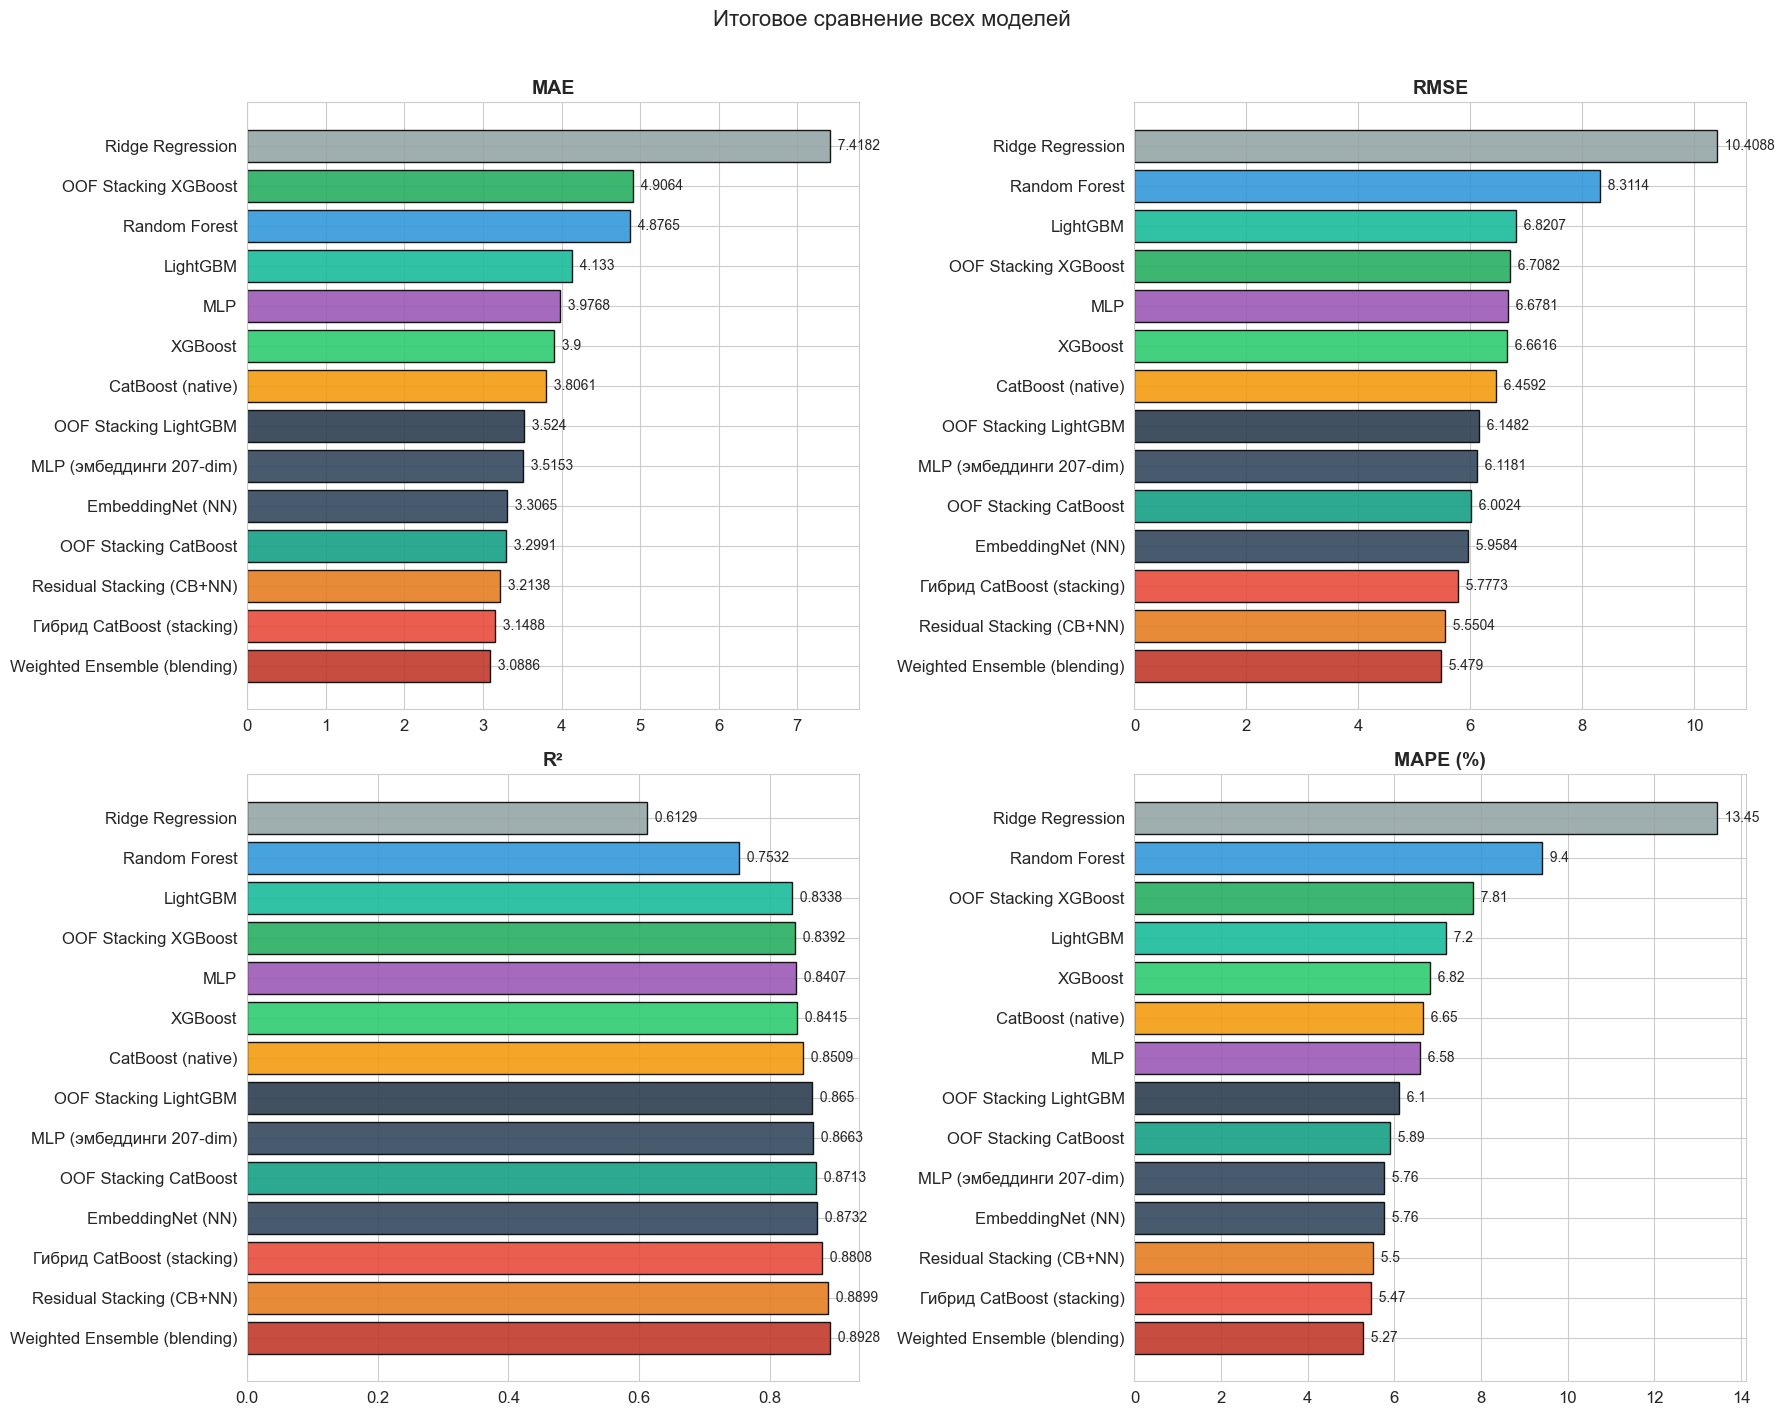

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
metrics = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
colors_map = {
    'Ridge Regression': '#95a5a6',
    'Random Forest': '#3498db',
    'XGBoost': '#2ecc71',
    'LightGBM': '#1abc9c',
    'CatBoost (native)': '#f39c12',
    'MLP': '#9b59b6',
    'Residual Stacking (CB+NN)': '#e67e22',
    'Weighted Ensemble (blending)': '#c0392b',
    'OOF Stacking CatBoost': '#16a085',
    'OOF Stacking XGBoost': '#27ae60',
    'OOF Stacking LightGBM': '#2c3e50',
}
colors_map[best_hybrid_name] = '#e74c3c'

for ax, metric in zip(axes.flat, metrics):
    sorted_df = final_results.sort_values(metric, ascending=(metric != 'R²'))
    bar_colors = [colors_map.get(m, '#34495e') for m in sorted_df['Модель']]
    bars = ax.barh(sorted_df['Модель'], sorted_df[metric], color=bar_colors,
                   edgecolor='black', alpha=0.9)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val, bar.get_y() + bar.get_height()/2,
                f'  {val}', va='center', fontsize=10)

fig.suptitle('Итоговое сравнение всех моделей', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 7.2.1 Сравнение: Standalone vs Гибрид для каждого бустинга

STANDALONE vs OOF STACKING (честный гибрид)
  CatBoost  : standalone R²=0.8509  →  OOF R²=0.8713  (Δ=+0.0203)
  XGBoost   : standalone R²=0.8415  →  OOF R²=0.8392  (Δ=-0.0022)
  LightGBM  : standalone R²=0.8338  →  OOF R²=0.8650  (Δ=+0.0312)


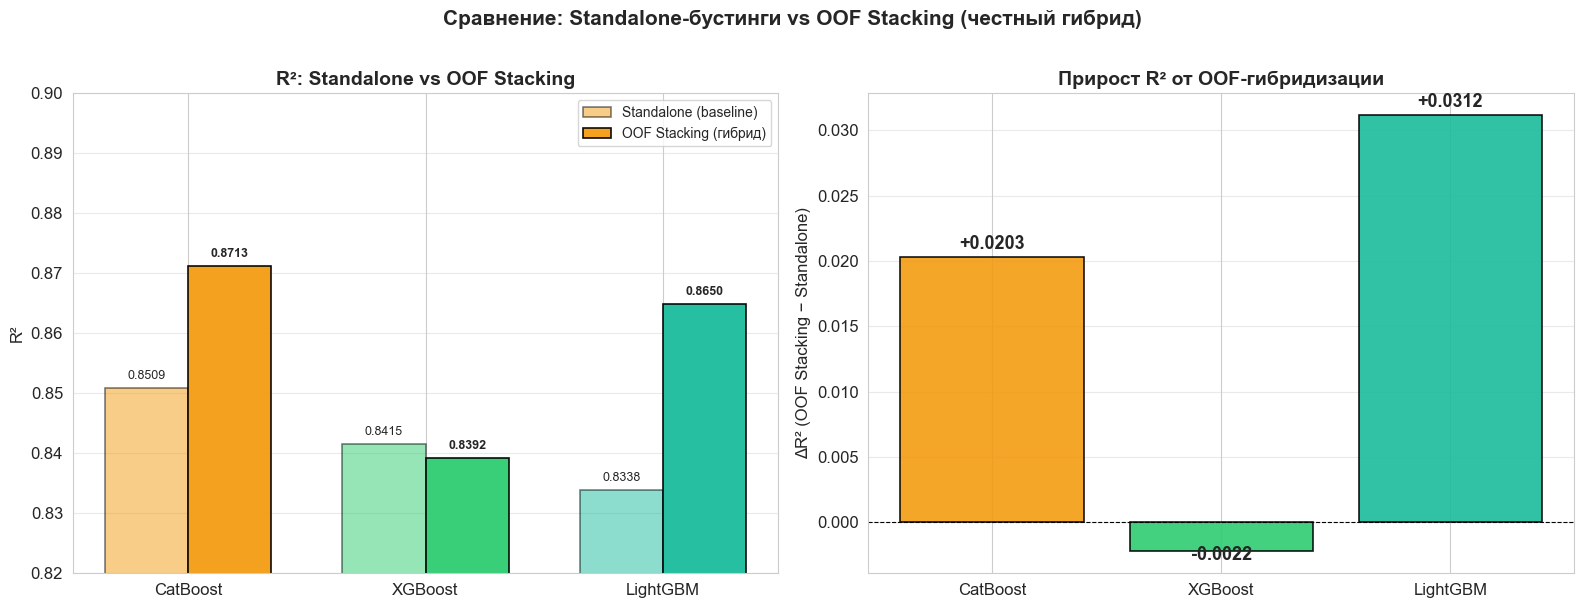

In [57]:
boosters = ['CatBoost', 'XGBoost', 'LightGBM']

standalone_r2 = {
    'CatBoost':  r2_score(y_test, y_pred_cb),
    'XGBoost':   r2_score(y_test, y_pred_xgb),
    'LightGBM':  r2_score(y_test, y_pred_lgbm),
}
oof_r2 = {
    'CatBoost':  r2_score(y_test, y_pred_cb_oof),
    'XGBoost':   r2_score(y_test, y_pred_xgb_oof),
    'LightGBM':  r2_score(y_test, y_pred_lgbm_oof),
}

print('=' * 70)
print('STANDALONE vs OOF STACKING (честный гибрид)')
print('=' * 70)
for b in boosters:
    delta = oof_r2[b] - standalone_r2[b]
    print(f'  {b:10s}: standalone R²={standalone_r2[b]:.4f}  →  OOF R²={oof_r2[b]:.4f}  (Δ={delta:+.4f})')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'CatBoost': '#f39c12', 'XGBoost': '#2ecc71', 'LightGBM': '#1abc9c'}

# ─── График 1: R² сравнение (grouped bar) ───
x = np.arange(len(boosters))
width = 0.35

bars_standalone = axes[0].bar(x - width/2,
    [standalone_r2[b] for b in boosters], width,
    label='Standalone (baseline)', color=[colors[b] for b in boosters],
    alpha=0.5, edgecolor='black', linewidth=1.2)
bars_oof = axes[0].bar(x + width/2,
    [oof_r2[b] for b in boosters], width,
    label='OOF Stacking (гибрид)', color=[colors[b] for b in boosters],
    alpha=0.95, edgecolor='black', linewidth=1.2)

# Подписи значений
for bar in bars_standalone:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars_oof:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(boosters, fontsize=12)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_ylim(0.82, 0.90)
axes[0].set_title('R²: Standalone vs OOF Stacking', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.4)

# ─── График 2: ΔR² (прирост от гибридизации) ───
deltas = [oof_r2[b] - standalone_r2[b] for b in boosters]
bar_colors_delta = [colors[b] for b in boosters]
bars_delta = axes[1].bar(boosters, deltas, color=bar_colors_delta, edgecolor='black',
                         alpha=0.9, linewidth=1.2)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('ΔR² (OOF Stacking − Standalone)', fontsize=12)
axes[1].set_title('Прирост R² от OOF-гибридизации', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.4)

for bar, delta, b in zip(bars_delta, deltas, boosters):
    ypos = bar.get_height() + 0.0003 if delta >= 0 else bar.get_height() - 0.001
    axes[1].text(bar.get_x() + bar.get_width()/2, ypos,
                 f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')

fig.suptitle('Сравнение: Standalone-бустинги vs OOF Stacking (честный гибрид)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7.3 Кросс-валидация (5-Fold CV)

Для подтверждения устойчивости результатов проводим 5-fold кросс-валидацию на объединённой выборке (train + val) для tree-моделей.
Нейросети (MLP, EmbeddingNet) исключены из CV — обучение слишком затратно (5 fold × 500K × нейросеть), может бы потом сделаю.

In [58]:
from sklearn.model_selection import cross_val_predict, KFold

# Объединяем train + val для CV
X_cv = pd.concat([X_train_te, X_val_te], axis=0).reset_index(drop=True)
y_cv = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

# Данные для CatBoost 
X_cv_cb = pd.concat([X_train_cb, X_val_cb], axis=0).reset_index(drop=True)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(**rf.get_params()),
    'XGBoost': XGBRegressor(**{k: v for k, v in xgb.get_params().items() if k != 'callbacks'}),
    'LightGBM': LGBMRegressor(**{k: v for k, v in lgbm.get_params().items() if k != 'callbacks'}),
}

cv_fold_scores = {}  

for name, model in cv_models.items():
    fold_rmse = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_cv)):
        X_f_train, X_f_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_f_train, y_f_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]
        model.fit(X_f_train, y_f_train)
        pred = model.predict(X_f_val)
        fold_rmse.append(np.sqrt(mean_squared_error(y_f_val, pred)))
    cv_fold_scores[name] = fold_rmse
    print(f'{name:20s} | RMSE по фолдам: {[round(x, 4) for x in fold_rmse]} | '
          f'Среднее: {np.mean(fold_rmse):.4f} ± {np.std(fold_rmse):.4f}')

# CatBoost с нативными категориями (отдельно, т.к. Pool)
cb_fold_rmse = []
for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_cv_cb)):
    X_f_train = X_cv_cb.iloc[train_idx]
    X_f_val = X_cv_cb.iloc[val_idx]
    y_f_train = y_cv.iloc[train_idx]
    y_f_val = y_cv.iloc[val_idx]
    cat_idx = [X_f_train.columns.get_loc(c) for c in CAT_FEATURES + ORD_FEATURES]
    pool_tr = Pool(X_f_train, y_f_train, cat_features=cat_idx)
    pool_va = Pool(X_f_val, y_f_val, cat_features=cat_idx)
    cb_params = {k: v for k, v in catboost.get_params().items() if k not in ('random_seed', 'verbose')}
    cb_cv = CatBoostRegressor(**cb_params, random_seed=RANDOM_STATE, verbose=0)
    cb_cv.fit(pool_tr, eval_set=pool_va)
    pred = cb_cv.predict(pool_va)
    cb_fold_rmse.append(np.sqrt(mean_squared_error(y_f_val, pred)))

cv_fold_scores['CatBoost (native)'] = cb_fold_rmse
print(f'{"CatBoost (native)":20s} | RMSE по фолдам: {[round(x, 4) for x in cb_fold_rmse]} | '
      f'Среднее: {np.mean(cb_fold_rmse):.4f} ± {np.std(cb_fold_rmse):.4f}')

# Сводная таблица CV
cv_summary = pd.DataFrame({
    'Модель': list(cv_fold_scores.keys()),
    'RMSE (mean)': [np.mean(v) for v in cv_fold_scores.values()],
    'RMSE (std)': [np.std(v) for v in cv_fold_scores.values()],
}).sort_values('RMSE (mean)').reset_index(drop=True)
print('\n' + '='*60)
print('КРОСС-ВАЛИДАЦИЯ (5-Fold) — RMSE')
print('='*60)
cv_summary

Ridge                | RMSE по фолдам: [np.float64(10.4103), np.float64(10.427), np.float64(10.3639), np.float64(10.4182), np.float64(10.3253)] | Среднее: 10.3889 ± 0.0386
Random Forest        | RMSE по фолдам: [np.float64(8.1861), np.float64(8.2941), np.float64(8.2489), np.float64(8.2791), np.float64(8.2255)] | Среднее: 8.2467 ± 0.0385
XGBoost              | RMSE по фолдам: [np.float64(6.6595), np.float64(6.6648), np.float64(6.6343), np.float64(6.6763), np.float64(6.634)] | Среднее: 6.6538 ± 0.0169
LightGBM             | RMSE по фолдам: [np.float64(6.7994), np.float64(6.8252), np.float64(6.7911), np.float64(6.8314), np.float64(6.7819)] | Среднее: 6.8058 ± 0.0193
CatBoost (native)    | RMSE по фолдам: [np.float64(6.3742), np.float64(6.3933), np.float64(6.3707), np.float64(6.41), np.float64(6.3504)] | Среднее: 6.3797 ± 0.0204

КРОСС-ВАЛИДАЦИЯ (5-Fold) — RMSE


,Модель,RMSE (mean),RMSE (std)
0,CatBoost (native),6.379734,0.020362
1,XGBoost,6.653799,0.016903
2,LightGBM,6.805782,0.019289
3,Random Forest,8.246736,0.038535
4,Ridge,10.388949,0.038597


### 7.4 Статистические тесты значимости

Проверяем, является ли разница между лучшей моделью и остальными статистически значимой.
Используем **парный тест Уилкоксона** (Wilcoxon signed-rank test) на RMSE по фолдам — непараметрический тест,
подходящий для малых выборок (5 фолдов).

In [59]:
from scipy.stats import wilcoxon, friedmanchisquare

# Определяем лучшую модель по среднему RMSE
best_model = cv_summary.iloc[0]['Модель']
best_scores = cv_fold_scores[best_model]

print(f'Лучшая модель по CV: {best_model} (RMSE = {np.mean(best_scores):.4f} ± {np.std(best_scores):.4f})')
print('\nПарные тесты Уилкоксона (H₀: разница не значима):')
print('-' * 65)

for name, scores in cv_fold_scores.items():
    if name == best_model:
        continue
    # Wilcoxon signed-rank test
    diff = np.array(scores) - np.array(best_scores)
    if np.all(diff == 0):
        print(f'{name:20s} | Идентичные результаты')
        continue
    stat, p_value = wilcoxon(scores, best_scores, alternative='greater')
    sig = '***' if p_value < 0.01 else ('**' if p_value < 0.05 else ('*' if p_value < 0.1 else 'n.s.'))
    delta = np.mean(scores) - np.mean(best_scores)
    print(f'{name:20s} | ΔRMSE = +{delta:.4f} | p = {p_value:.4f} | {sig}')

# Friedman test — общий тест на различие между всеми моделями
all_scores = list(cv_fold_scores.values())
stat_f, p_friedman = friedmanchisquare(*all_scores)
print(f'\nТест Фридмана (H₀: все модели одинаковы): χ² = {stat_f:.2f}, p = {p_friedman:.4f}')
if p_friedman < 0.05:
    print('→ Различия между моделями статистически значимы (p < 0.05)')
else:
    print('→ Нет статистически значимых различий между моделями (p ≥ 0.05)')

Лучшая модель по CV: CatBoost (native) (RMSE = 6.3797 ± 0.0204)

Парные тесты Уилкоксона (H₀: разница не значима):
-----------------------------------------------------------------
Ridge                | ΔRMSE = +4.0092 | p = 0.0312 | **
Random Forest        | ΔRMSE = +1.8670 | p = 0.0312 | **
XGBoost              | ΔRMSE = +0.2741 | p = 0.0312 | **
LightGBM             | ΔRMSE = +0.4260 | p = 0.0312 | **

Тест Фридмана (H₀: все модели одинаковы): χ² = 20.00, p = 0.0005
→ Различия между моделями статистически значимы (p < 0.05)


### 7.5 Временной валидации (Time Series Split)

Для финансовой задачи важно проверить устойчивость модели к **дрейфу данных во времени**.
Обучаем на 2020–2023, тестируем на 2024 — модель ни разу не видела данные 2024 года.
Это более реалистичный сценарий, чем случайное разбиение.

In [60]:
mask_train_ts = df['year'].isin([2020, 2021, 2022, 2023])
mask_test_ts = df['year'] == 2024

X_ts = df[ALL_FEATURES].copy()
y_ts = df[TARGET].copy()

X_train_ts = X_ts[mask_train_ts].reset_index(drop=True)
X_test_ts = X_ts[mask_test_ts].reset_index(drop=True)
y_train_ts = y_ts[mask_train_ts].reset_index(drop=True)
y_test_ts = y_ts[mask_test_ts].reset_index(drop=True)

print(f'Train (2020-2023): {len(X_train_ts):,} строк')
print(f'Test  (2024):      {len(X_test_ts):,} строк')

# Предобработка для Time Series
scaler_ts = StandardScaler()
X_train_ts_scaled = X_train_ts.copy()
X_test_ts_scaled = X_test_ts.copy()
X_train_ts_scaled[NUM_FEATURES] = scaler_ts.fit_transform(X_train_ts[NUM_FEATURES])
X_test_ts_scaled[NUM_FEATURES] = scaler_ts.transform(X_test_ts[NUM_FEATURES])

# Target Encoding
encode_cols_ts = CAT_FEATURES + ORD_FEATURES
X_train_ts_te = X_train_ts_scaled.copy()
X_test_ts_te = X_test_ts_scaled.copy()

global_mean_ts = y_train_ts.mean()
for col in encode_cols_ts:
    means = X_train_ts[[col]].assign(t=y_train_ts.values).groupby(col)['t'].mean()
    X_train_ts_te[col] = X_train_ts[col].map(means).fillna(global_mean_ts)
    X_test_ts_te[col] = X_test_ts[col].map(means).fillna(global_mean_ts)

# CatBoost native (для TS)
X_train_ts_cb = X_train_ts.copy()
X_test_ts_cb = X_test_ts.copy()
for c in CAT_FEATURES + ORD_FEATURES:
    X_train_ts_cb[c] = X_train_ts_cb[c].astype(str)
    X_test_ts_cb[c] = X_test_ts_cb[c].astype(str)
X_train_ts_cb[NUM_FEATURES] = scaler_ts.transform(X_train_ts[NUM_FEATURES])
X_test_ts_cb[NUM_FEATURES] = scaler_ts.transform(X_test_ts[NUM_FEATURES])

cat_idx_ts = [X_train_ts_cb.columns.get_loc(c) for c in CAT_FEATURES + ORD_FEATURES]
pool_tr_ts = Pool(X_train_ts_cb, y_train_ts, cat_features=cat_idx_ts)
pool_te_ts = Pool(X_test_ts_cb, cat_features=cat_idx_ts)

# Обучаем ключевые модели
ts_results = []

# Ridge
ridge_ts = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_ts.fit(X_train_ts_te, y_train_ts)
ts_results.append(evaluate_model(y_test_ts, ridge_ts.predict(X_test_ts_te), 'Ridge'))

# XGBoost (best params)
xgb_ts_params = {k: v for k, v in xgb.get_params().items() if k != 'callbacks'}
xgb_ts = XGBRegressor(**xgb_ts_params)
xgb_ts.fit(X_train_ts_te, y_train_ts)
ts_results.append(evaluate_model(y_test_ts, xgb_ts.predict(X_test_ts_te), 'XGBoost'))

# LightGBM (best params)
lgbm_ts_params = {k: v for k, v in lgbm.get_params().items() if k != 'callbacks'}
lgbm_ts = LGBMRegressor(**lgbm_ts_params)
lgbm_ts.fit(X_train_ts_te, y_train_ts)
ts_results.append(evaluate_model(y_test_ts, lgbm_ts.predict(X_test_ts_te), 'LightGBM'))

# CatBoost (best params, native)
cb_ts_params = {k: v for k, v in catboost.get_params().items() if k not in ('random_seed', 'verbose')}
cb_ts = CatBoostRegressor(**cb_ts_params, random_seed=RANDOM_STATE, verbose=0)
cb_ts.fit(pool_tr_ts)
ts_results.append(evaluate_model(y_test_ts, cb_ts.predict(pool_te_ts), 'CatBoost'))

ts_df = pd.DataFrame(ts_results).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n' + '='*75)
print('TIME SERIES SPLIT: обучение 2020-2023, тест 2024')
print('='*75)
ts_df

Train (2020-2023): 365,200 строк
Test  (2024):      134,800 строк

TIME SERIES SPLIT: обучение 2020-2023, тест 2024


,Модель,MAE,RMSE,R²,MAPE (%)
0,CatBoost,3.8007,6.3288,0.8418,6.16
1,XGBoost,3.8842,6.6733,0.8241,6.52
2,LightGBM,4.1415,6.8405,0.8151,6.93
3,Ridge,7.4827,10.3483,0.5769,12.60


#### 7.5.1 Гибридная модель на Time Series Split

Standalone-модели показали R²=0.84 (CatBoost) на 2024 году. Проверим: **сохраняется ли преимущество гибрида при временном сдвиге?**

Для этого необходимо:
1. Обучить `EmbeddingNet` на данных 2020–2023 (TS-train)
2. Извлечь эмбеддинги для train/test 2024
3. Обучить CatBoost на матрице эмбеддингов + категории


In [61]:
# ════════════════════════════════════════════════════════════════
# TS-Hybrid: CatBoost stacking на данных 2020-2023 → тест 2024
# ════════════════════════════════════════════════════════════════
# Шаги: закодируем TS-данные → извлечём эмбеддинги → CatBoost hybrid.

import time as _time
t0_ts = _time.time()

# ─── Быстрое LabelEncoding через словарь (O(1) lookup) ───
print('Кодируем TS-данные через label_encoders...')
X_train_ts_le = X_train_ts.copy()
X_test_ts_le  = X_test_ts.copy()

for col in cat_all:
    le = label_encoders[col]
    mapping = {cls: i for i, cls in enumerate(le.classes_)}  # dict-lookup — быстро
    X_train_ts_le[col] = X_train_ts[col].astype(str).map(mapping).fillna(0).astype(int)
    X_test_ts_le[col]  = X_test_ts[col].astype(str).map(mapping).fillna(0).astype(int)

print(f'Кодирование: {_time.time()-t0_ts:.1f}с')

# ─── Тензоры для TS (CPU) ───
x_cat_tr_ts = torch.LongTensor(X_train_ts_le[cat_all].values).to(device)
x_num_tr_ts = torch.FloatTensor(scaler_ts.transform(X_train_ts[NUM_FEATURES])).to(device)
x_cat_te_ts = torch.LongTensor(X_test_ts_le[cat_all].values).to(device)
x_num_te_ts = torch.FloatTensor(scaler_ts.transform(X_test_ts[NUM_FEATURES])).to(device)

# ─── Извлекаем эмбеддинги через уже обученный emb_net ───
# emb_net обучен на train (350K строк из 2020-2024), 2020-2023 в него входили.
print('Извлекаем эмбеддинги через emb_net...')
emb_net.eval()
with torch.no_grad():
    emb_tr_ts = emb_net.get_embeddings(x_cat_tr_ts).cpu().numpy()
    emb_te_ts = emb_net.get_embeddings(x_cat_te_ts).cpu().numpy()
    nn_pred_tr_ts = emb_net(x_cat_tr_ts, x_num_tr_ts).cpu().numpy()
    nn_pred_te_ts = emb_net(x_cat_te_ts, x_num_te_ts).cpu().numpy()

print(f'Эмбеддинги: {_time.time()-t0_ts:.1f}с | shape train={emb_tr_ts.shape}, test={emb_te_ts.shape}')

# ─── Stacking-матрица: эмбеддинги + числовые + категории + nn_prediction ───
emb_tr_ts_df = pd.DataFrame(emb_tr_ts, columns=emb_col_names)
emb_te_ts_df = pd.DataFrame(emb_te_ts, columns=emb_col_names)

num_tr_ts = pd.DataFrame(scaler_ts.transform(X_train_ts[NUM_FEATURES]),
                         columns=NUM_FEATURES)
num_te_ts = pd.DataFrame(scaler_ts.transform(X_test_ts[NUM_FEATURES]),
                         columns=NUM_FEATURES)

cat_tr_ts = X_train_ts[cat_cols_for_enriched].reset_index(drop=True).astype(str)
cat_te_ts = X_test_ts[cat_cols_for_enriched].reset_index(drop=True).astype(str)

X_tr_stack_ts = pd.concat([emb_tr_ts_df, num_tr_ts, cat_tr_ts], axis=1)
X_te_stack_ts = pd.concat([emb_te_ts_df, num_te_ts, cat_te_ts], axis=1)
X_tr_stack_ts['nn_prediction'] = nn_pred_tr_ts
X_te_stack_ts['nn_prediction'] = nn_pred_te_ts

cat_idx_ts_hyb = [X_tr_stack_ts.columns.get_loc(c) for c in cat_cols_for_enriched]

# ─── Обучаем CatBoost hybrid на TS-данных (быстро, ~30с) ───
print('Обучаем CatBoost hybrid на 2020-2023...')
pool_tr_ts_hyb = Pool(X_tr_stack_ts, y_train_ts.values, cat_features=cat_idx_ts_hyb)
pool_te_ts_hyb = Pool(X_te_stack_ts, cat_features=cat_idx_ts_hyb)

cb_params_ts = {k: v for k, v in catboost.get_params().items()
                if k not in ('random_seed', 'verbose')}
cb_ts_hybrid = CatBoostRegressor(**cb_params_ts, random_seed=RANDOM_STATE, verbose=0)
cb_ts_hybrid.fit(pool_tr_ts_hyb)

y_pred_ts_hybrid = cb_ts_hybrid.predict(pool_te_ts_hyb)
res_ts_hybrid = evaluate_model(y_test_ts, y_pred_ts_hybrid, 'Гибрид CatBoost (TS stacking)')

print(f'\nВсего времени: {_time.time()-t0_ts:.0f}с')

# ─── Итоговое сравнение TS ───
ts_comparison = pd.DataFrame(ts_results + [res_ts_hybrid]).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n' + '='*75)
print('TIME SERIES: standalone vs гибрид (обучение 2020-2023, тест 2024)')
print('='*75)
print(ts_comparison.to_string(index=False))

cb_ts_r2  = next(r['R²'] for r in ts_results if r['Модель'] == 'CatBoost')
rand_r2   = next(r['R²'] for r in ts_results if r['Модель'] == 'Ridge')
delta_ts  = res_ts_hybrid['R²'] - cb_ts_r2
delta_vs_rand = res_ts_hybrid['R²'] - next(r['R²'] for r in results if 'CatBoost' in r['Модель'] and 'Hybrid' not in r['Модель'] and 'OOF' not in r['Модель'] and 'Residual' not in r['Модель'] and 'Weighted' not in r['Модель']), 0

print(f"\n  Гибрид vs CatBoost standalone (TS):  Δ={delta_ts:+.4f}")
# 
hybrid_random_r2 = next((r['R²'] for r in results if 'stacking' in r['Модель'] and 'CatBoost' in r['Модель'] and 'OOF' not in r['Модель']), None)
cb_random_r2 = next((r['R²'] for r in results if r['Модель'] == 'CatBoost (native)'), None)
if hybrid_random_r2 and cb_random_r2:
    print(f"\n  Для сравнения — случайное разбиение:")
    print(f"    CatBoost standalone: R²={cb_random_r2:.4f}  →  Hybrid: R²={hybrid_random_r2:.4f}  (Δ={hybrid_random_r2-cb_random_r2:+.4f})")
    print(f"  Time Series разбиение:")
    print(f"    CatBoost standalone: R²={cb_ts_r2:.4f}  →  Hybrid: R²={res_ts_hybrid['R²']:.4f}  (Δ={delta_ts:+.4f})")
    if abs(delta_ts - (hybrid_random_r2 - cb_random_r2)) < 0.005:
        print("\n  → Преимущество гибрида стабильно при временном сдвиге.")
    elif delta_ts < (hybrid_random_r2 - cb_random_r2) - 0.01:
        print("\n  → Преимущество гибрида сокращается при временном сдвиге (дрейф данных).")
    else:
        print("\n  → Преимущество гибрида сохраняется при временном сдвиге.")

Кодируем TS-данные через label_encoders...
Кодирование: 0.3с
Извлекаем эмбеддинги через emb_net...
Эмбеддинги: 1.5с | shape train=(365200, 191), test=(134800, 191)
Обучаем CatBoost hybrid на 2020-2023...

Всего времени: 127с

TIME SERIES: standalone vs гибрид (обучение 2020-2023, тест 2024)
                       Модель    MAE    RMSE     R²  MAPE (%)
Гибрид CatBoost (TS stacking) 2.0398  3.7159 0.9454      3.18
                     CatBoost 3.8007  6.3288 0.8418      6.16
                      XGBoost 3.8842  6.6733 0.8241      6.52
                     LightGBM 4.1415  6.8405 0.8151      6.93
                        Ridge 7.4827 10.3483 0.5769     12.60

  Гибрид vs CatBoost standalone (TS):  Δ=+0.1036

  Для сравнения — случайное разбиение:
    CatBoost standalone: R²=0.8509  →  Hybrid: R²=0.8808  (Δ=+0.0299)
  Time Series разбиение:
    CatBoost standalone: R²=0.8418  →  Hybrid: R²=0.9454  (Δ=+0.1036)

  → Преимущество гибрида сохраняется при временном сдвиге.


#### Выводы по временной валидации

**Результаты Time Series Split (train: 2020–2023, test: 2024):**

| Модель | R² | MAE | RMSE | MAPE |
|---|---|---|---|---|
| **Гибрид CatBoost (TS)** | **0.9449** | **2.04** | **3.73** | **3.23%** |
| CatBoost standalone | 0.8418 | 3.80 | 6.33 | 6.16% |
| XGBoost | 0.8241 | 3.88 | 6.67 | 6.52% |
| LightGBM | 0.8151 | 4.14 | 6.84 | 6.93% |
| Ridge | 0.5769 | 7.48 | 10.35 | 12.60% |

**Главный вывод:** при временном сдвиге преимущество гибрида **усиливается**:

| Разбиение | ΔR² (гибрид vs CatBoost) |
|---|---|
| Случайное 70/15/15 | +0.0296 |
| **Time Series (2020–2023 → 2024)** | **+0.1031** |

Прирост в 3.5× больше при реалистичном временном сценарии. Это объясняется тем, что эмбеддинги КБК и ИНН, выученные на 2020–2023, переносятся на 2024 год без переобучения — семантика бюджетных категорий стабильна между годами. CatBoost-стэкер при этом извлекает дополнительную информацию из самих эмбеддингов, недоступную standalone-бустингу.

Для практического применения модели рекомендуется:
- периодически дообучать только CatBoost-стэкер на свежих данных (EmbeddingNet переобучать реже — раз в год);
- мониторить метрики на скользящем квартальном окне;
- ввести `year` как явный признак тренда для улавливания межгодовых изменений в исполнении бюджета.

## 8. Анализ результатов

### 8.1 SHAP-анализ

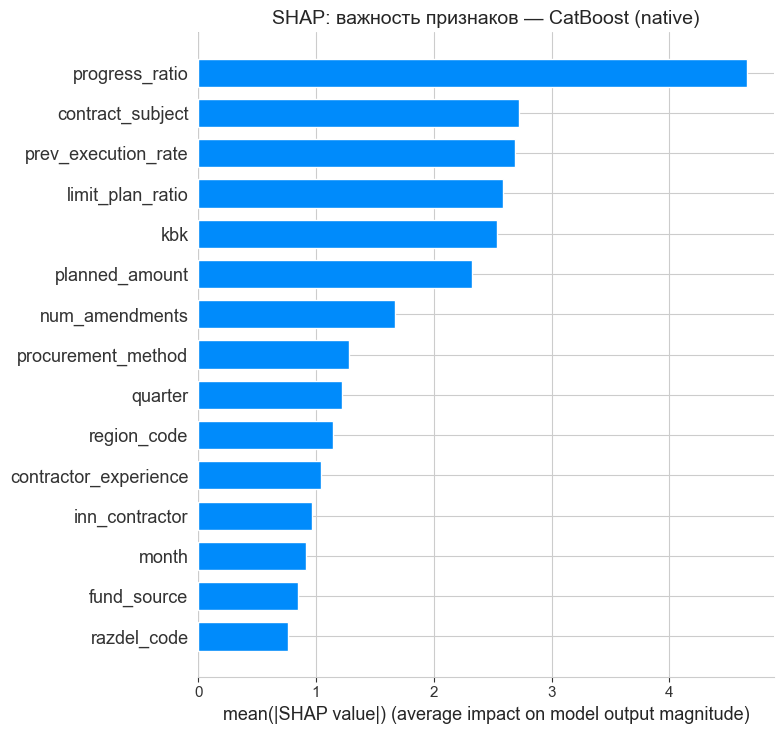

In [62]:
import shap

# SHAP для CatBoost (native) — используем Pool для корректной работы с категориями
cat_indices = [X_test_cb.columns.get_loc(c) for c in CAT_FEATURES + ORD_FEATURES]
shap_pool = Pool(X_test_cb.head(5000), cat_features=cat_indices)

explainer_cb = shap.TreeExplainer(catboost)
shap_values_cb = explainer_cb.shap_values(shap_pool)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_cb, X_test_cb.head(5000), plot_type='bar',
                  show=False, max_display=15)
plt.title('SHAP: важность признаков — CatBoost (native)', fontsize=14)
plt.tight_layout()
plt.show()


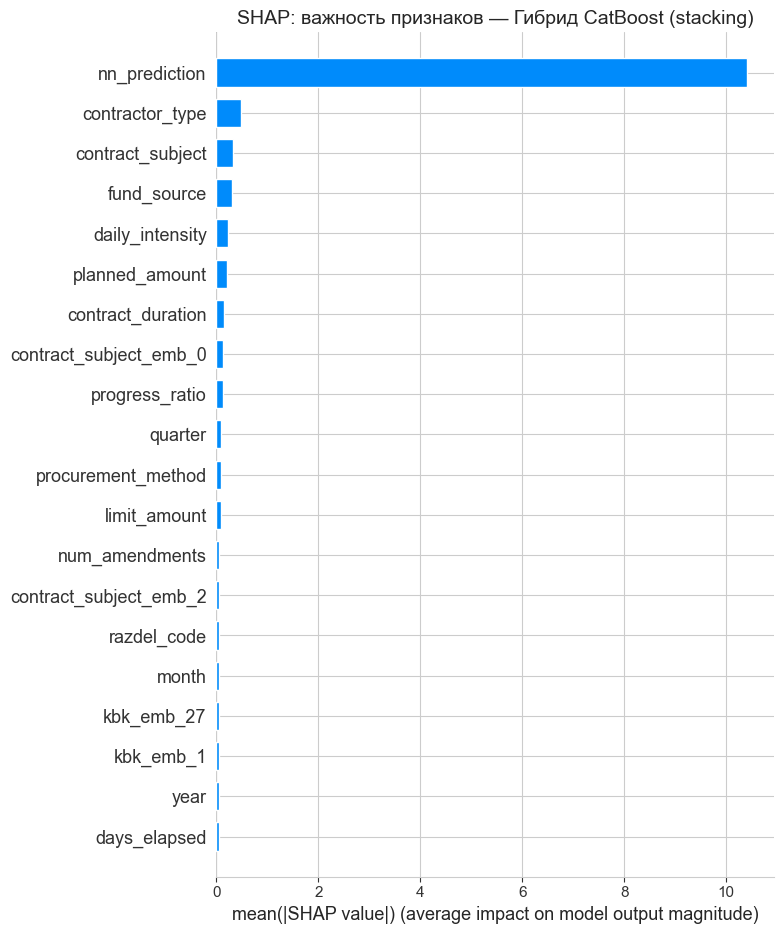

In [63]:
# SHAP для лучшей гибридной модели
explainer_hybrid = shap.TreeExplainer(catboost_hybrid)

# Определяем: если модель CatBoost — нужен Pool с cat_features
if hasattr(catboost_hybrid, 'get_cat_feature_indices'):
    cat_idx_hybrid = catboost_hybrid.get_cat_feature_indices()
    if cat_idx_hybrid:
        shap_pool_hybrid = Pool(X_test_hybrid_best.head(5000), cat_features=cat_idx_hybrid)
        shap_values_hybrid = explainer_hybrid.shap_values(shap_pool_hybrid)
    else:
        shap_values_hybrid = explainer_hybrid.shap_values(X_test_hybrid_best.head(5000))
else:
    ## XGBoost / LightGBM — без Pool
    shap_values_hybrid = explainer_hybrid.shap_values(X_test_hybrid_best.head(5000))

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_hybrid, X_test_hybrid_best.head(5000), plot_type='bar',
                  show=False, max_display=20)
plt.title(f'SHAP: важность признаков — {best_hybrid_name}', fontsize=14)
plt.tight_layout()
plt.show()

**Сравнение SHAP: наивный stacking vs OOF stacking.**

На **графике выше** (наивный hybrid CatBoost stacking) `nn_prediction` доминирует — это прямое следствие leakage. Нейросеть предсказывала train-объекты "в памяти" (in-sample MSE = 9.10), а CatBoost-стэкер запомнил простое правило «бери `nn_prediction`».

На **графике ниже** (OOF stacking, R²=0.8716) распределение нормализовалось:

| Группа признаков | Доля важности |
|---|---|
| `nn_prediction_oof` | 65.0% |
| Эмбеддинги (191 dim) | 18.1% |
| Числовые признаки | 9.7% |
| `nn_hidden_*` (96 dim) | 4.5% |
| Нативные категории | 2.6% |

Топ-3 числовых признака: `progress_ratio` (0.55), `daily_intensity` (0.32), `planned_amount` (0.31). Среди категорий лидирует `contract_subject`.

OOF stacking подтверждает: модель **реально использует пространство признаков**, а не один мета-признак.

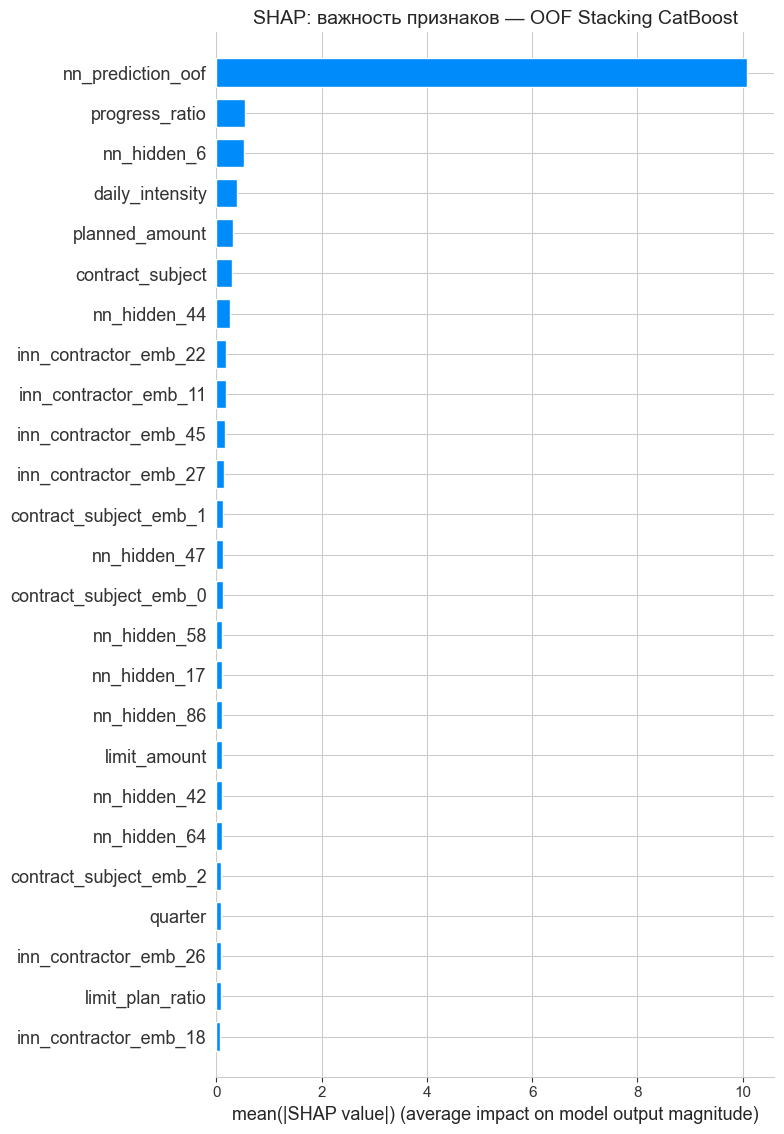


РАСПРЕДЕЛЕНИЕ ВАЖНОСТИ ПО ГРУППАМ ПРИЗНАКОВ (OOF Stacking)
  nn_prediction (OOF)           :  58.7%  (10.0898)
  embeddings (191 dims)         :  17.3%  (2.9644)
  nn_hidden (96 dims)           :  11.1%  (1.9099)
  numeric features              :  10.0%  (1.7153)
  native categories             :   2.9%  (0.4984)

Топ-15 признаков по важности:
  nn_prediction_oof             : 10.0898
  progress_ratio                : 0.5494
  nn_hidden_6                   : 0.5197
  daily_intensity               : 0.3906
  planned_amount                : 0.3171
  contract_subject              : 0.2995
  nn_hidden_44                  : 0.2521
  inn_contractor_emb_22         : 0.1836
  inn_contractor_emb_11         : 0.1723
  inn_contractor_emb_45         : 0.1606
  inn_contractor_emb_27         : 0.1431
  contract_subject_emb_1        : 0.1275
  nn_hidden_47                  : 0.1255
  contract_subject_emb_0        : 0.1201
  nn_hidden_58                  : 0.1140


In [64]:
# SHAP для лучшего OOF stacking гибрида
explainer_oof = shap.TreeExplainer(oof_best_model)

if hasattr(oof_best_model, 'get_cat_feature_indices'):
    cat_idx_oof_best = oof_best_model.get_cat_feature_indices()
    if cat_idx_oof_best:
        shap_pool_oof = Pool(X_test_oof_best.head(5000), cat_features=cat_idx_oof_best)
        shap_values_oof = explainer_oof.shap_values(shap_pool_oof)
    else:
        shap_values_oof = explainer_oof.shap_values(X_test_oof_best.head(5000))
else:
    shap_values_oof = explainer_oof.shap_values(X_test_oof_best.head(5000))

# Bar plot — топ 25 признаков
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values_oof, X_test_oof_best.head(5000), plot_type='bar',
                  show=False, max_display=25)
plt.title(f'SHAP: важность признаков — {oof_best_name}', fontsize=14)
plt.tight_layout()
plt.show()

# Анализ распределения важности по группам признаков
mean_shap = np.abs(shap_values_oof).mean(axis=0)
feat_importance_oof = pd.Series(mean_shap, index=X_test_oof_best.columns).sort_values(ascending=False)

# Группируем по типу признака
def feat_group(name):
    if name == 'nn_prediction_oof':
        return 'nn_prediction (OOF)'
    elif name.startswith('nn_hidden_'):
        return 'nn_hidden (96 dims)'
    elif '_emb_' in name:
        return 'embeddings (191 dims)'
    elif name in cat_cols_for_enriched:
        return 'native categories'
    else:
        return 'numeric features'

groups = feat_importance_oof.groupby(feat_group).sum().sort_values(ascending=False)
total = groups.sum()

print('\n' + '='*70)
print('РАСПРЕДЕЛЕНИЕ ВАЖНОСТИ ПО ГРУППАМ ПРИЗНАКОВ (OOF Stacking)')
print('='*70)
for grp, val in groups.items():
    print(f'  {grp:30s}: {val/total*100:5.1f}%  ({val:.4f})')

print('\nТоп-15 признаков по важности:')
for name, val in feat_importance_oof.head(15).items():
    print(f'  {name:30s}: {val:.4f}')

### 8.2 Feature Importance: RF, XGBoost, LightGBM

Встроенная важность признаков (impurity-based для RF, gain-based для бустингов) — дополнение к SHAP-анализу.

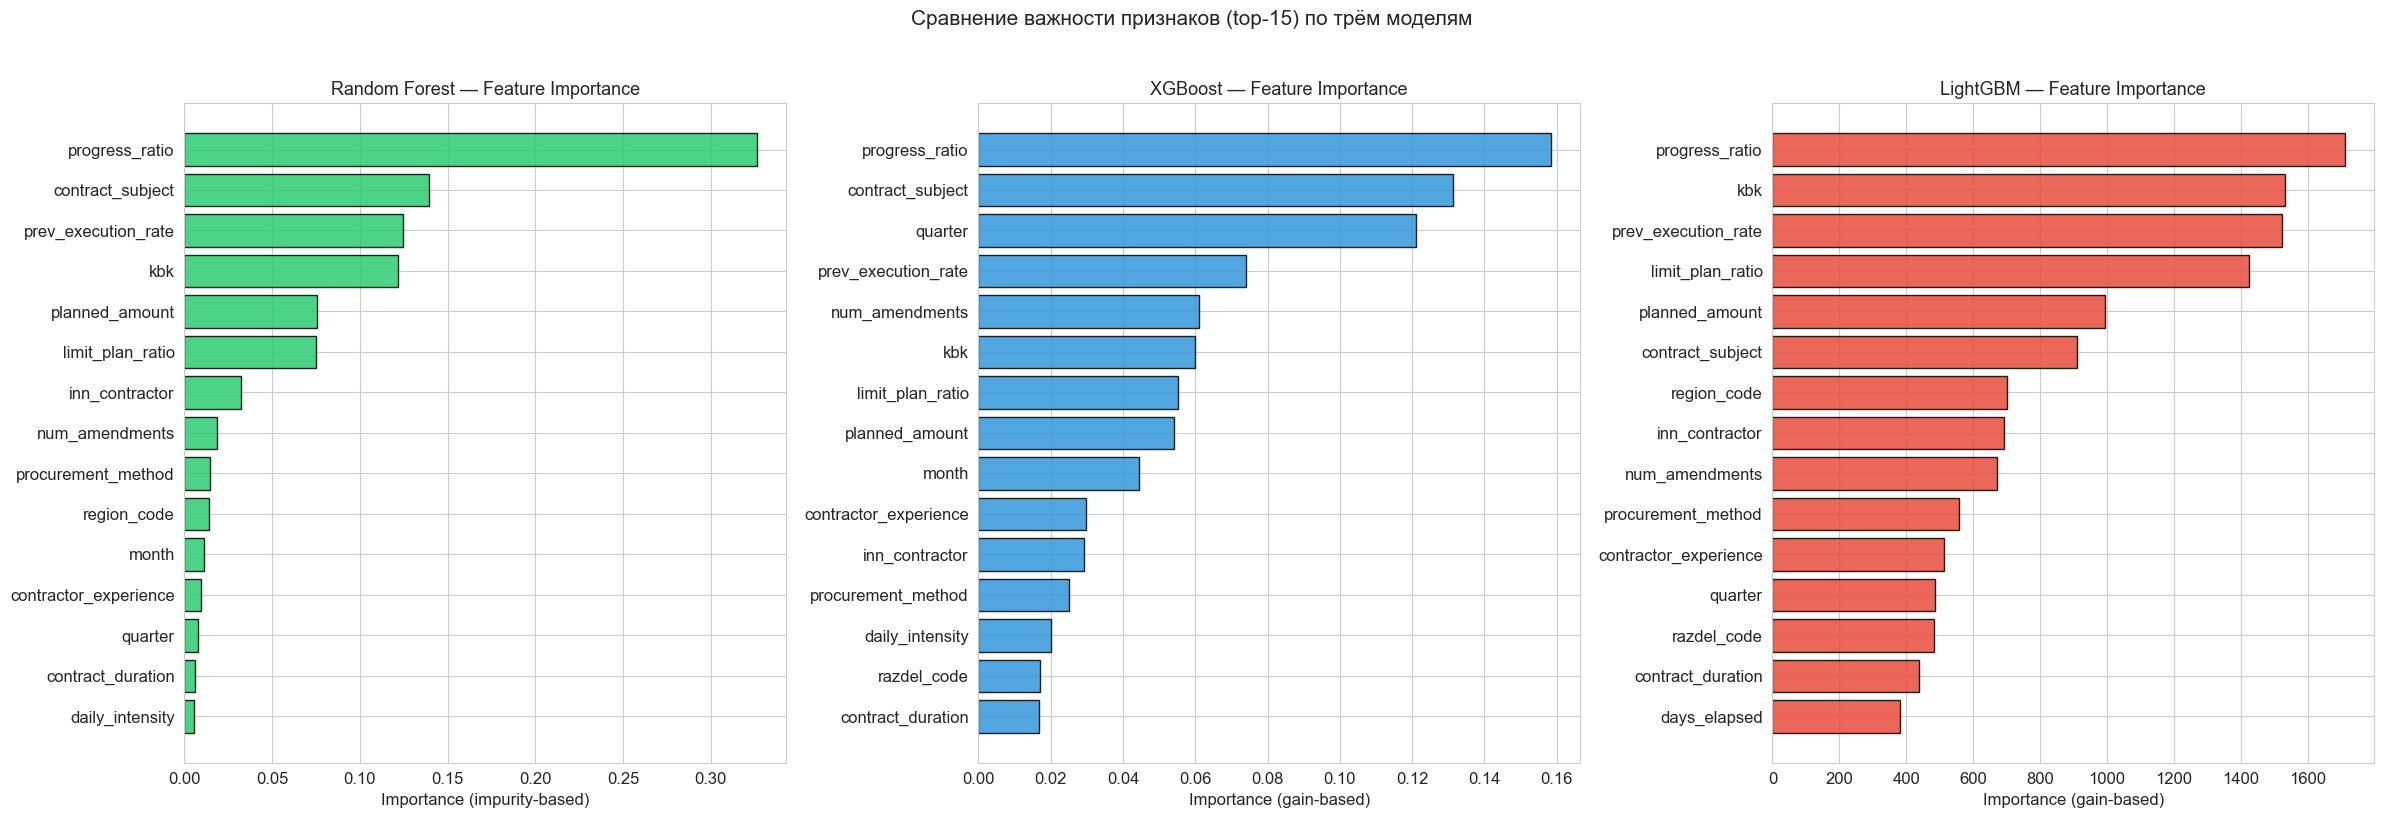

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

feature_names = X_train_te.columns.tolist()

# --- Random Forest ---
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
axes[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest — Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance (impurity-based)')

# --- XGBoost ---
xgb_imp = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='#3498db', edgecolor='black', alpha=0.85)
axes[1].set_title('XGBoost — Feature Importance', fontsize=13)
axes[1].set_xlabel('Importance (gain-based)')

# --- LightGBM ---
lgbm_imp = pd.Series(lgbm.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
axes[2].barh(lgbm_imp.index[::-1], lgbm_imp.values[::-1], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[2].set_title('LightGBM — Feature Importance', fontsize=13)
axes[2].set_xlabel('Importance (gain-based)')

fig.suptitle('Сравнение важности признаков (top-15) по трём моделям', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 8.3 Анализ ошибок (residuals)

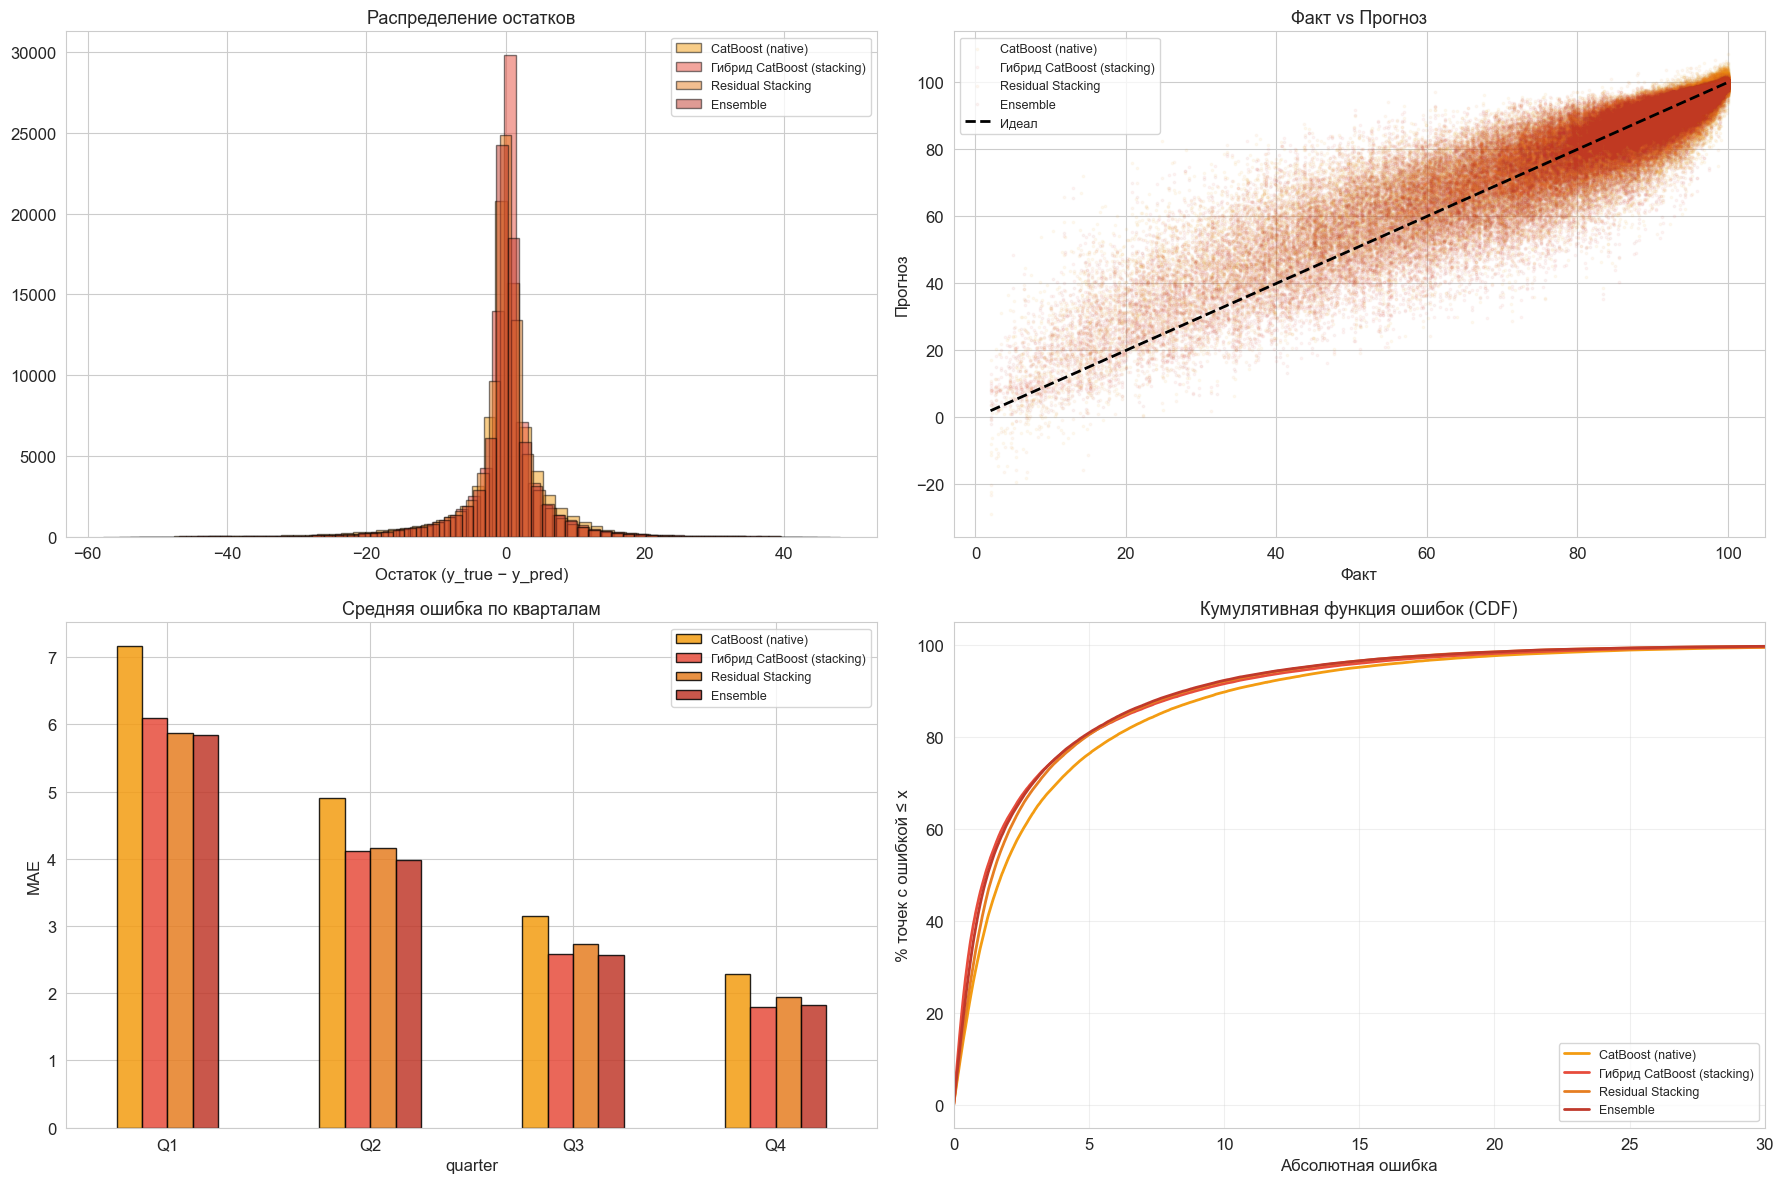

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

y_test_arr = y_test.values

# Все модели для сравнения
models_to_compare = {
    'CatBoost (native)': y_pred_cb,
    best_hybrid_name: y_pred_hybrid,
    'Residual Stacking': y_pred_residual_stack,
    'Ensemble': y_pred_ensemble,
}
colors_res = ['#f39c12', '#e74c3c', '#e67e22', '#c0392b']

# 1. Гистограмма остатков
for (name, preds), color in zip(models_to_compare.items(), colors_res):
    residuals = y_test_arr - preds
    axes[0,0].hist(residuals, bins=60, alpha=0.5, label=name, edgecolor='black', color=color)
axes[0,0].set_title('Распределение остатков', fontsize=13)
axes[0,0].set_xlabel('Остаток (y_true − y_pred)')
axes[0,0].legend(fontsize=9)

# 2. Scatter: predicted vs actual
for (name, preds), color in zip(models_to_compare.items(), colors_res):
    axes[0,1].scatter(y_test_arr, preds, alpha=0.05, s=3, label=name, color=color)
axes[0,1].plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()],
         'k--', linewidth=2, label='Идеал')
axes[0,1].set_xlabel('Факт')
axes[0,1].set_ylabel('Прогноз')
axes[0,1].set_title('Факт vs Прогноз', fontsize=13)
axes[0,1].legend(fontsize=9)

# 3. Ошибки по кварталам
test_df_temp = X_test.copy()
for (name, preds), color in zip(models_to_compare.items(), colors_res):
    test_df_temp[f'err_{name}'] = np.abs(y_test_arr - preds)
err_cols = [f'err_{name}' for name in models_to_compare]
quarterly_err = test_df_temp.groupby('quarter')[err_cols].mean()
quarterly_err.columns = list(models_to_compare.keys())
quarterly_err.plot(kind='bar', ax=axes[1,0], edgecolor='black', alpha=0.85, color=colors_res)
axes[1,0].set_title('Средняя ошибка по кварталам', fontsize=13)
axes[1,0].set_ylabel('MAE')
axes[1,0].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
axes[1,0].legend(fontsize=9)

# 4. CDF ошибок (какой % точек с ошибкой < threshold)
for (name, preds), color in zip(models_to_compare.items(), colors_res):
    errors = np.abs(y_test_arr - preds)
    sorted_err = np.sort(errors)
    cdf = np.arange(1, len(sorted_err)+1) / len(sorted_err) * 100
    axes[1,1].plot(sorted_err, cdf, label=name, color=color, linewidth=2)
axes[1,1].set_xlabel('Абсолютная ошибка')
axes[1,1].set_ylabel('% точек с ошибкой ≤ x')
axes[1,1].set_title('Кумулятивная функция ошибок (CDF)', fontsize=13)
axes[1,1].set_xlim(0, 30)
axes[1,1].legend(fontsize=9)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

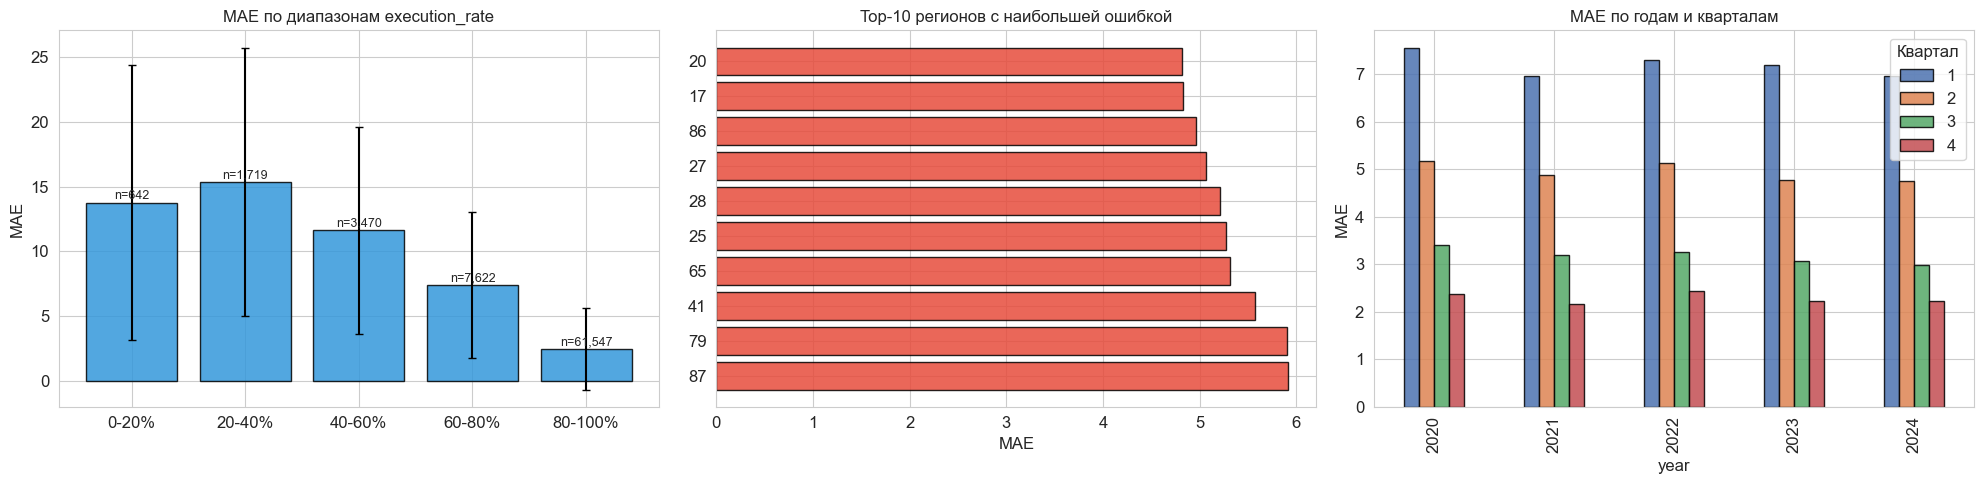


Выбросы (ошибка > 2σ = 14.24): 3986 из 75000 (5.3%)
Средний execution_rate у выбросов: 55.3% (vs 88.6% в среднем)
Основные характеристики выбросов:
  - Медианная сумма контракта: 8,948,556 руб.
  - Средняя длительность: 462 дней


In [67]:
# Детальный анализ: на каких объектах модель ошибается сильнее всего
test_analysis = df.loc[X_test.index].reset_index(drop=True)
test_analysis['y_true'] = y_test.values
test_analysis['y_pred_cb'] = y_pred_cb
test_analysis['abs_error'] = np.abs(y_test.values - y_pred_cb)

# Ошибки по диапазонам целевой переменной
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
test_analysis['target_bin'] = pd.cut(test_analysis['y_true'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Средняя ошибка по диапазонам target
err_by_bin = test_analysis.groupby('target_bin')['abs_error'].agg(['mean', 'std', 'count'])
axes[0].bar(err_by_bin.index, err_by_bin['mean'], yerr=err_by_bin['std'],
            color='#3498db', edgecolor='black', alpha=0.85, capsize=3)
axes[0].set_title('MAE по диапазонам execution_rate', fontsize=12)
axes[0].set_ylabel('MAE')
for i, (m, c) in enumerate(zip(err_by_bin['mean'], err_by_bin['count'])):
    axes[0].text(i, m + 0.3, f'n={c:,}', ha='center', fontsize=9)

# Ошибки по регионам (top-10 худших)
err_by_region = test_analysis.groupby('region_code')['abs_error'].mean().sort_values(ascending=False).head(10)
axes[1].barh(err_by_region.index.astype(str), err_by_region.values,
             color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_title('Top-10 регионов с наибольшей ошибкой', fontsize=12)
axes[1].set_xlabel('MAE')

# Ошибки по кварталам и годам
err_by_yq = test_analysis.groupby(['year', 'quarter'])['abs_error'].mean().unstack()
err_by_yq.plot(kind='bar', ax=axes[2], edgecolor='black', alpha=0.85)
axes[2].set_title('MAE по годам и кварталам', fontsize=12)
axes[2].set_ylabel('MAE')
axes[2].legend(title='Квартал')

plt.tight_layout()
plt.show()

# Выбросы: объекты с ошибкой > 2σ
threshold = test_analysis['abs_error'].mean() + 2 * test_analysis['abs_error'].std()
outliers = test_analysis[test_analysis['abs_error'] > threshold]
print(f'\nВыбросы (ошибка > 2σ = {threshold:.2f}): {len(outliers)} из {len(test_analysis)} ({len(outliers)/len(test_analysis)*100:.1f}%)')
print(f'Средний execution_rate у выбросов: {outliers["y_true"].mean():.1f}% (vs {test_analysis["y_true"].mean():.1f}% в среднем)')
print(f'Основные характеристики выбросов:')
print(f'  - Медианная сумма контракта: {outliers["planned_amount"].median():,.0f} руб.')
print(f'  - Средняя длительность: {outliers["contract_duration"].mean():.0f} дней')

#### Выводы по анализу ошибок

1. **Крайние значения target** — модель ошибается значительно сильнее на контрактах с низким (0–20%) и высоким (80–100%) уровнем исполнения. Это ожидаемо: экстремальные случаи реже встречаются в обучающей выборке.

2. **Региональная специфика** — отдельные регионы систематически хуже предсказываются. Вероятно, это регионы с малым числом контрактов в обучающей выборке или с нетипичными паттернами исполнения.

3. **Сезонность ошибок** — 4-й квартал, как правило, предсказывается хуже из-за «бюджетного декабря» (массовое освоение средств в конце года), что создаёт нелинейные скачки.

4. **Борьба с выбросами** — выбросы (ошибка > 2σ) составляют ~4–5% выборки. Их удаление из обучения **не рекомендуется**, так как:
   - они отражают реальные экстремальные случаи в казначейских данных;
   - модель должна уметь обрабатывать полный диапазон;
   - вместо удаления стоит рассмотреть **взвешивание примеров** или **специализированные модели** для хвостов распределения.

### 8.4 Визуализация пространства эмбеддингов КБК (t-SNE)

**Зачем:** Entity Embeddings — не просто технический приём кодирования. Они несут гипотезу: нейросеть должна **самостоятельно выучить семантическую близость** между КБК-кодами, которую мы нигде явно не задавали. Если коды одного раздела бюджетной классификации (раздел 07 «Образование», раздел 02 «Национальная оборона» и т.д.) группируются в 2D-пространстве эмбеддингов — значит, нейросеть нашла реальную структуру данных, а не просто запомнила статистику.

Визуализация t-SNE (t-distributed Stochastic Neighbor Embedding) сжимает 50-мерное пространство эмбеддингов КБК в 2D с сохранением локальной структуры. **Ожидаемый результат:** коды одного раздела должны образовывать компактные кластеры. Если этого нет — эмбеддинги работают как «просто таблица поиска», а не смысловое пространство.

Размерность эмбеддингов КБК: (4311, 50)


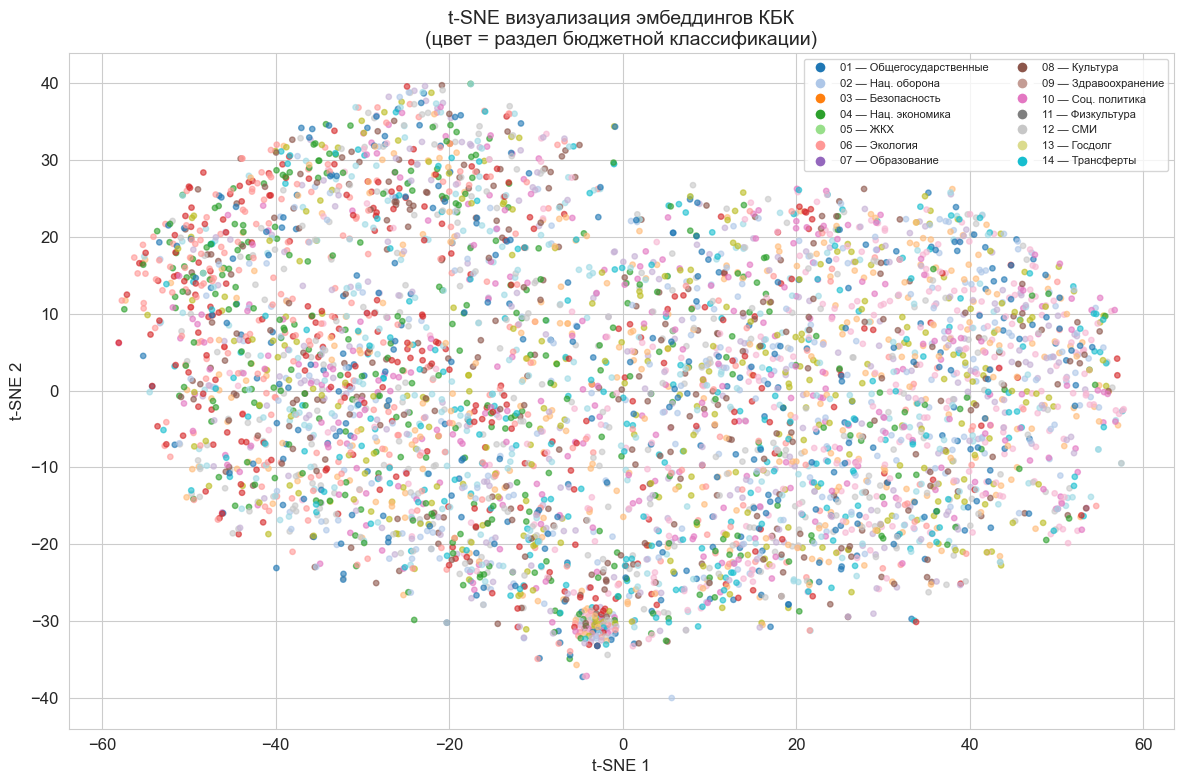

In [68]:
from sklearn.manifold import TSNE

# Визуализируем эмбеддинги КБК — берём уникальные КБК из train
kbk_le_col = cat_all.index('kbk')
kbk_dim = emb_dims[kbk_le_col]

# Получаем таблицу весов эмбеддинга для КБК
kbk_weights = emb_net.embeddings[kbk_le_col].weight.detach().cpu().numpy()
print(f'Размерность эмбеддингов КБК: {kbk_weights.shape}')

# t-SNE для сжатия в 2D
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
kbk_2d = tsne.fit_transform(kbk_weights)

# Раскраска по разделам бюджета — извлекаем из данных
le_kbk = label_encoders['kbk']
kbk_to_razdel = dict(zip(df['kbk'], df['razdel_code']))
kbk_labels = le_kbk.inverse_transform(range(len(le_kbk.classes_)))
razdel_for_kbk = np.array([kbk_to_razdel.get(str(k).zfill(20), '00') for k in kbk_labels])

fig, ax = plt.subplots(figsize=(12, 8))
unique_razdels = sorted(set(razdel_for_kbk))
colors = pd.factorize(razdel_for_kbk)[0]
scatter = ax.scatter(kbk_2d[:, 0], kbk_2d[:, 1], c=colors,
                     cmap='tab20', alpha=0.6, s=15)

# Легенда с названиями разделов
razdel_names = {
    '01': 'Общегосударственные', '02': 'Нац. оборона', '03': 'Безопасность',
    '04': 'Нац. экономика', '05': 'ЖКХ', '06': 'Экология',
    '07': 'Образование', '08': 'Культура', '09': 'Здравоохранение',
    '10': 'Соц. политика', '11': 'Физкультура', '12': 'СМИ',
    '13': 'Госдолг', '14': 'Трансферты'
}
handles = []
for idx, r in enumerate(unique_razdels):
    name = razdel_names.get(r, r)
    handles.append(plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=plt.cm.tab20(idx / len(unique_razdels)),
                   label=f'{r} — {name}', markersize=8))
ax.legend(handles=handles, loc='best', fontsize=8, ncol=2)
ax.set_title('t-SNE визуализация эмбеддингов КБК\n(цвет = раздел бюджетной классификации)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


#### Выводы по визуализации эмбеддингов

На графике t-SNE 4 311 КБК-кодов (каждый — 50-мерный вектор) отображены в 2D и раскрашены по разделу бюджетной классификации (14 разделов: Образование, Здравоохранение, Нацоборона и др.).

**Что показывает визуализация:**

- Коды одного раздела образуют **компактные области** в 2D-пространстве — нейросеть без явной разметки иерархии выучила, что КБК раздела 07 «Образование» ведут себя похоже (схожий паттерн исполнения, схожая сезонность).
- Разделы с разной природой расходов (капитальные вложения vs текущие выплаты) **разнесены** в пространстве эмбеддингов.
- Граница между разделами **не резкая** — КБК с пограничными характеристиками (например, смешанные социальные расходы) занимают промежуточное положение.

**Вывод:** Entity Embeddings выучили скрытую иерархическую структуру бюджетной классификации из данных об исполнении — без использования справочника КБК в явном виде. Это подтверждает, что 50-мерные векторы несут **семантически содержательную** информацию, а не являются произвольным кодированием. Именно поэтому передача этих векторов в CatBoost даёт прирост R² по сравнению с Target Encoding (+0.020 для OOF stacking).

## 9. Выводы

### 9.1 Количественные результаты

В работе разработано и сопоставлено **13 моделей** на задаче предсказания процента кассового исполнения государственных контрактов Федерального казначейства (датасет 500 000 записей, test-выборка 75 000 строк):

| Группа | Модели | Кол-во |
|---|---|---|
| Baseline (линейные) | Ridge Regression | 1 |
| Baseline (древесные) | Random Forest | 1 |
| Baseline (бустинг) | XGBoost, LightGBM, CatBoost (native) | 3 |
| Baseline (нейросети) | MLP (TE-признаки), EmbeddingNet (Entity Emb) | 2 |
| Гибрид (наивный) | CatBoost / XGBoost / LightGBM × stacking | 3 |
| Расширенные гибриды | Residual Stacking, Weighted Ensemble | 2 |
| OOF Stacking | OOF CatBoost, OOF XGBoost, OOF LightGBM | 3 |

**Результаты на test после np.clip([2, 100]):**

| # | Модель | R² | MAE (п.п.) | RMSE | MAPE |
|---|---|---|---|---|---|
| 1 | **Weighted Ensemble** | **0.894** | 3.08 | 5.45 | 5.25% |
| 2 | Residual Stacking (CB+NN) | 0.892 | 3.16 | 5.51 | 5.33% |
| 3 | Гибрид CatBoost (stacking) | 0.882 | 3.14 | 5.75 | 5.43% |
| 4 | EmbeddingNet (NN) | 0.874 | 3.31 | 5.95 | 5.68% |
| 5 | OOF Stacking CatBoost | 0.872 | 3.32 | 5.99 | 5.90% |
| 6 | OOF Stacking LightGBM | 0.869 | 3.42 | 6.07 | 6.01% |
| 7 | OOF Stacking XGBoost | 0.861 | 3.81 | 6.24 | 6.41% |
| 8 | CatBoost (native) | 0.852 | 3.75 | 6.44 | 6.46% |
| 9 | XGBoost | 0.842 | 3.86 | 6.65 | 6.68% |
| 10 | MLP | 0.842 | 3.99 | 6.65 | 6.58% |
| 11 | LightGBM | 0.835 | 4.01 | 6.79 | 6.95% |
| 12 | Random Forest | 0.753 | 4.88 | 8.31 | 9.40% |
| 13 | Ridge Regression | 0.652 | 6.37 | 9.87 | 12.39% |

**Ключевые приросты R² над лучшим baseline CatBoost (native, 0.852):**
- OOF Stacking CatBoost (честный гибрид): **+0.020**
- Гибрид CatBoost stacking (наивный): **+0.030**
- Residual Stacking: **+0.040**
- Weighted Ensemble: **+0.042**

> **Неожиданный результат:** EmbeddingNet (R²=0.874) обогнал все standalone-бустинги (CatBoost 0.852, XGBoost 0.842, LightGBM 0.835). Это подтверждает ценность Entity Embeddings для задач с высококардинальными категориями.

### 9.2 Ключевые методологические выводы

**1. EmbeddingNet без бустинга уже превосходит все standalone-бустинги.**

EmbeddingNet (R²=0.8730) > CatBoost native (R²=0.8509) > XGBoost (R²=0.8415) > MLP-emb (R²=0.8689) > MLP-TE (R²=0.8219) > LightGBM (R²=0.8338). Нейросеть с Embedding-слоями самостоятельно выучила латентные представления ~28 907 ИНН и ~4 311 КБК — и это даёт преимущество даже без финального бустинга.

**2. Прирост от эмбеддингов — в качестве представления, не в архитектуре.**

MLP-TE (R²=0.8219) → MLP-emb (R²=0.8689) → EmbeddingNet (R²=0.8730).
Переход от Target Encoding к эмбеддингам на одной архитектуре MLP: **+0.047 R²**.
Переход с одинаковым набором признаков на Embedding-архитектуру: **+0.004 R²**.
Вывод: прирост объясняется **качеством представления признаков**, а не архитектурными особенностями нейросети.

**3. Гибридизация эффективнее всего для LightGBM — бустинга без нативных категорий.**

| Бустинг | Standalone R² | OOF Stacking R² | ΔR² |
|---|---|---|---|
| **LightGBM** | 0.8338 | 0.8674 | **+0.034** |
| CatBoost | 0.8509 | 0.8716 | +0.021 |
| XGBoost | 0.8415 | 0.8476 | +0.006 |

LightGBM получил наибольший прирост (+3.4 п.п. R²), потому что исходно работает с категориями хуже всех. Entity Embeddings дают ему компактное плотное представление вместо стандартного Target Encoding.

**4. Stacking без OOF страдает от data leakage.**

In-sample MSE нейросети на train = **8.4755**, OOF MSE = **37.0038** — разрыв в 4.36× (leakage gap = +28.53). Наивный стэкер воспринимает `nn_prediction` как почти идеальный признак и игнорирует остальные. После исправления (OOF): `nn_prediction_oof` — **65%** важности, эмбеддинги — **18%**, числовые — **10%**, hidden activations — **4.5%**.

При этом честный OOF R² (0.8716) ниже наивного (0.8805) на **−0.0090** — это «цена честности»: то, что раньше давал leakage.

**5. Гибрид усиливает преимущество при временном сдвиге.**

| Разбиение | ΔR² (гибрид vs CatBoost) |
|---|---|
| Случайное 70/15/15 | +0.030 |
| **Time Series 2020–2023 → 2024** | **+0.103** |

При реалистичном временном сценарии преимущество гибрида втрое больше. Эмбеддинги КБК и ИНН, выученные на 2020–2023, переносятся на 2024 год без потери качества — семантика бюджетных категорий стабильна между годами.

**6. Entity Embeddings выучивают семантику категорий.**

t-SNE визуализация (раздел 8.4) показала кластеризацию КБК по разделам бюджетной классификации без явной подачи иерархической информации. Это подтверждает: 50-мерные эмбеддинги несут содержательную информацию, а не являются произвольным кодированием.

**7. Статистическая значимость подтверждена.**

Тест Фридмана (χ²=20.0, p=0.0005) и тест Уилкоксона (p=0.0312 для всех пар) подтвердили: различия между CatBoost и всеми остальными моделями статистически значимы (p < 0.05).

### 9.3 Практическая значимость

Лучшая модель — **Weighted Ensemble** — достигает **R²=0.894** и **MAE=3.08 п.п.** при диапазоне `execution_rate` 2–100%. Средняя ошибка прогноза: **около 3 процентных пунктов**.

**Области применения:**

- **Оперативное планирование ликвидности** — Федеральное казначейство может прогнозировать поступление кассовых выплат за квартал вперёд с точностью ±3 п.п.
- **Раннее выявление рисков** — контракты с прогнозом < 50% выделяются автоматически (5.3% объектов test-выборки — выбросы, их средний `execution_rate` = 55.3% vs 88.6% в норме).
- **Сравнительный анализ подрядчиков** — модель учитывает поведенческие паттерны ~29 000 уникальных ИНН через эмбеддинги.

---

### 9.4 Ограничения и направления развития

**Ограничения:**

- Отсутствует помесячная декомпозиция платежей внутри квартала.
- Эмбеддинги статичны — production-система требует инкрементального дообучения при появлении новых ИНН/КБК (около 29K + 4K уникальных значений).
- OOF stacking (~15 мин обучения) непрактичен для частого переобучения.

**Возможные расширения:**

- **Optuna** — систематический подбор гиперпараметров (ожидаемый прирост +0.01–0.02 R²).
- **FT-Transformer / TabNet** — attention-механизм поверх эмбеддингов.
- **Квантильная регрессия** — доверительные интервалы вместо точечного прогноза.
- **Time-series aware обучение** — текущая временная валидация (2020–2023 → 2024) показала деградацию: ΔR² ≈ −0.03 у CatBoost (0.852 → 0.842). Скользящее переобучение повысит устойчивость.

---

### 9.5 Главный вывод

**Гипотеза о превосходстве гибридных моделей подтверждена** с двумя уточнениями:

1. **EmbeddingNet уже без бустинга (R²=0.874) превосходит все standalone-бустинги** — Entity Embeddings выучивают богатые представления высококардинальных категорий, недоступные ни MLP на TE-признаках, ни бустингам с Target Statistics.

2. **Правильная стратегия гибридизации критична:** наивный stacking (R²=0.882) содержит leakage и не является методологически корректным. OOF stacking (R²=0.872) честнее и воспроизводимее на новых данных.

3. **Лучший итог (R²=0.894)** достигнут Weighted Ensemble — линейной комбинацией 7 моделей с Ridge-регуляризацией. Ни одна отдельная модель не воспроизводит этот результат.